# Sensitivity Analysis (Input Language) Justice Principles: Multilingual Descriptive Analysis


This notebook extends the Main Experiment descriptive workflow to Sensitivity Analysis (Input Language) experiment runs. We replicate the full descriptive analysis for the three language cohorts (English, Spanish, Mandarin), retaining the a colorblind-accessible visual system and comparing outputs across groups.


In [15]:
import sys
import json
from pathlib import Path
from typing import Any, Dict, List, Tuple
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

_NOTEBOOK_DIR = Path.cwd().resolve()
for candidate in [_NOTEBOOK_DIR, *_NOTEBOOK_DIR.parents]:
    if (candidate / "experiment_execution").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

# All imports from centralized package
from experiment_execution.utils_experiment_execution import (
    # Style
    COLORS,
    FIG_SIZES,
    FONT_SIZES,
    PRINCIPLE_COLORS,
    PRINCIPLE_DISPLAY_NAMES,
    apply_theme,
    format_principle_label,
    format_principle_labels,
    # Constants
    CERTAINTY_TO_SCORE,
    FINAL_WAVE,
    PRINCIPLE_LABELS,
    PRINCIPLE_ORDER,
    WAVE_DEFINITIONS,
    WAVE_ORDER,
    # Data loading
    load_experiment_runs,
    extract_run_metrics,
    extract_vote_rounds,
    extract_rankings,
    extract_income_classes,
    build_transition_data,
    create_transition_matrix,
    GroupDataset,
    build_group_dataset,
    create_preference_ordering_table,
    prepare_switcher_analysis,
    summarize_income_preferences,
    # Visualizations
    plot_floor_constraint_distribution,
    plot_floor_constraint_distribution_grouped,
    plot_income_composition,
    plot_income_preference_bars,
    plot_long_term_counts_grid,
    plot_long_term_margin,
    plot_long_term_stability,
    plot_long_term_stability_grid,
    plot_preference_stability,
    plot_rounds_to_outcome,
    plot_rounds_to_outcome_grouped,
    plot_transition_heatmaps,
    plot_voting_attempts_summary,
)

apply_theme()


In [16]:
LANGUAGE_GROUPS: "OrderedDict[str, str]" = OrderedDict([
    ("English", "english"),
    ("Spanish", "spanish"),
    ("Mandarin", "mandarin"),
])

# Use centralized constants (imported above)
# PRINCIPLE_LABELS, WAVE_ORDER, PRINCIPLE_ORDER are now available

PRINCIPLE_DISPLAY_ORDER = [PRINCIPLE_DISPLAY_NAMES[name] for name in PRINCIPLE_ORDER]


In [17]:
def locate_project_root(markers: Tuple[str, ...] = ("experiment_execution", "config")) -> Path:
    """Locate the project root by walking up the directory tree."""
    start = Path.cwd().resolve()
    for candidate in [start, *start.parents]:
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise FileNotFoundError("Could not locate project root from current working directory.")


PROJECT_ROOT = locate_project_root()
RESULTS_ROOT = PROJECT_ROOT / "experiment_execution" / "sensitivity_analysis_input_language" / "results"
TERMINAL_ROOT = PROJECT_ROOT / "experiment_execution" / "sensitivity_analysis_input_language" / "terminal_outputs"


def load_language_group_runs(language_slug: str) -> List[Tuple[str, Dict[str, Any]]]:
    """Load runs for a specific language group."""
    return load_experiment_runs(
        results_dir=RESULTS_ROOT / language_slug,
        pattern=f"sensitivity_analysis_input_language_{language_slug}_condition_*_config_results.json",
        terminal_outputs_dir=TERMINAL_ROOT / language_slug,
        log_pattern=f"sensitivity_analysis_input_language_{language_slug}_condition_*_log",
    )


In [18]:
# Load and preprocess each language cohort

group_datasets: "OrderedDict[str, GroupDataset]" = OrderedDict()

for label, slug in LANGUAGE_GROUPS.items():
    runs = load_language_group_runs(slug)
    dataset = build_group_dataset(label, slug, runs)
    transition_df = build_transition_data(dataset.ranking_top)
    dataset.transition_data = transition_df

    income_df = extract_income_classes(runs)
    dataset.income_df = income_df
    dataset.switcher_analysis = prepare_switcher_analysis(transition_df, income_df)

    group_datasets[label] = dataset
    print(f"Loaded {len(runs)} runs for {label}")


Loaded 34 runs for English
Loaded 34 runs for Spanish
Loaded 34 runs for Mandarin


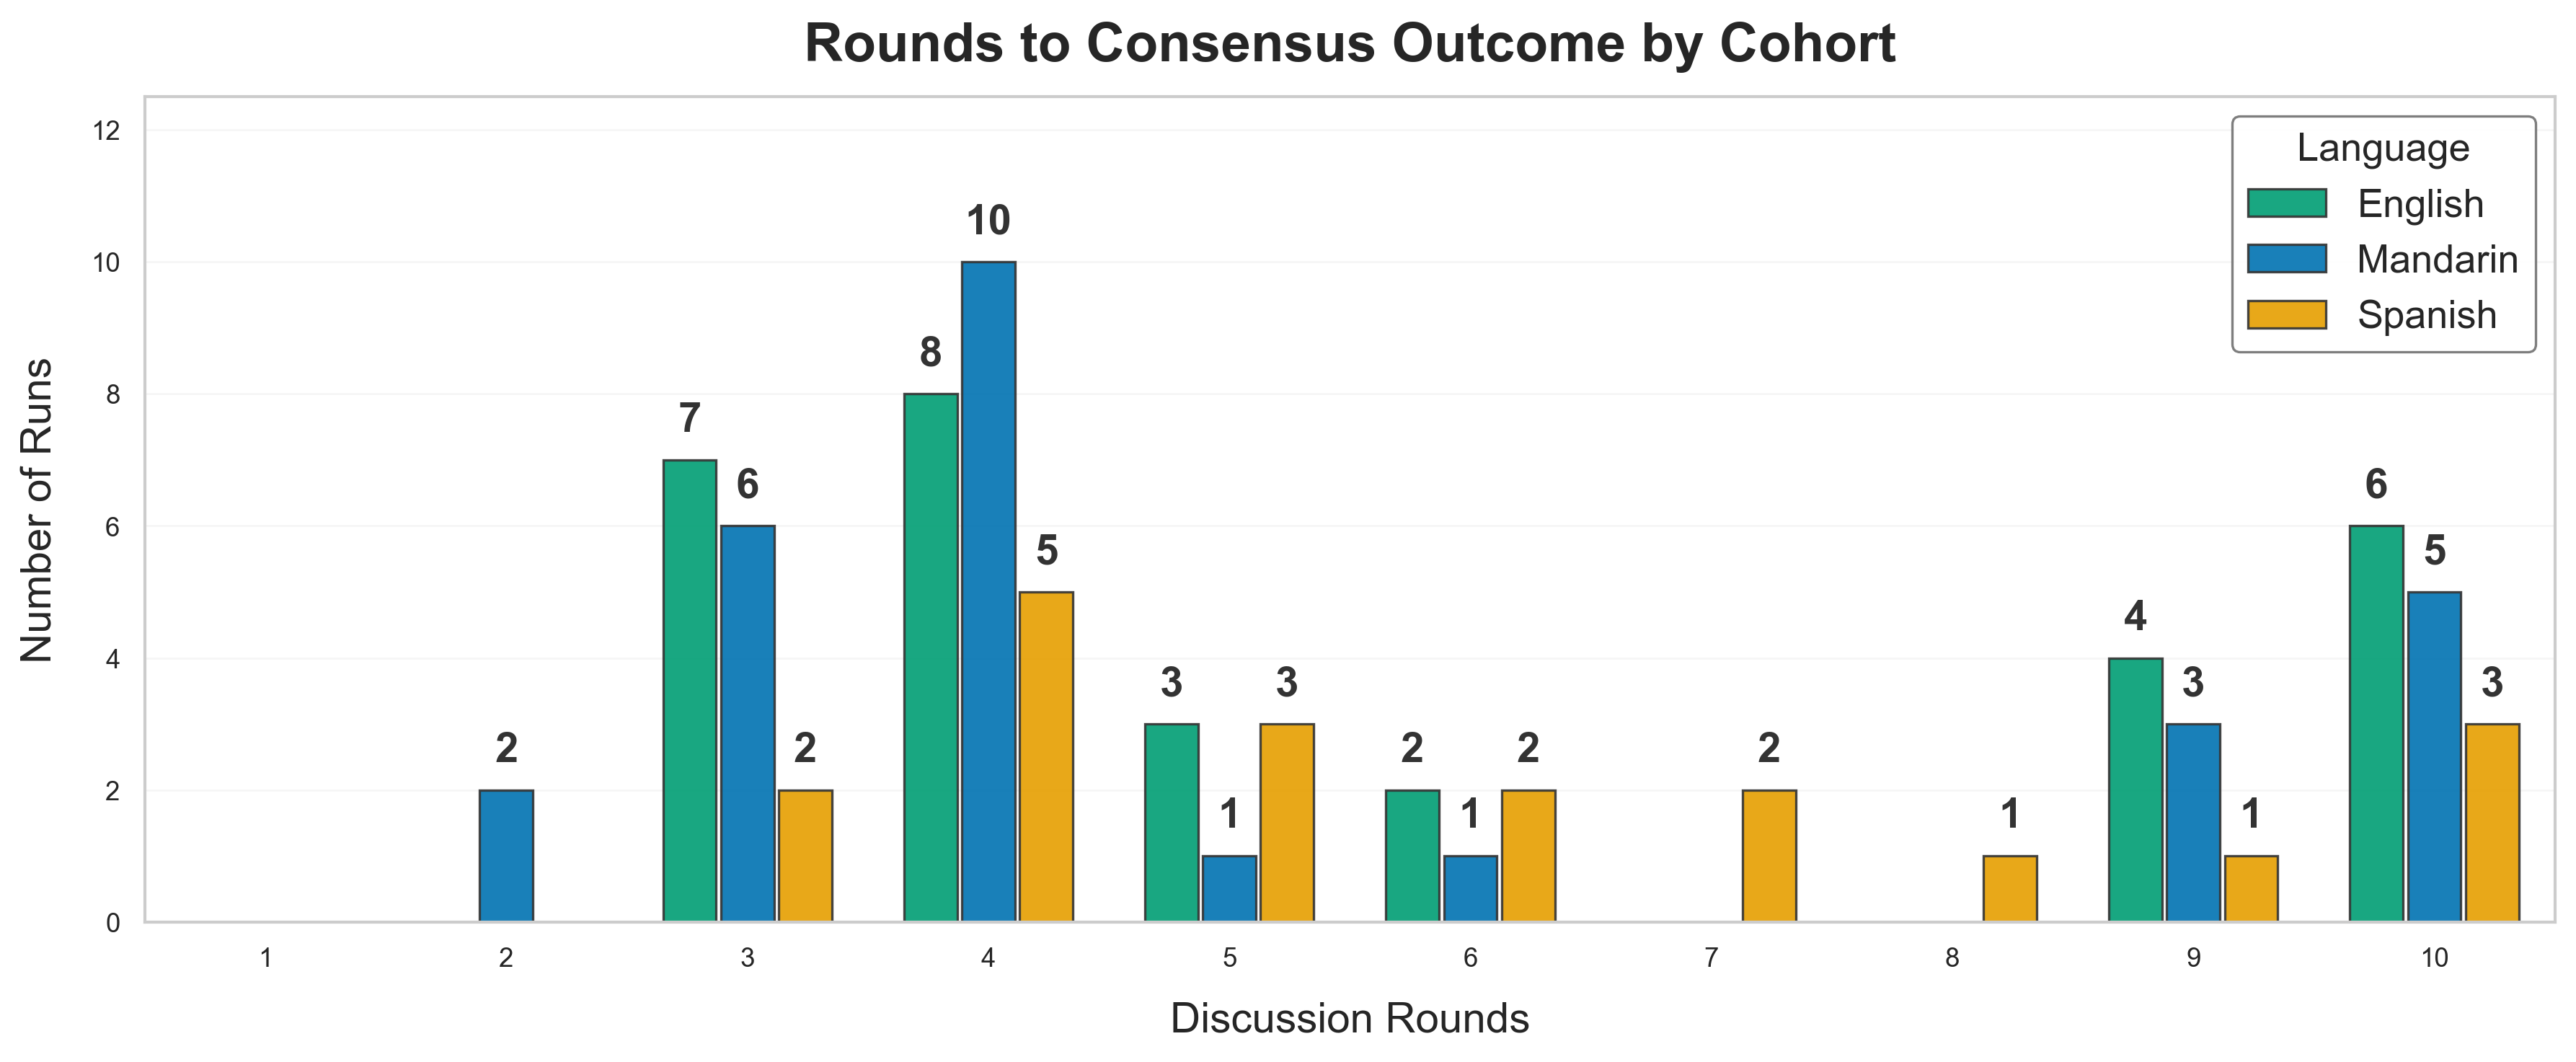

In [19]:
ordered_languages = ["English", "Mandarin", "Spanish"]
grouped_rounds_data = [
    (label, group_datasets[label].run_metrics if label in group_datasets else None)
    for label in ordered_languages
]

plot_rounds_to_outcome_grouped(
    grouped_rounds_data,
    language_order=ordered_languages,
    font_scale=1.3,
    annotation_fontsize=14,
)


In [20]:

# Cohort-level overview table

overview_records: List[Dict[str, Any]] = []

for label, dataset in group_datasets.items():
    run_metrics = dataset.run_metrics
    consensus_runs = run_metrics[run_metrics["consensus_reached"] == True]
    rounds = consensus_runs["rounds_to_outcome"].dropna()
    overview_records.append({
        "Cohort": label,
        "Runs": run_metrics.shape[0],
        "Consensus Runs": consensus_runs.shape[0],
        "Consensus Rate": consensus_runs.shape[0] / run_metrics.shape[0] if run_metrics.shape[0] else np.nan,
        "Mean Rounds": rounds.mean() if not rounds.empty else np.nan,
        "Median Rounds": rounds.median() if not rounds.empty else np.nan,
    })

overview_df = pd.DataFrame(overview_records)
overview_df["Consensus Rate"] = (overview_df["Consensus Rate"] * 100).round(1)
overview_df["Mean Rounds"] = overview_df["Mean Rounds"].round(2)
overview_df["Median Rounds"] = overview_df["Median Rounds"].round(1)

display(Markdown("### High-Level Cohort Overview"))
display(overview_df)


### High-Level Cohort Overview

,Cohort,Runs,Consensus Runs,Consensus Rate,Mean Rounds,Median Rounds
0,English,34,30,88.2,5.87,4.5
1,Spanish,34,19,55.9,6.00,5.0
2,Mandarin,34,28,82.4,5.36,4.0


## English Cohort

### Data Summary

,Metric,Value
0,Runs,34
1,Consensus runs,30
2,Agent sessions,170
3,Preference waves,4


Transition coverage: 170/170 agents with full wave data


### Preference Orderings by Wave

...

**Wave 3 - Final Phase 1**

,Preference Ordering,Count,Percentage
0,Max Avg + Floor > Max Floor > Max Avg + Range ...,83,48.8
1,Max Avg + Floor > Max Avg + Range > Max Floor ...,41,24.1
2,Max Avg + Floor > Max Floor > Max Avg Income >...,12,7.1
3,Max Avg + Floor > Max Avg Income > Max Floor >...,10,5.9
4,Max Avg + Floor > Max Avg + Range > Max Avg In...,5,2.9
5,Max Avg + Floor > Max Avg Income > Max Avg + R...,5,2.9
6,Max Avg + Range > Max Avg + Floor > Max Floor ...,3,1.8
7,Max Avg Income > Max Avg + Floor > Max Avg + R...,3,1.8
8,Max Avg Income > Max Avg + Floor > Max Floor >...,3,1.8
9,Max Floor > Max Avg + Floor > Max Avg + Range ...,3,1.8


**Wave 4 - Post-Group**

,Preference Ordering,Count,Percentage
0,Max Avg + Floor > Max Floor > Max Avg + Range ...,69,40.6
1,Max Avg + Floor > Max Avg + Range > Max Floor ...,43,25.3
2,Max Avg + Floor > Max Avg Income > Max Avg + R...,14,8.2
3,Max Avg + Floor > Max Floor > Max Avg Income >...,14,8.2
4,Max Avg + Floor > Max Avg Income > Max Floor >...,12,7.1
5,Max Floor > Max Avg + Floor > Max Avg + Range ...,8,4.7
6,Max Avg + Floor > Max Avg + Range > Max Avg In...,3,1.8
7,Max Avg + Range > Max Floor > Max Avg + Floor ...,2,1.2
8,Max Avg Income > Max Avg + Floor > Max Avg + R...,2,1.2
9,Max Avg + Range > Max Floor > Max Avg Income >...,1,0.6


### Rounds to Outcome

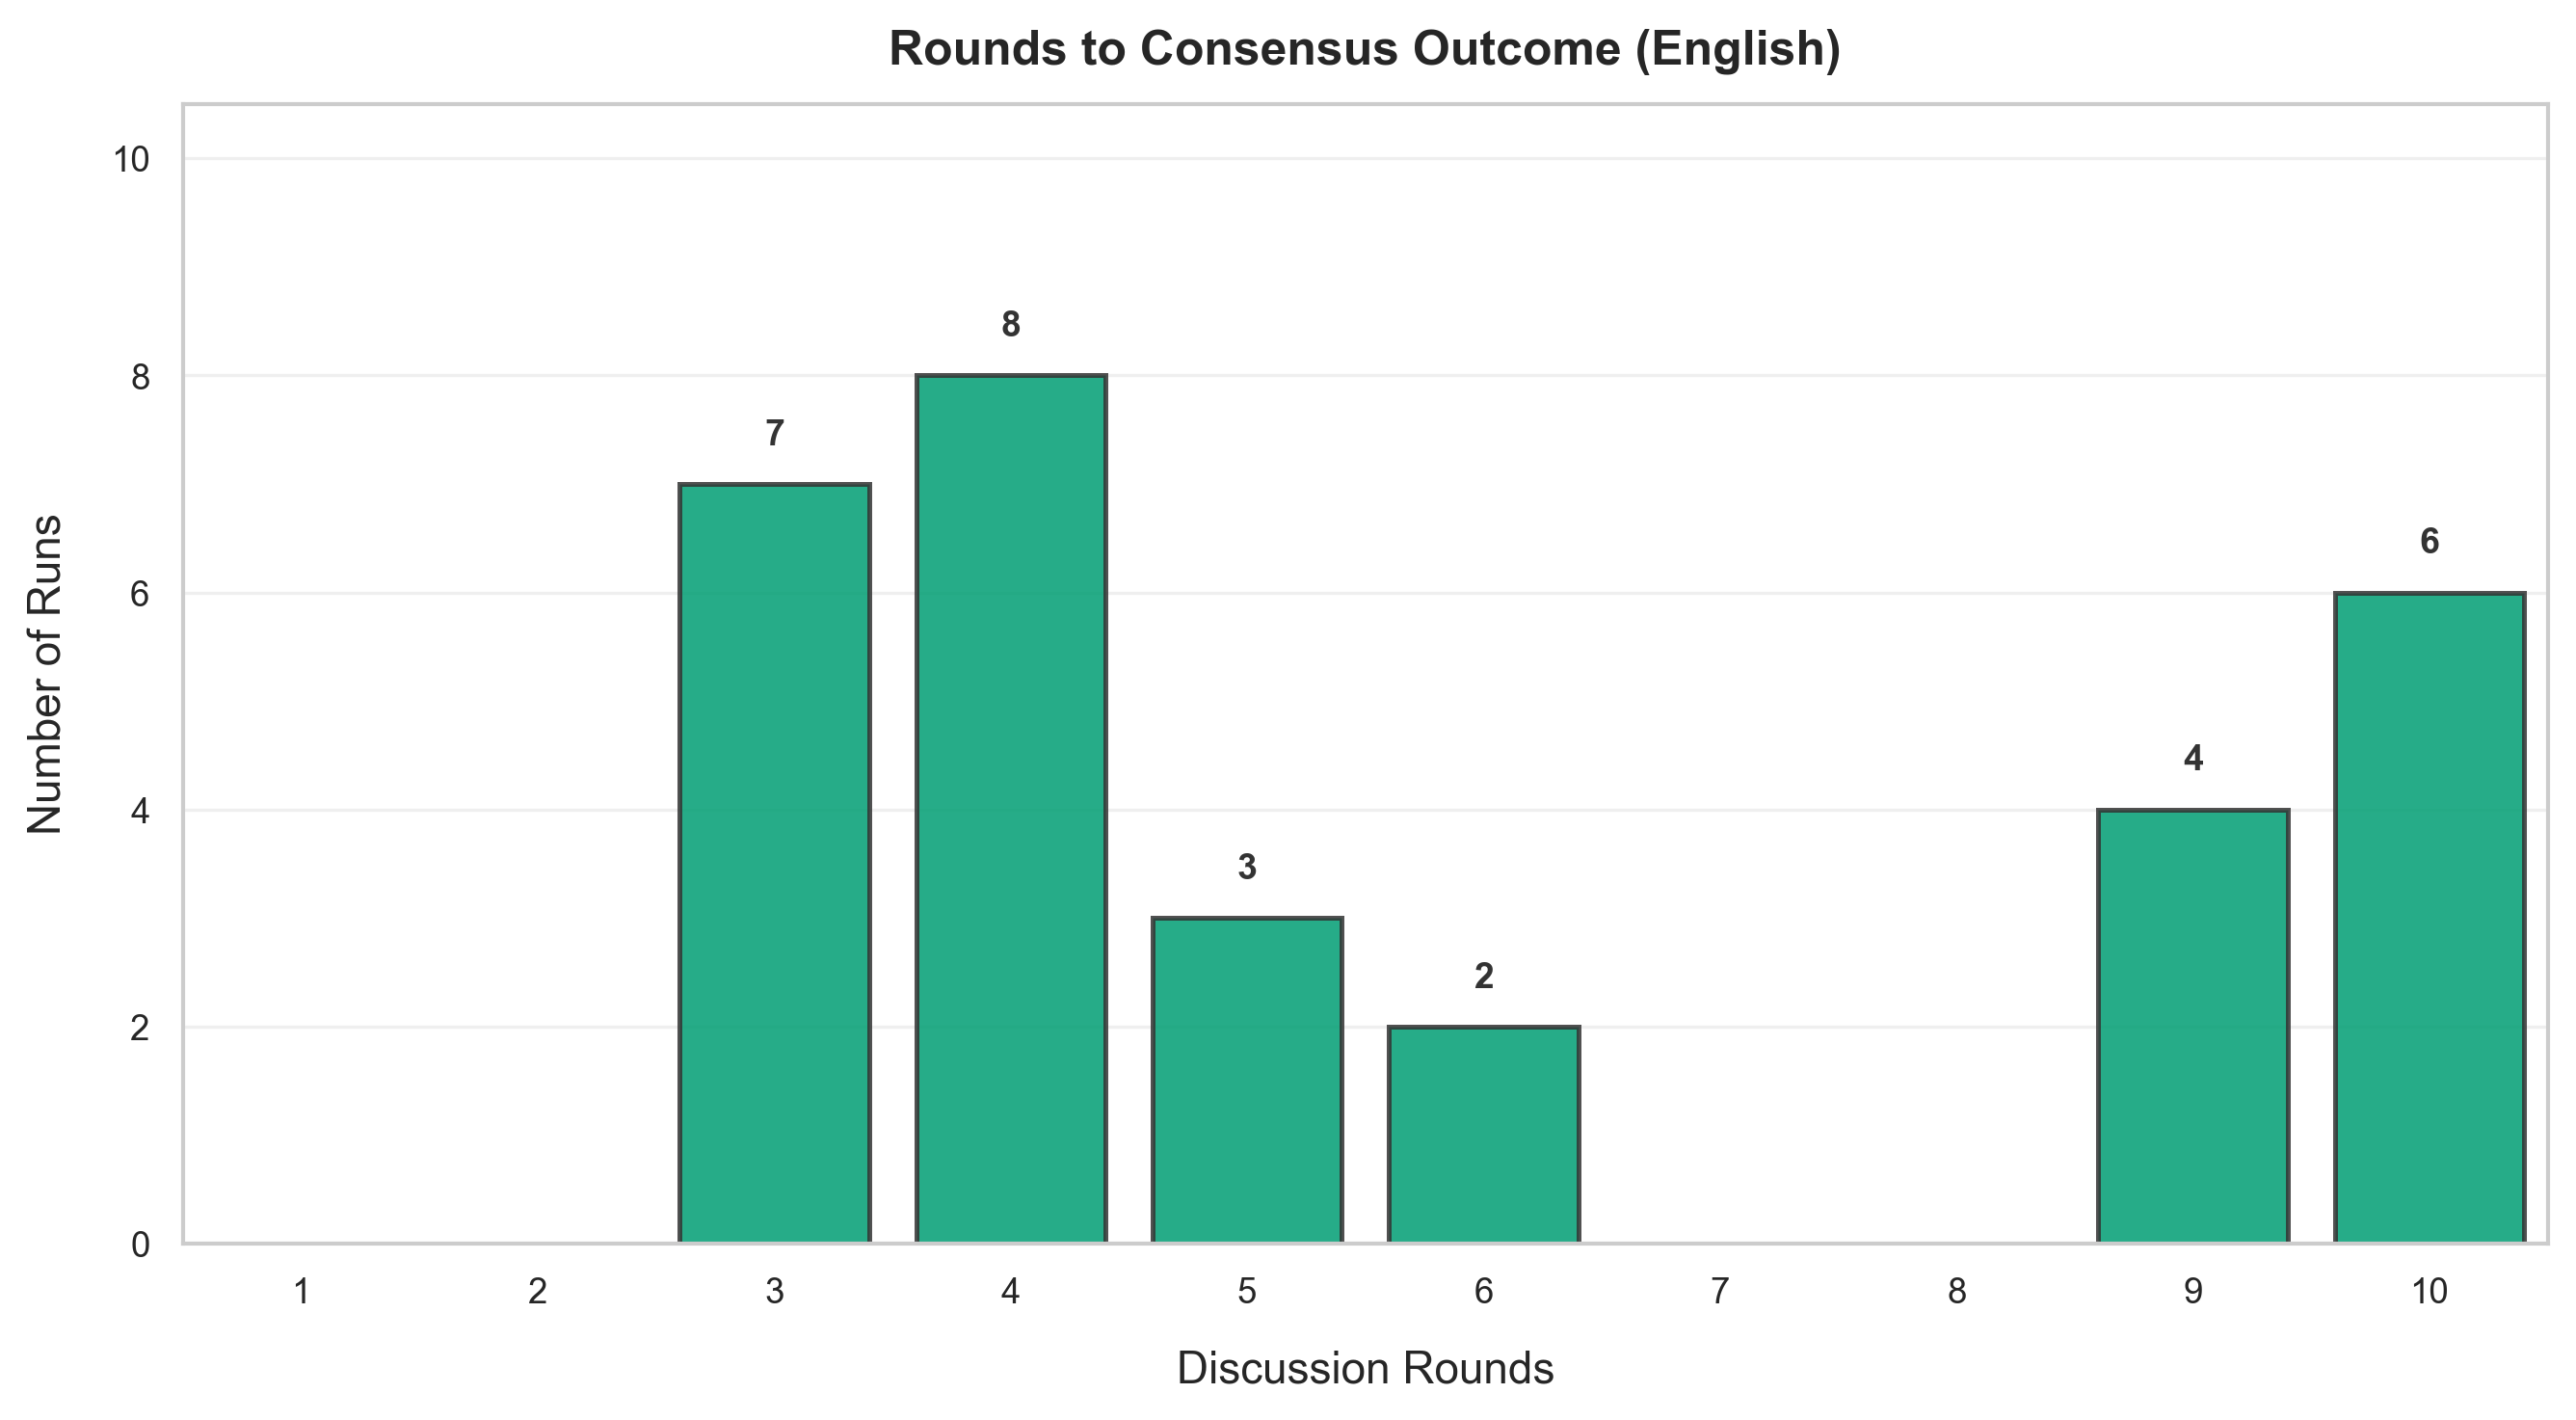

Consensus Timing Summary:
  Total consensus runs: 30
  Range: 3-10 rounds
  Mean: 5.87 rounds  |  Median: 4 rounds


### Floor Constraint Amounts

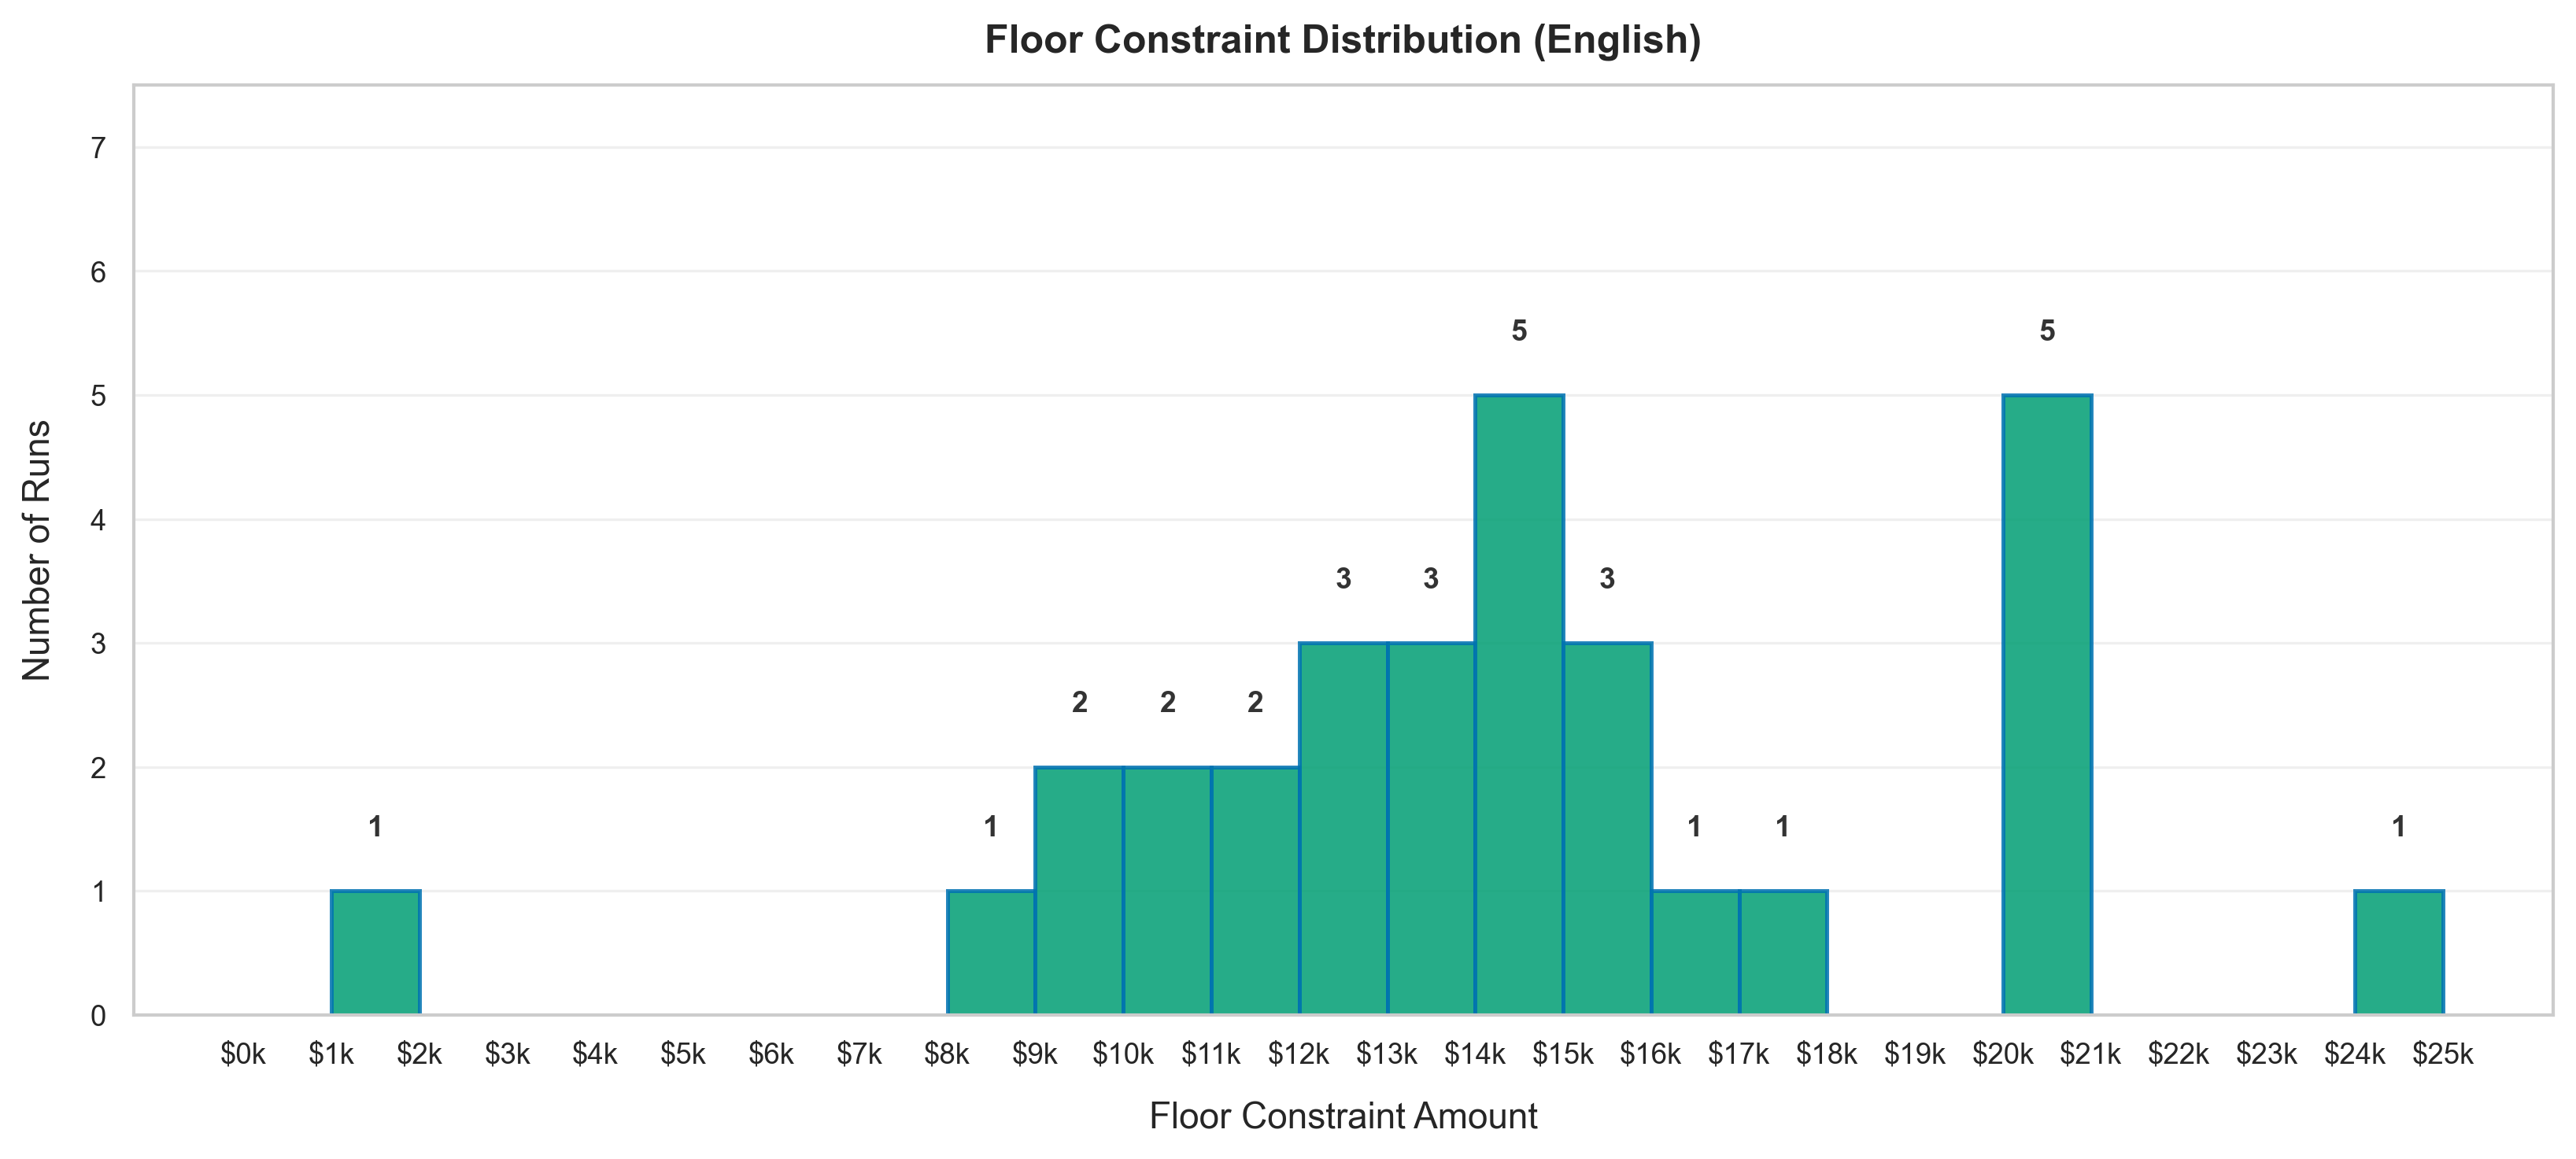

Floor Amount Summary:
  Total votes: 30
  Range: $1,000 - $25,000
  Mean: $14,017  |  Median: $14,000  |  SD: $4,574


### Voting Attempts and Success Rate

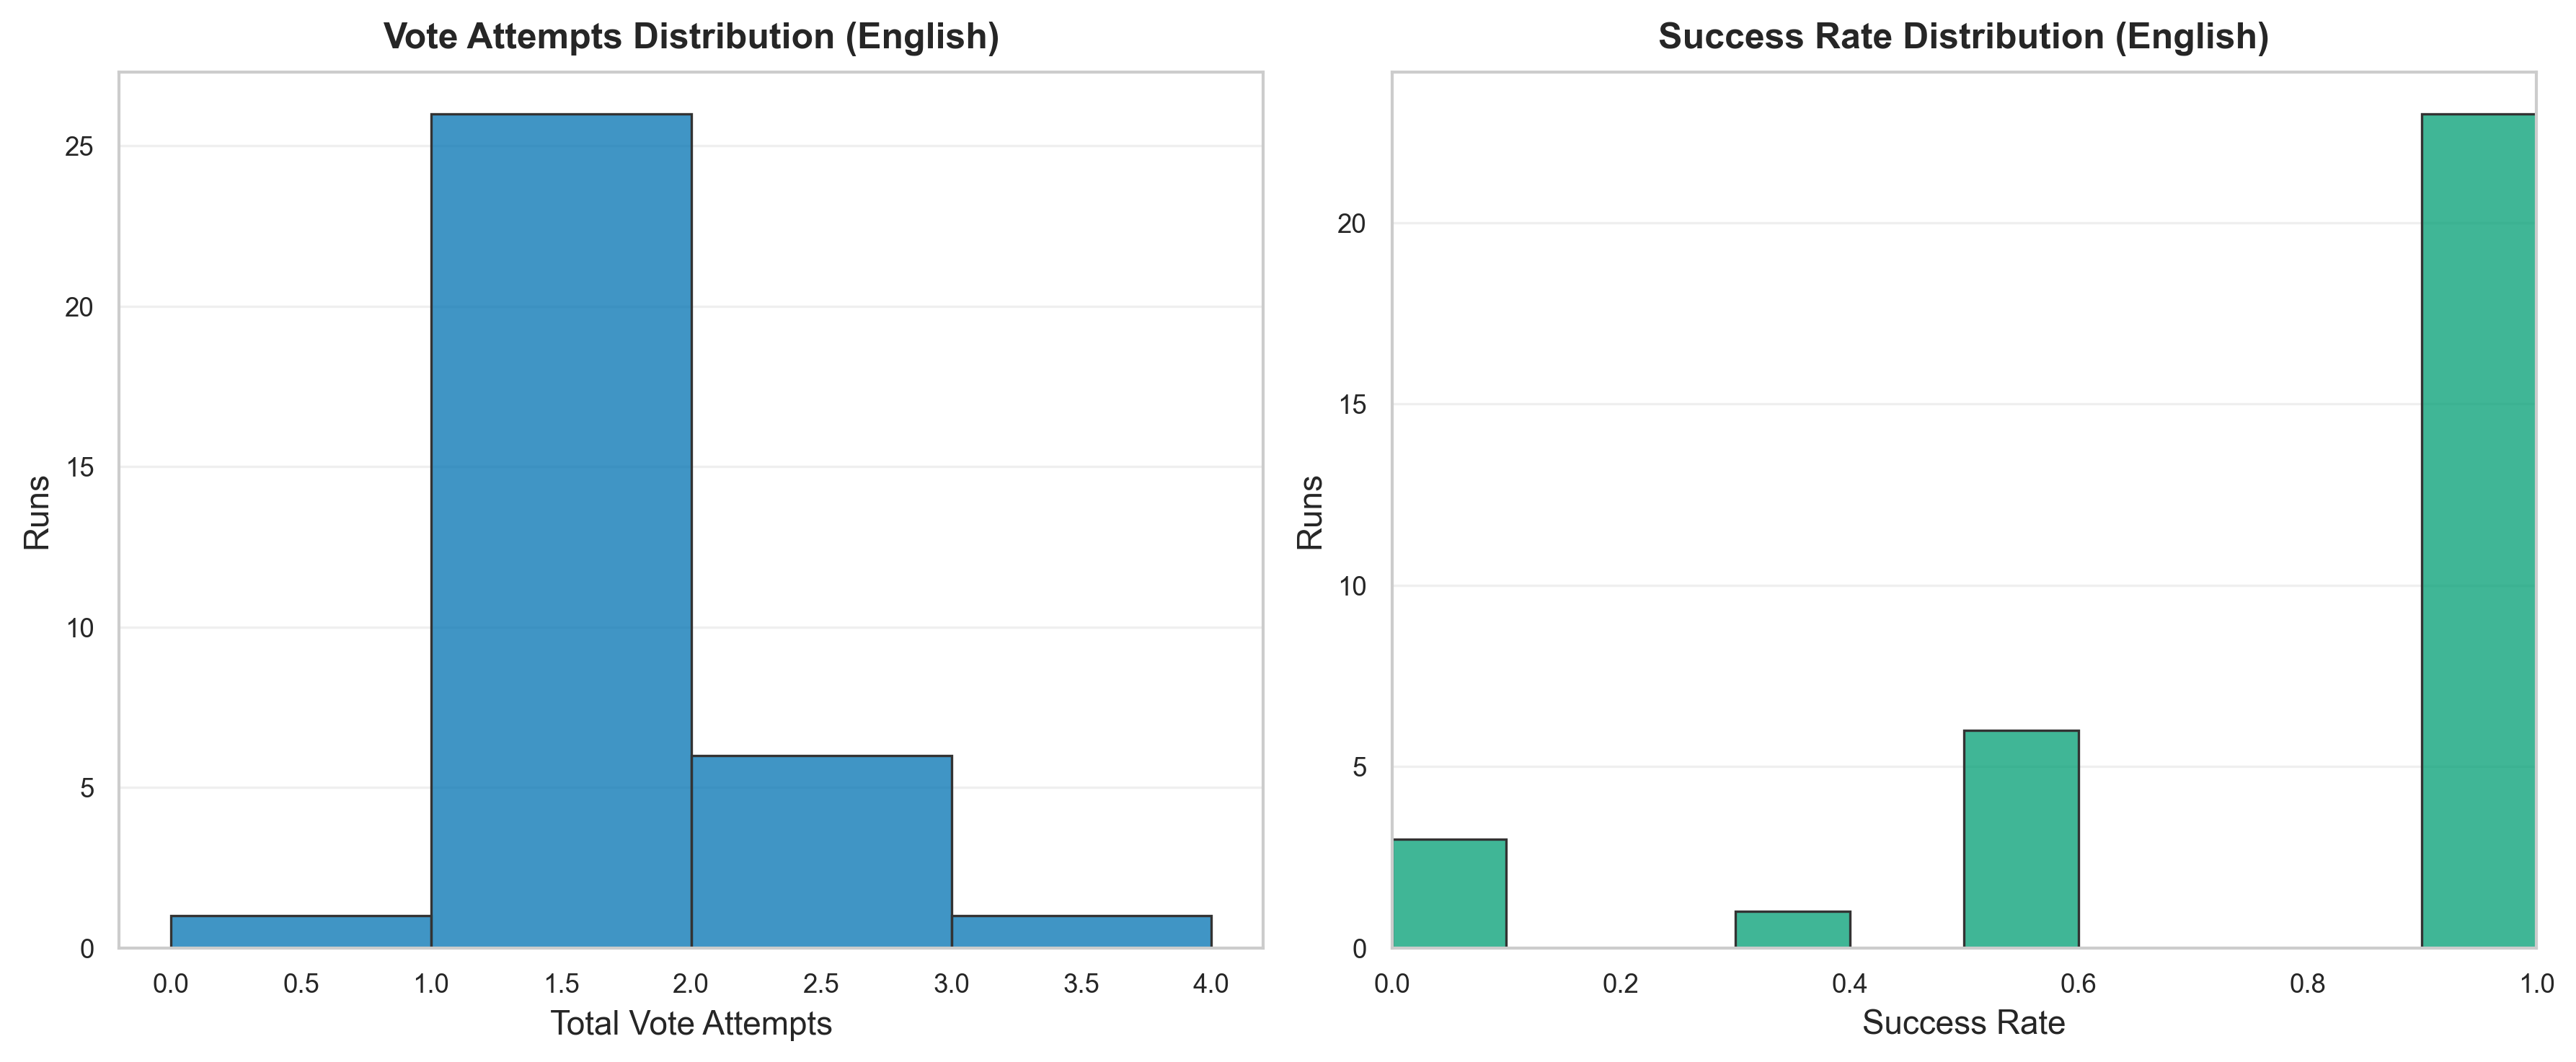

Voting Attempts Summary:
  Mean attempts per run: 1.21
  Median attempts per run: 1
  Mean success rate: 79.80%
  Median success rate: 100.00%


### Preference Evolution and Transitions

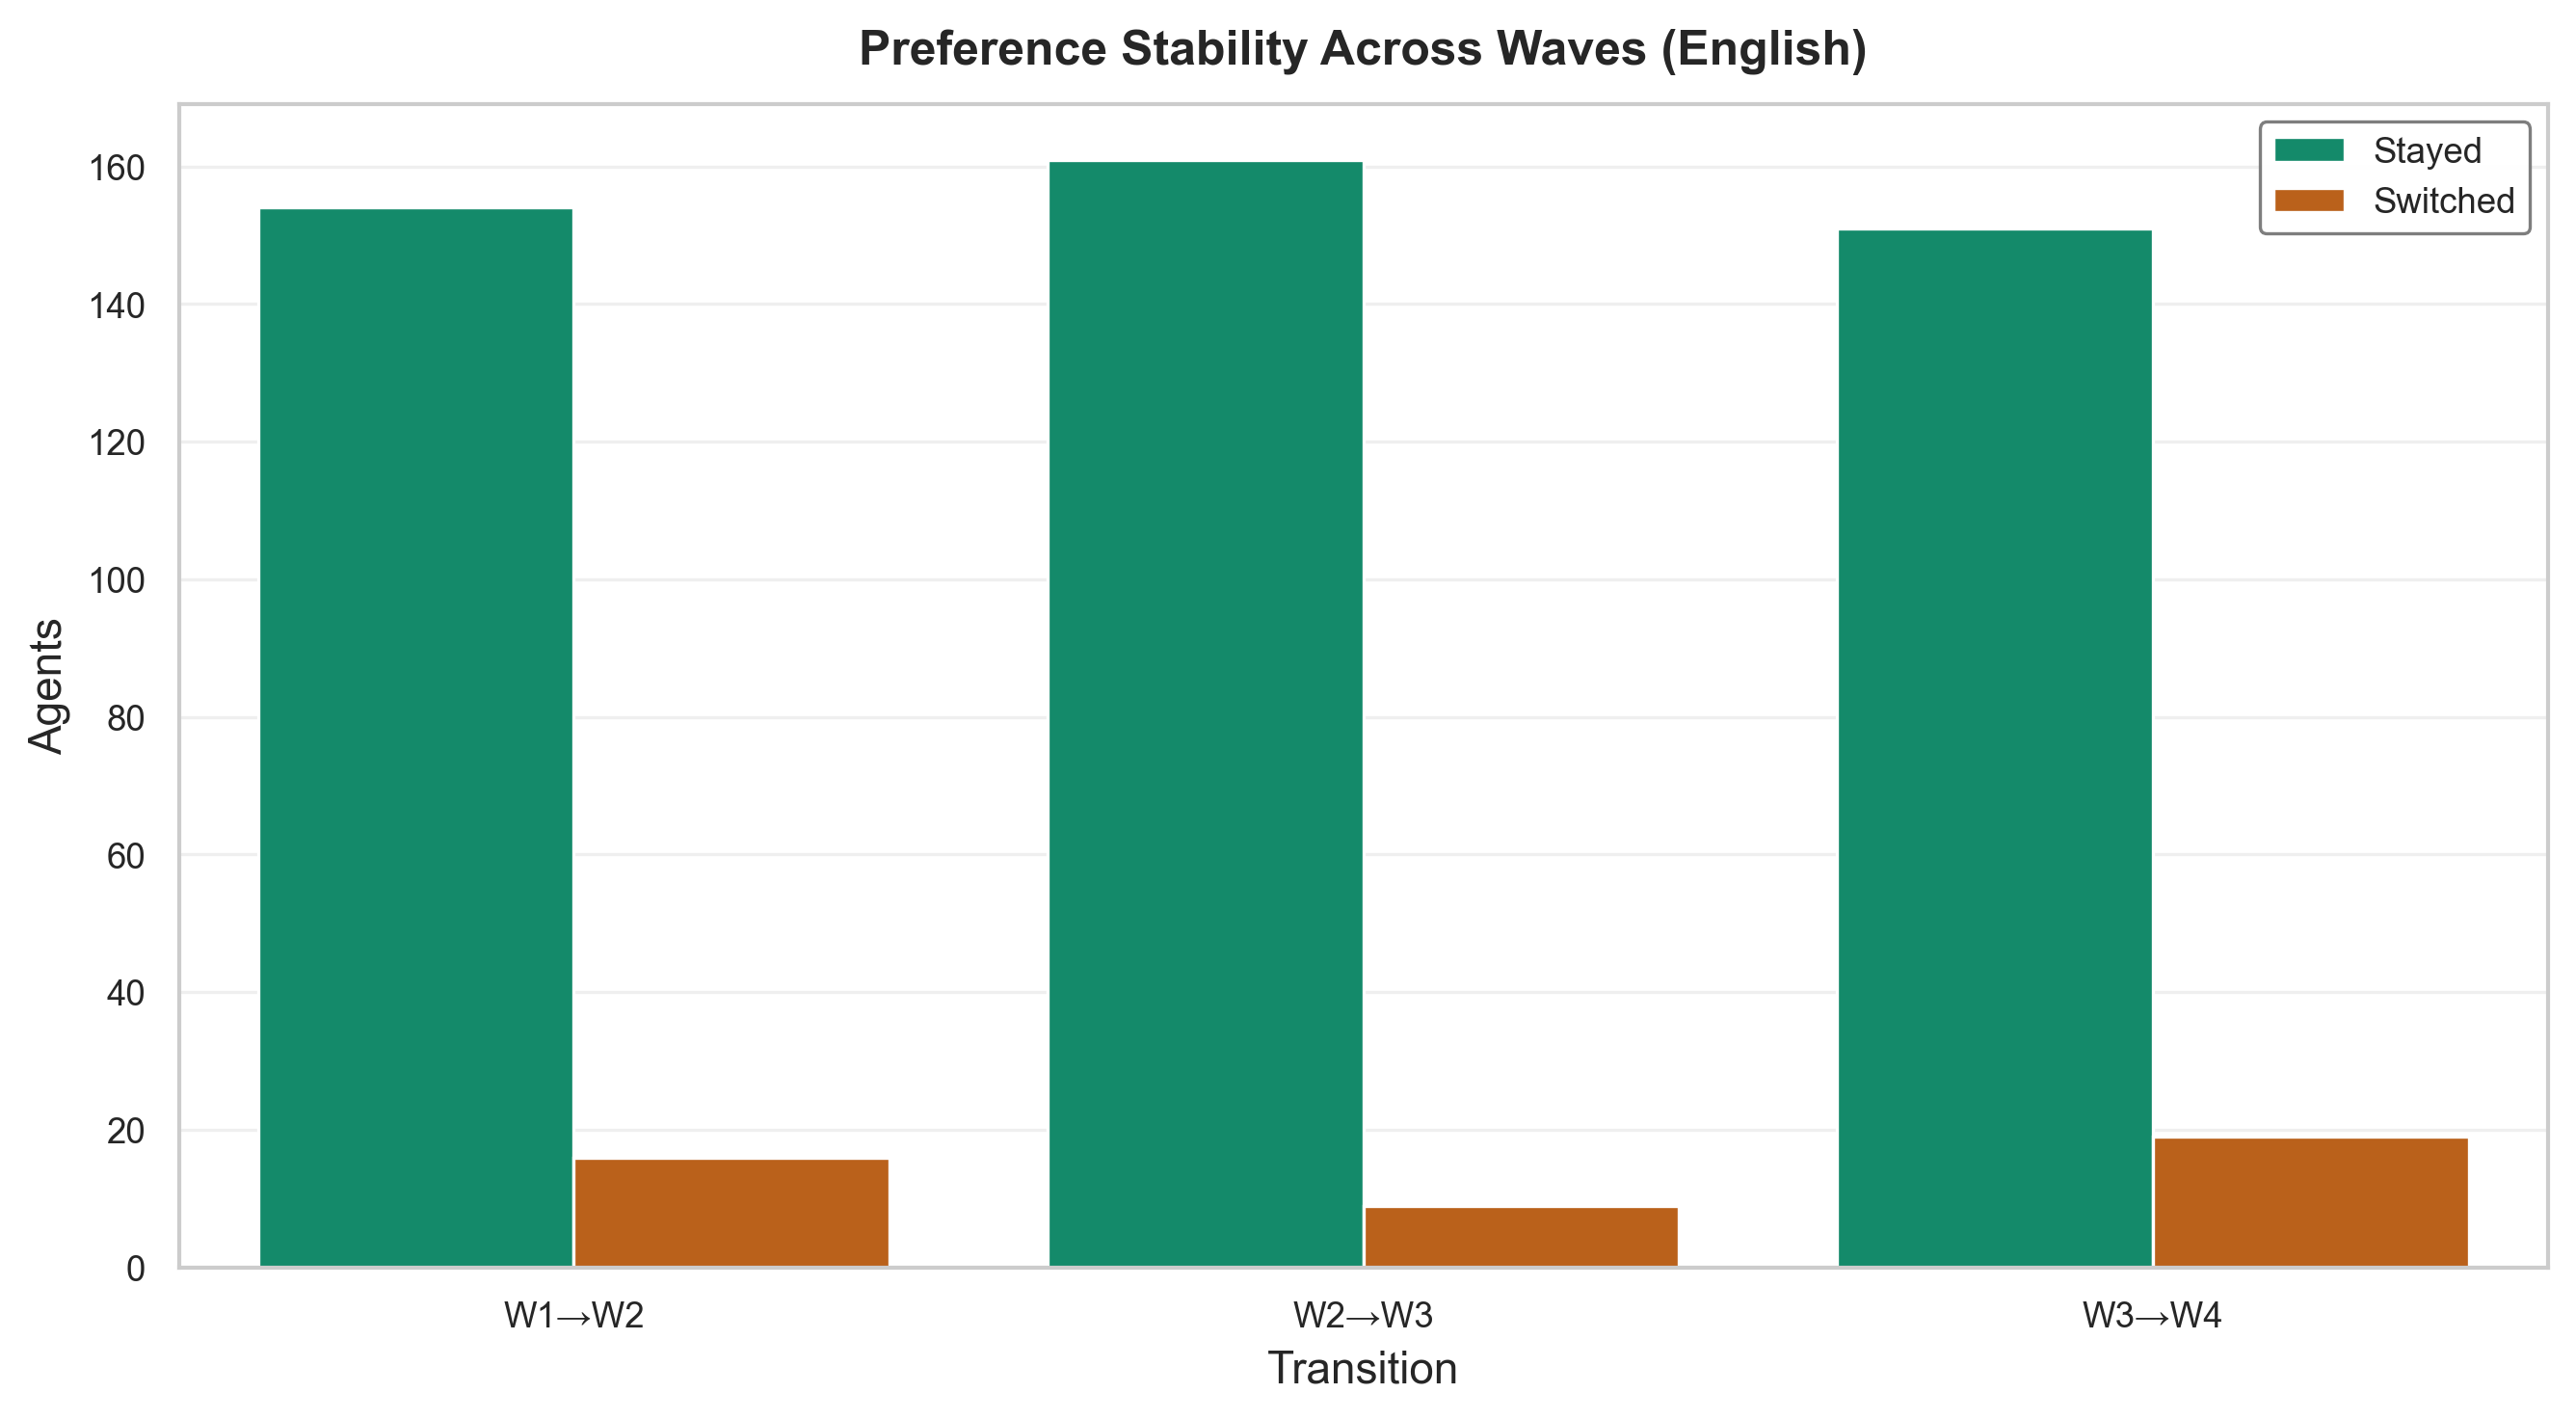

Stability Breakdown:
  W1→W2: 154/170 stayed (90.6%)
  W2→W3: 161/170 stayed (94.7%)
  W3→W4: 151/170 stayed (88.8%)


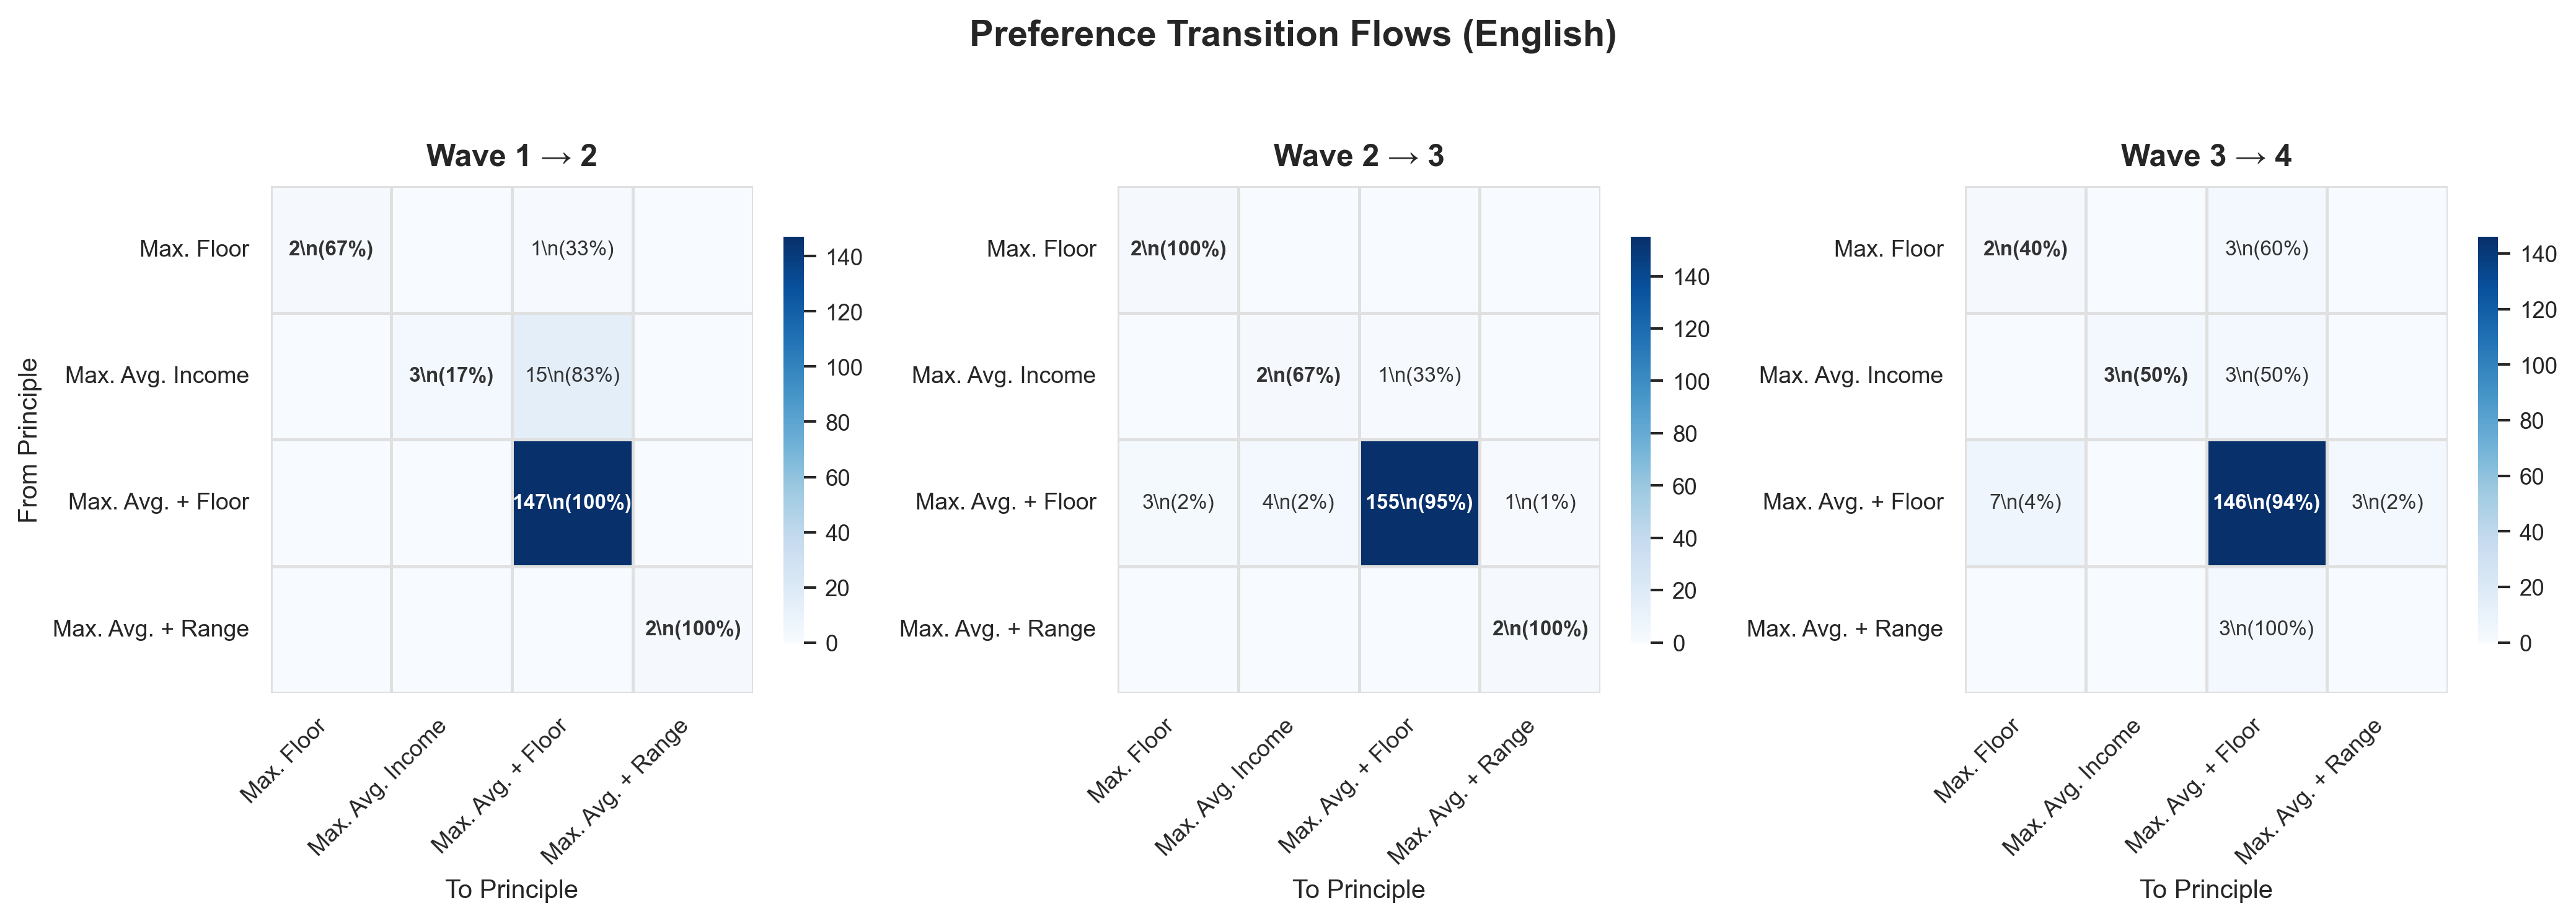

Transition Stay Rates:
  Wave 1 → 2: 154/170 stayed (90.6%)
  Wave 2 → 3: 161/170 stayed (94.7%)
  Wave 3 → 4: 151/170 stayed (88.8%)


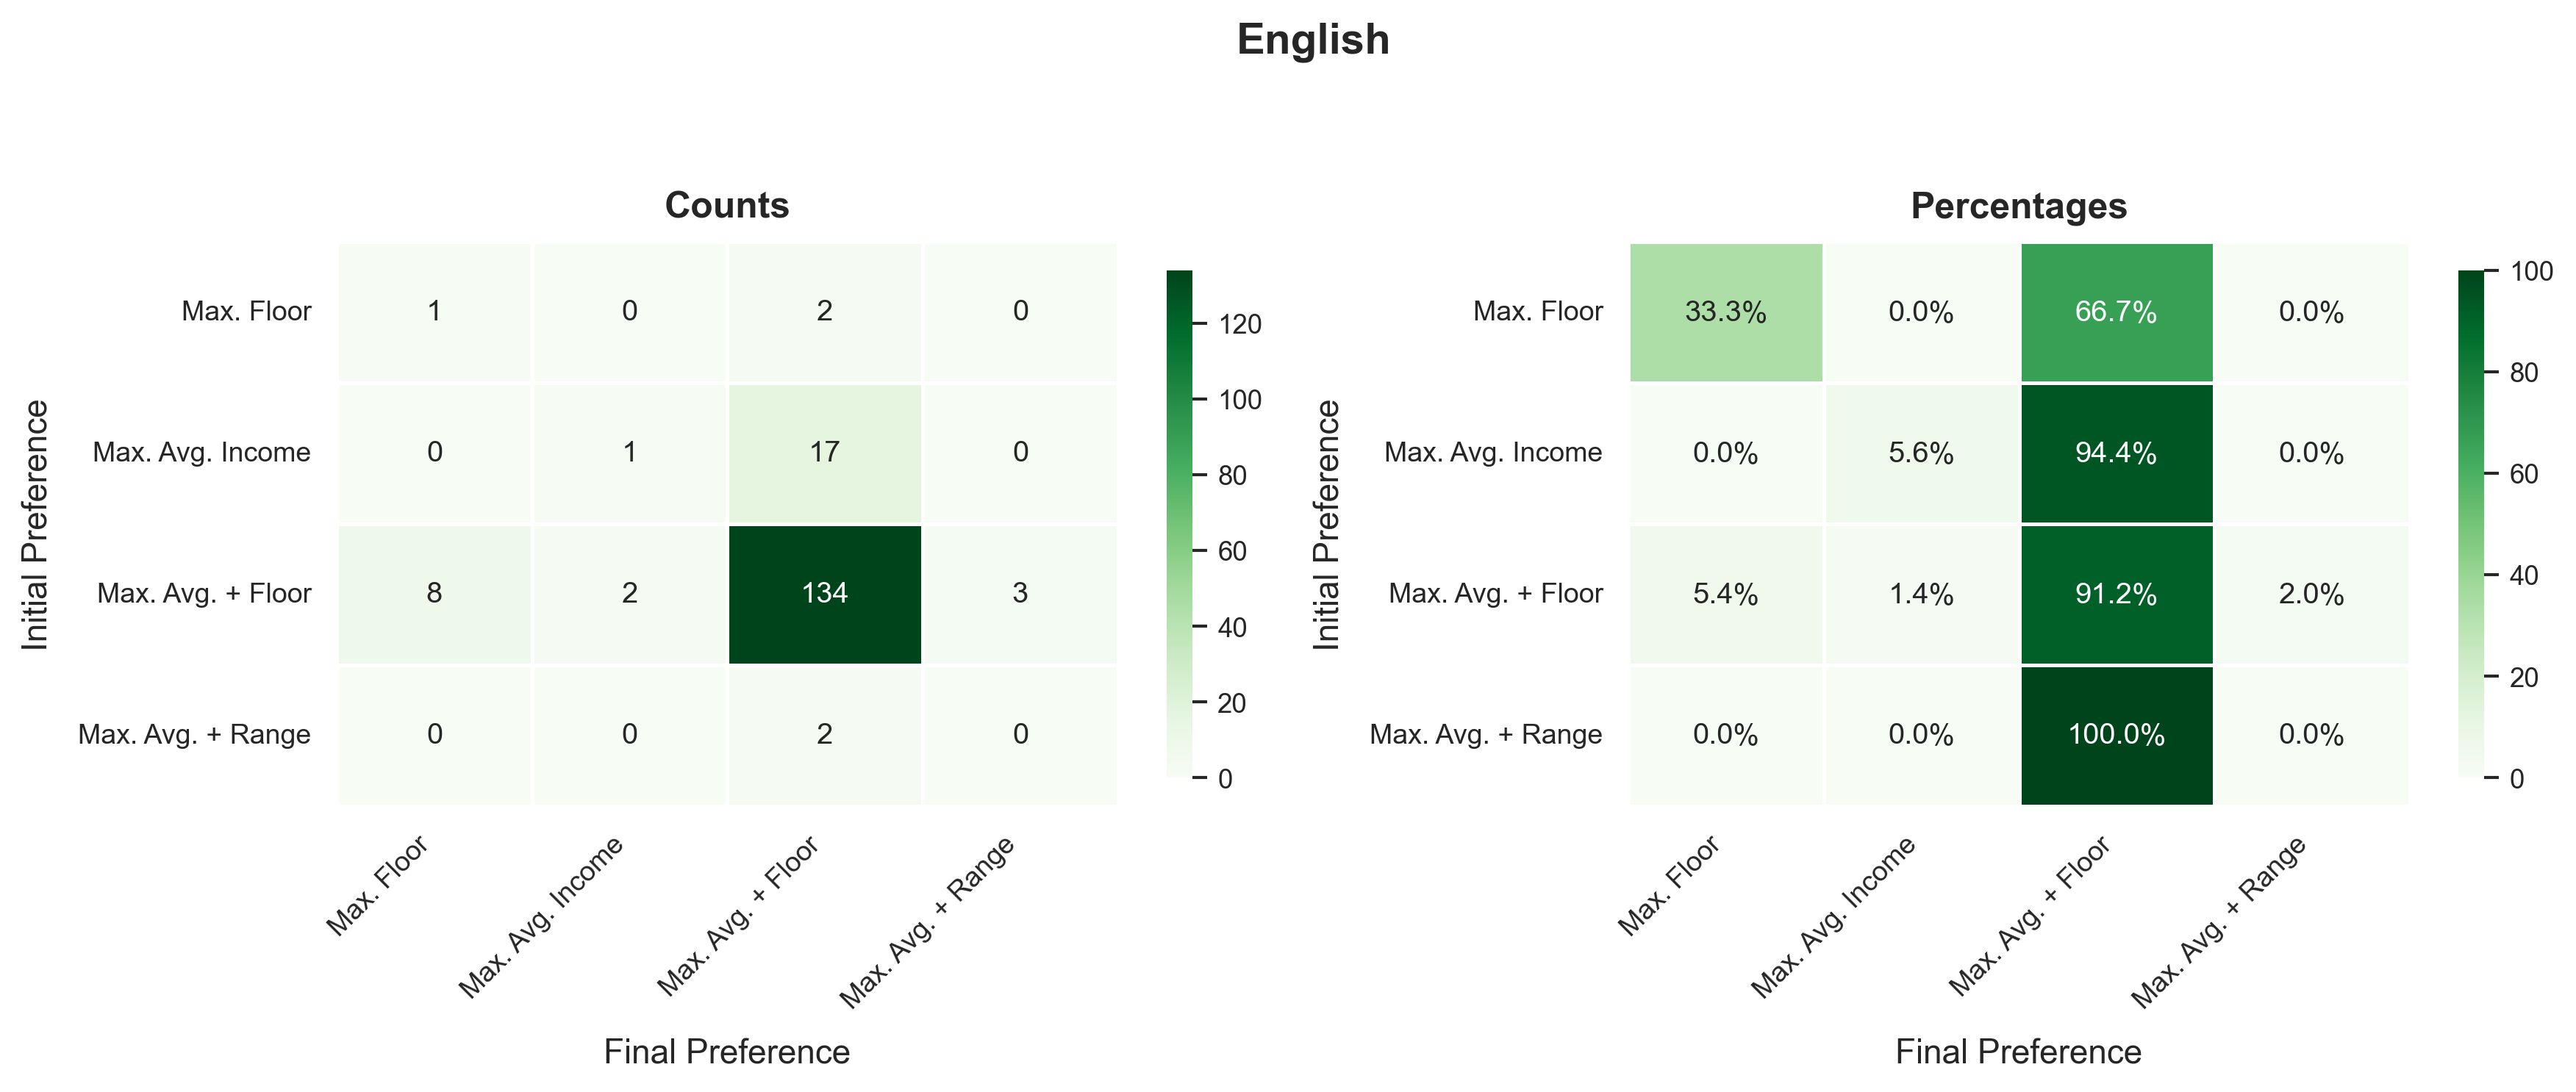

Long-Term Stability (Wave 1 → Wave 4) [English]
Max. Floor               :   1/  3 maintained ( 33.3%)
Max. Avg. Income         :   1/ 18 maintained (  5.6%)
Max. Avg. + Floor        : 134/147 maintained ( 91.2%)
Max. Avg. + Range        :   0/  2 maintained (  0.0%)
OVERALL                  : 136/170 agents ( 80.0%)


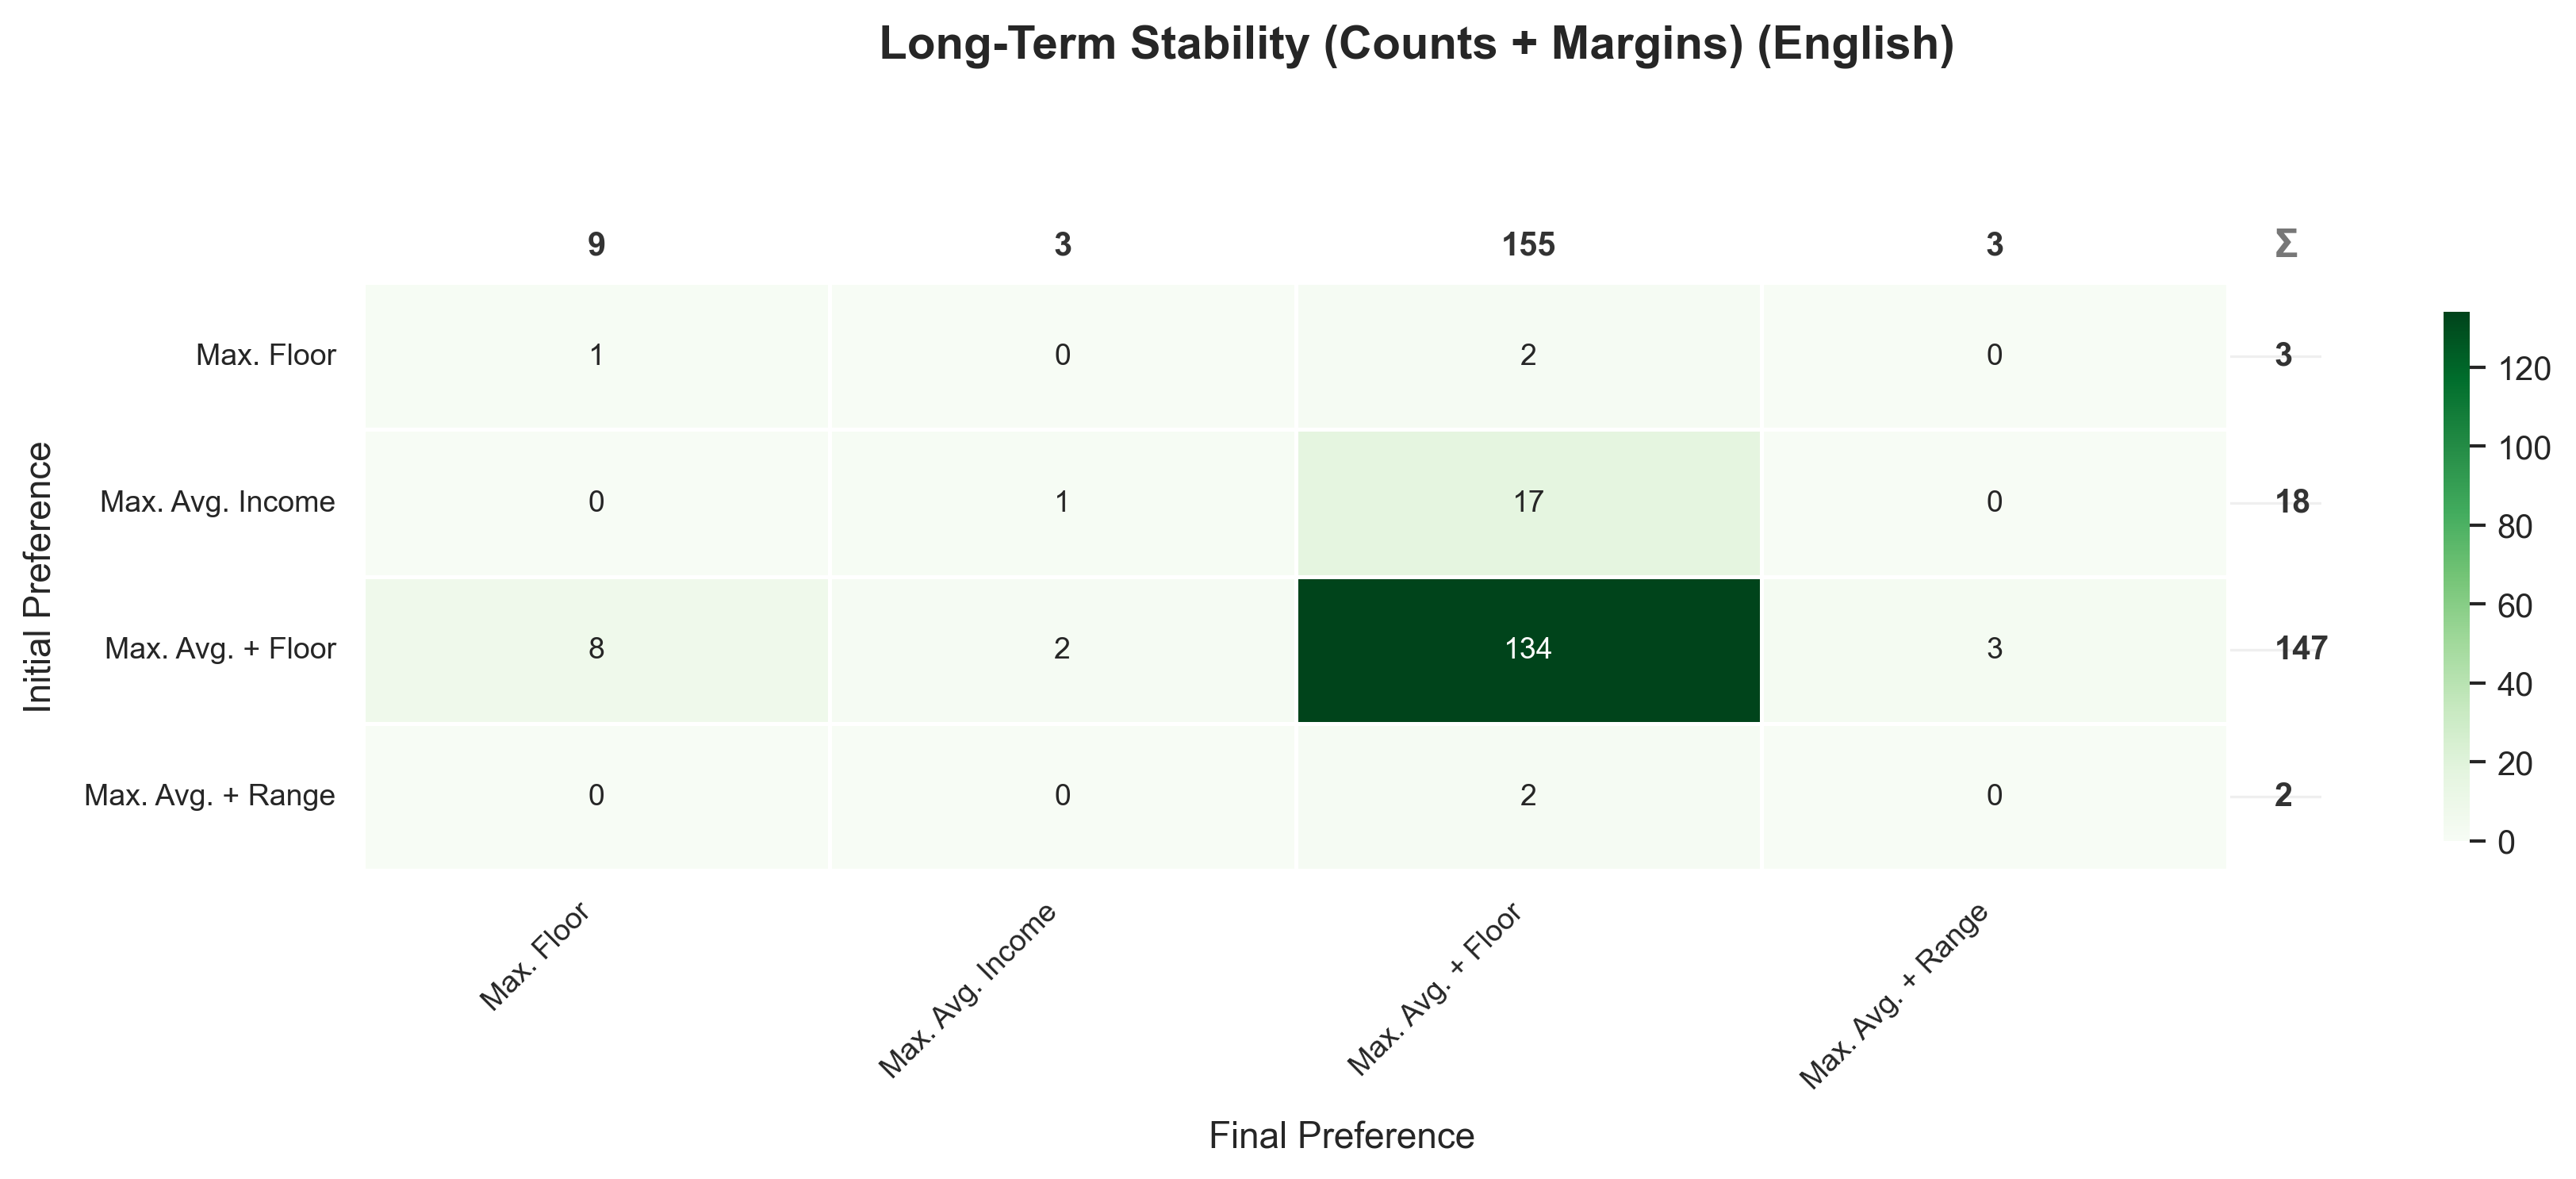

### Switcher Analysis: Income Class and Preference Changes

,Income Class,Changed Preference Count,Changed Preference %,Maintained Preference Count,Maintained Preference %,Diff Changed vs Maintained (pp)
0,Low,6,15.4,10,7.6,7.8
1,Medium-Low,10,25.6,31,23.7,1.9
2,Medium,19,48.7,66,50.4,-1.7
3,Medium-High,3,7.7,17,13.0,-5.3
4,High,1,2.6,7,5.3,-2.7


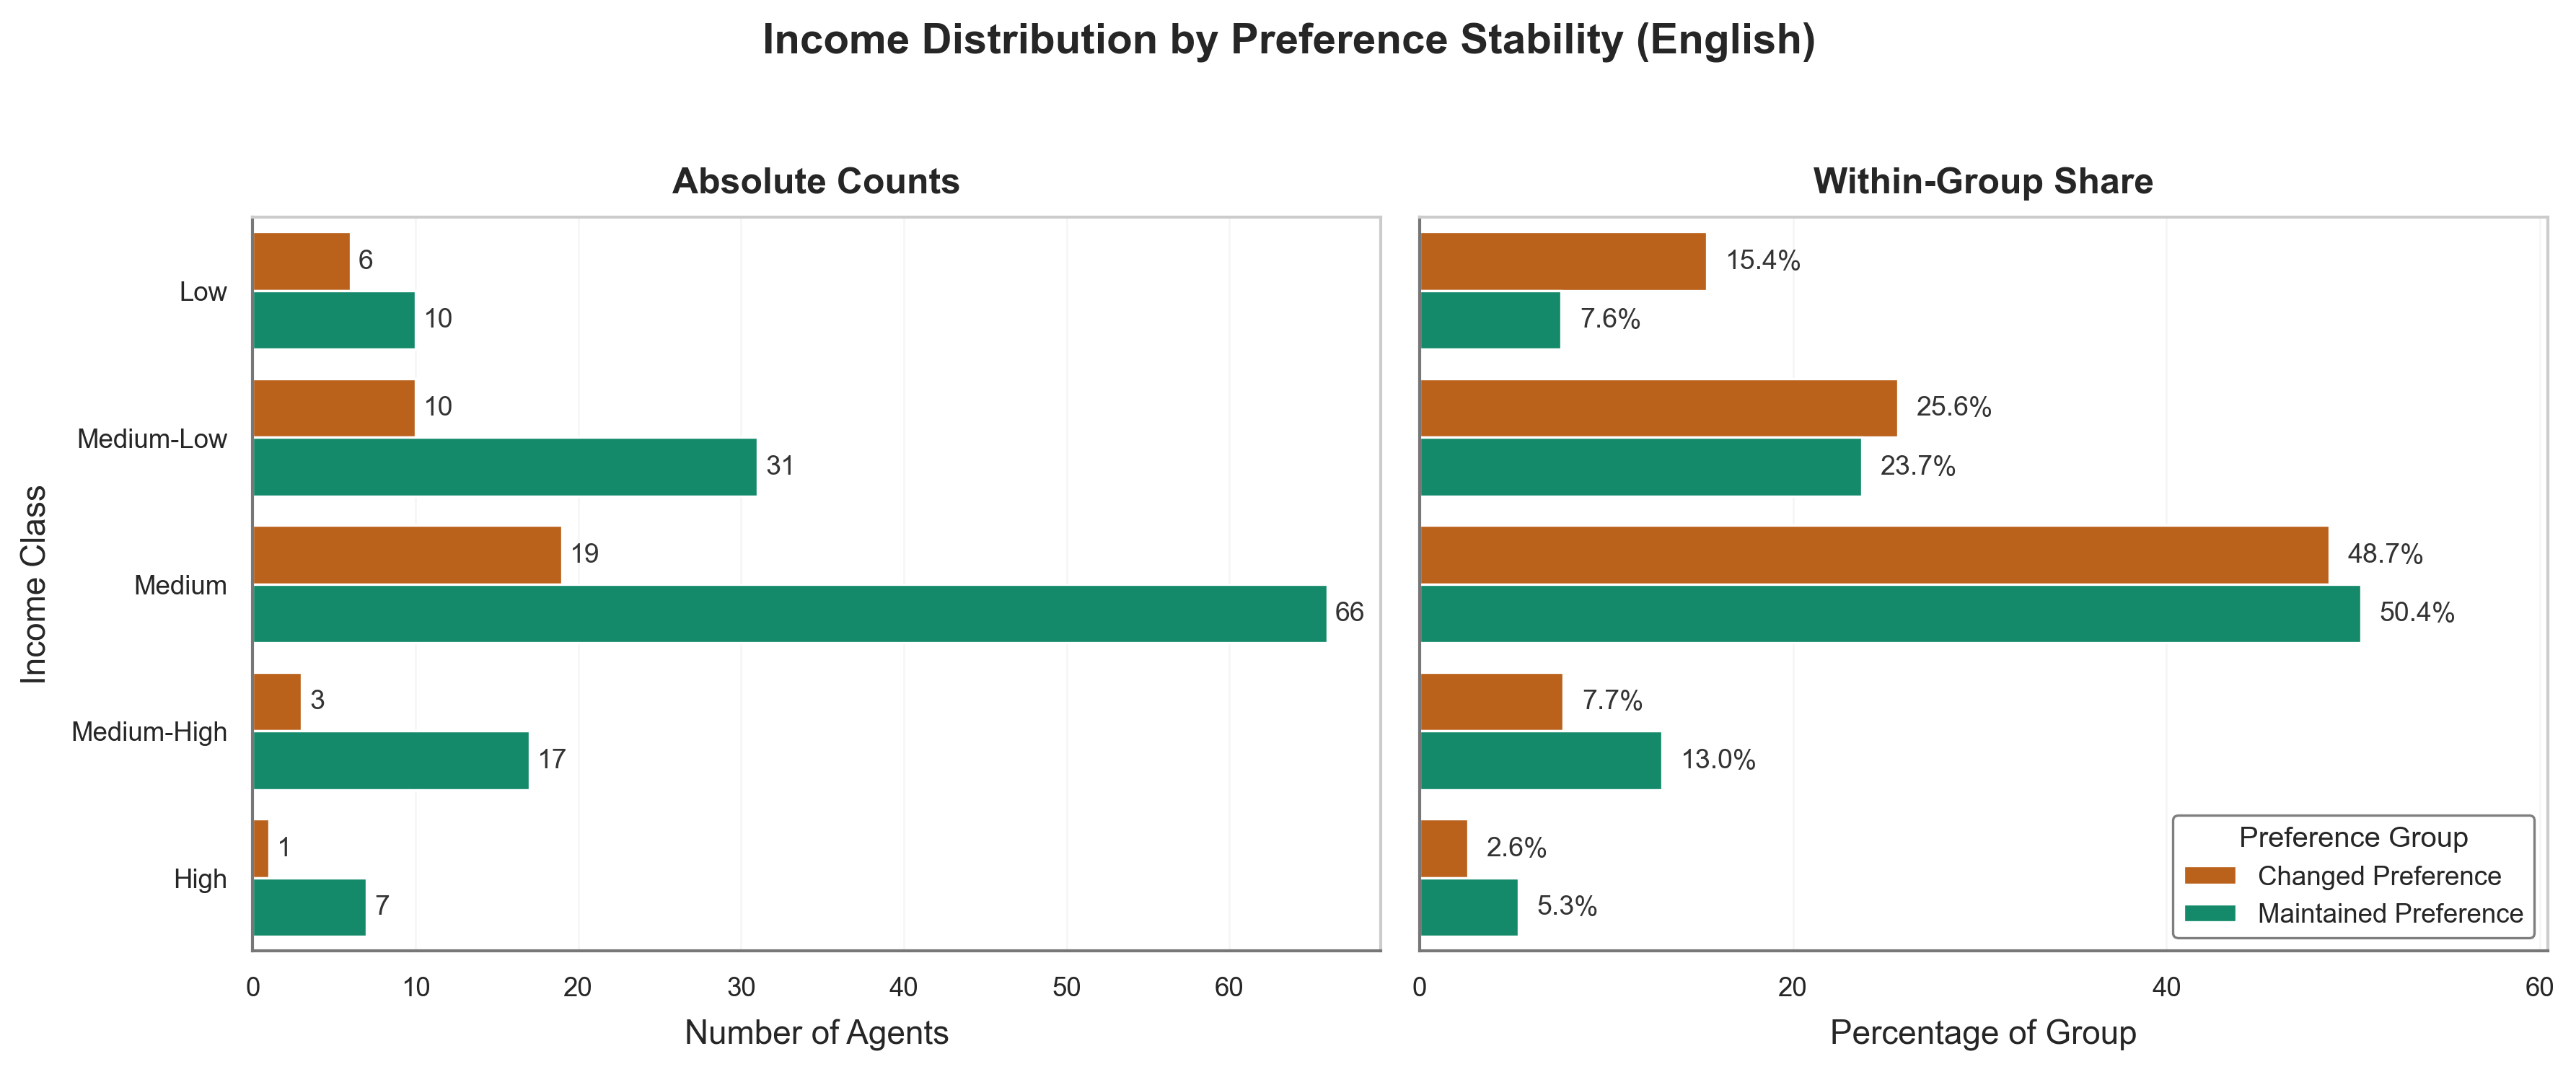

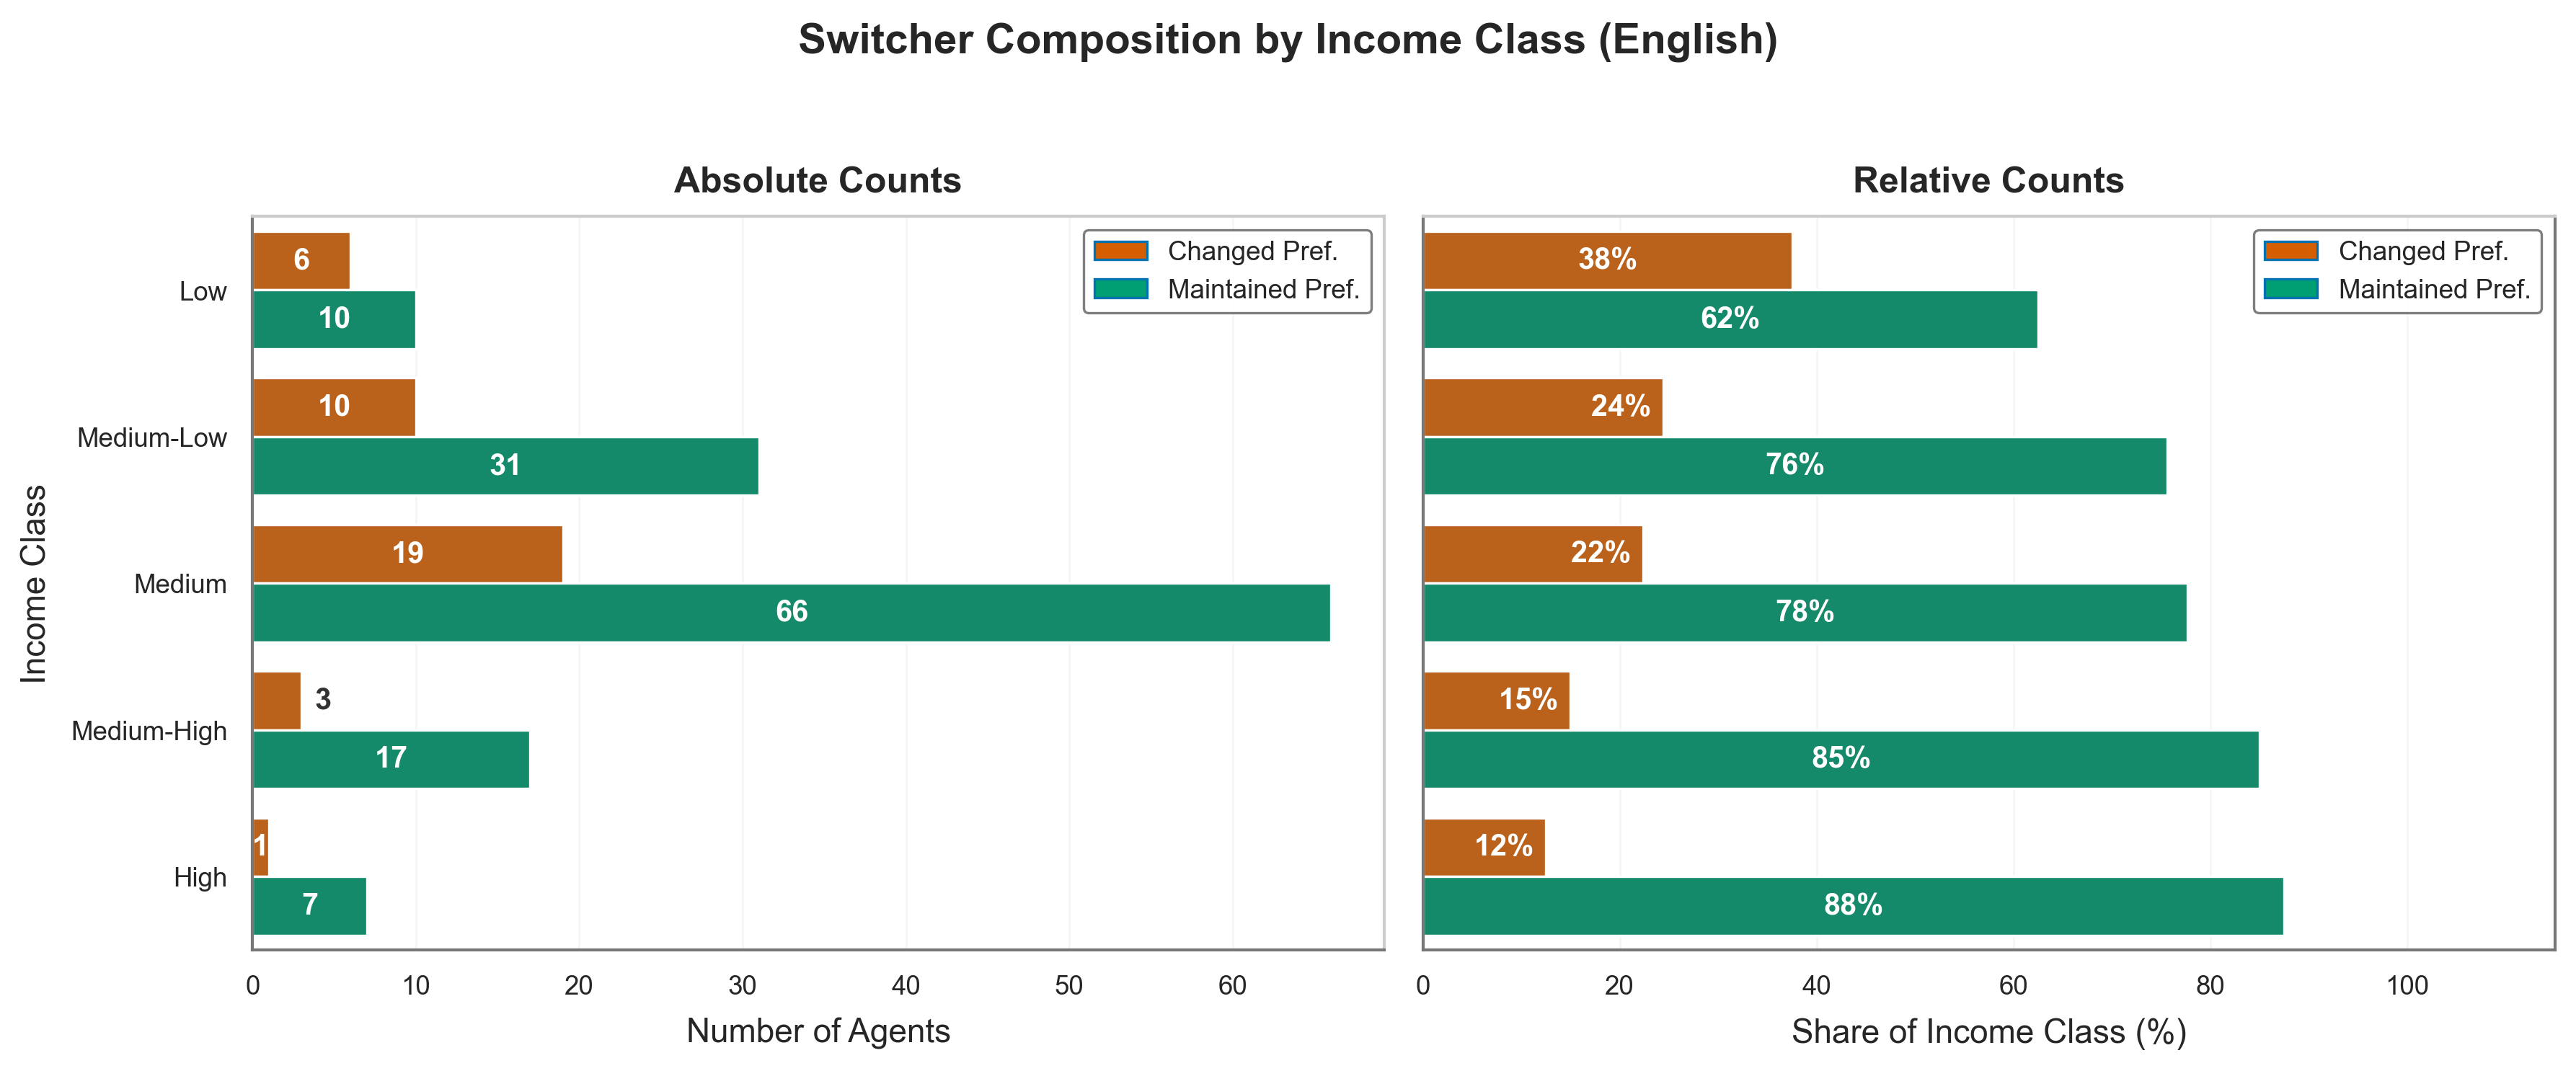

## Spanish Cohort

### Data Summary

,Metric,Value
0,Runs,34
1,Consensus runs,19
2,Agent sessions,170
3,Preference waves,4


Transition coverage: 170/170 agents with full wave data


### Preference Orderings by Wave

...

**Wave 3 - Final Phase 1**

,Preference Ordering,Count,Percentage
0,Max Avg + Floor > Max Floor > Max Avg + Range ...,52,30.6
1,Max Avg + Floor > Max Avg + Range > Max Floor ...,32,18.8
2,Max Avg + Range > Max Avg + Floor > Max Floor ...,21,12.4
3,Max Avg + Range > Max Floor > Max Avg + Floor ...,17,10.0
4,Max Avg + Floor > Max Avg + Range > Max Avg In...,12,7.1
5,Max Avg + Range > Max Avg + Floor > Max Avg In...,10,5.9
6,Max Avg + Range > Max Avg Income > Max Avg + F...,6,3.5
7,Max Avg + Floor > Max Floor > Max Avg Income >...,4,2.4
8,Max Avg + Floor > Max Avg Income > Max Avg + R...,3,1.8
9,Max Avg + Floor > Max Avg Income > Max Floor >...,3,1.8


**Wave 4 - Post-Group**

,Preference Ordering,Count,Percentage
0,Max Avg + Floor > Max Floor > Max Avg + Range ...,49,28.8
1,Max Avg + Floor > Max Avg + Range > Max Floor ...,39,22.9
2,Max Avg + Floor > Max Avg + Range > Max Avg In...,18,10.6
3,Max Avg + Range > Max Avg + Floor > Max Floor ...,18,10.6
4,Max Avg + Range > Max Avg + Floor > Max Avg In...,12,7.1
5,Max Floor > Max Avg + Floor > Max Avg + Range ...,11,6.5
6,Max Avg + Range > Max Floor > Max Avg + Floor ...,7,4.1
7,Max Avg + Floor > Max Avg Income > Max Avg + R...,6,3.5
8,Max Avg + Floor > Max Floor > Max Avg Income >...,3,1.8
9,Max Avg Income > Max Avg + Floor > Max Floor >...,2,1.2


### Rounds to Outcome

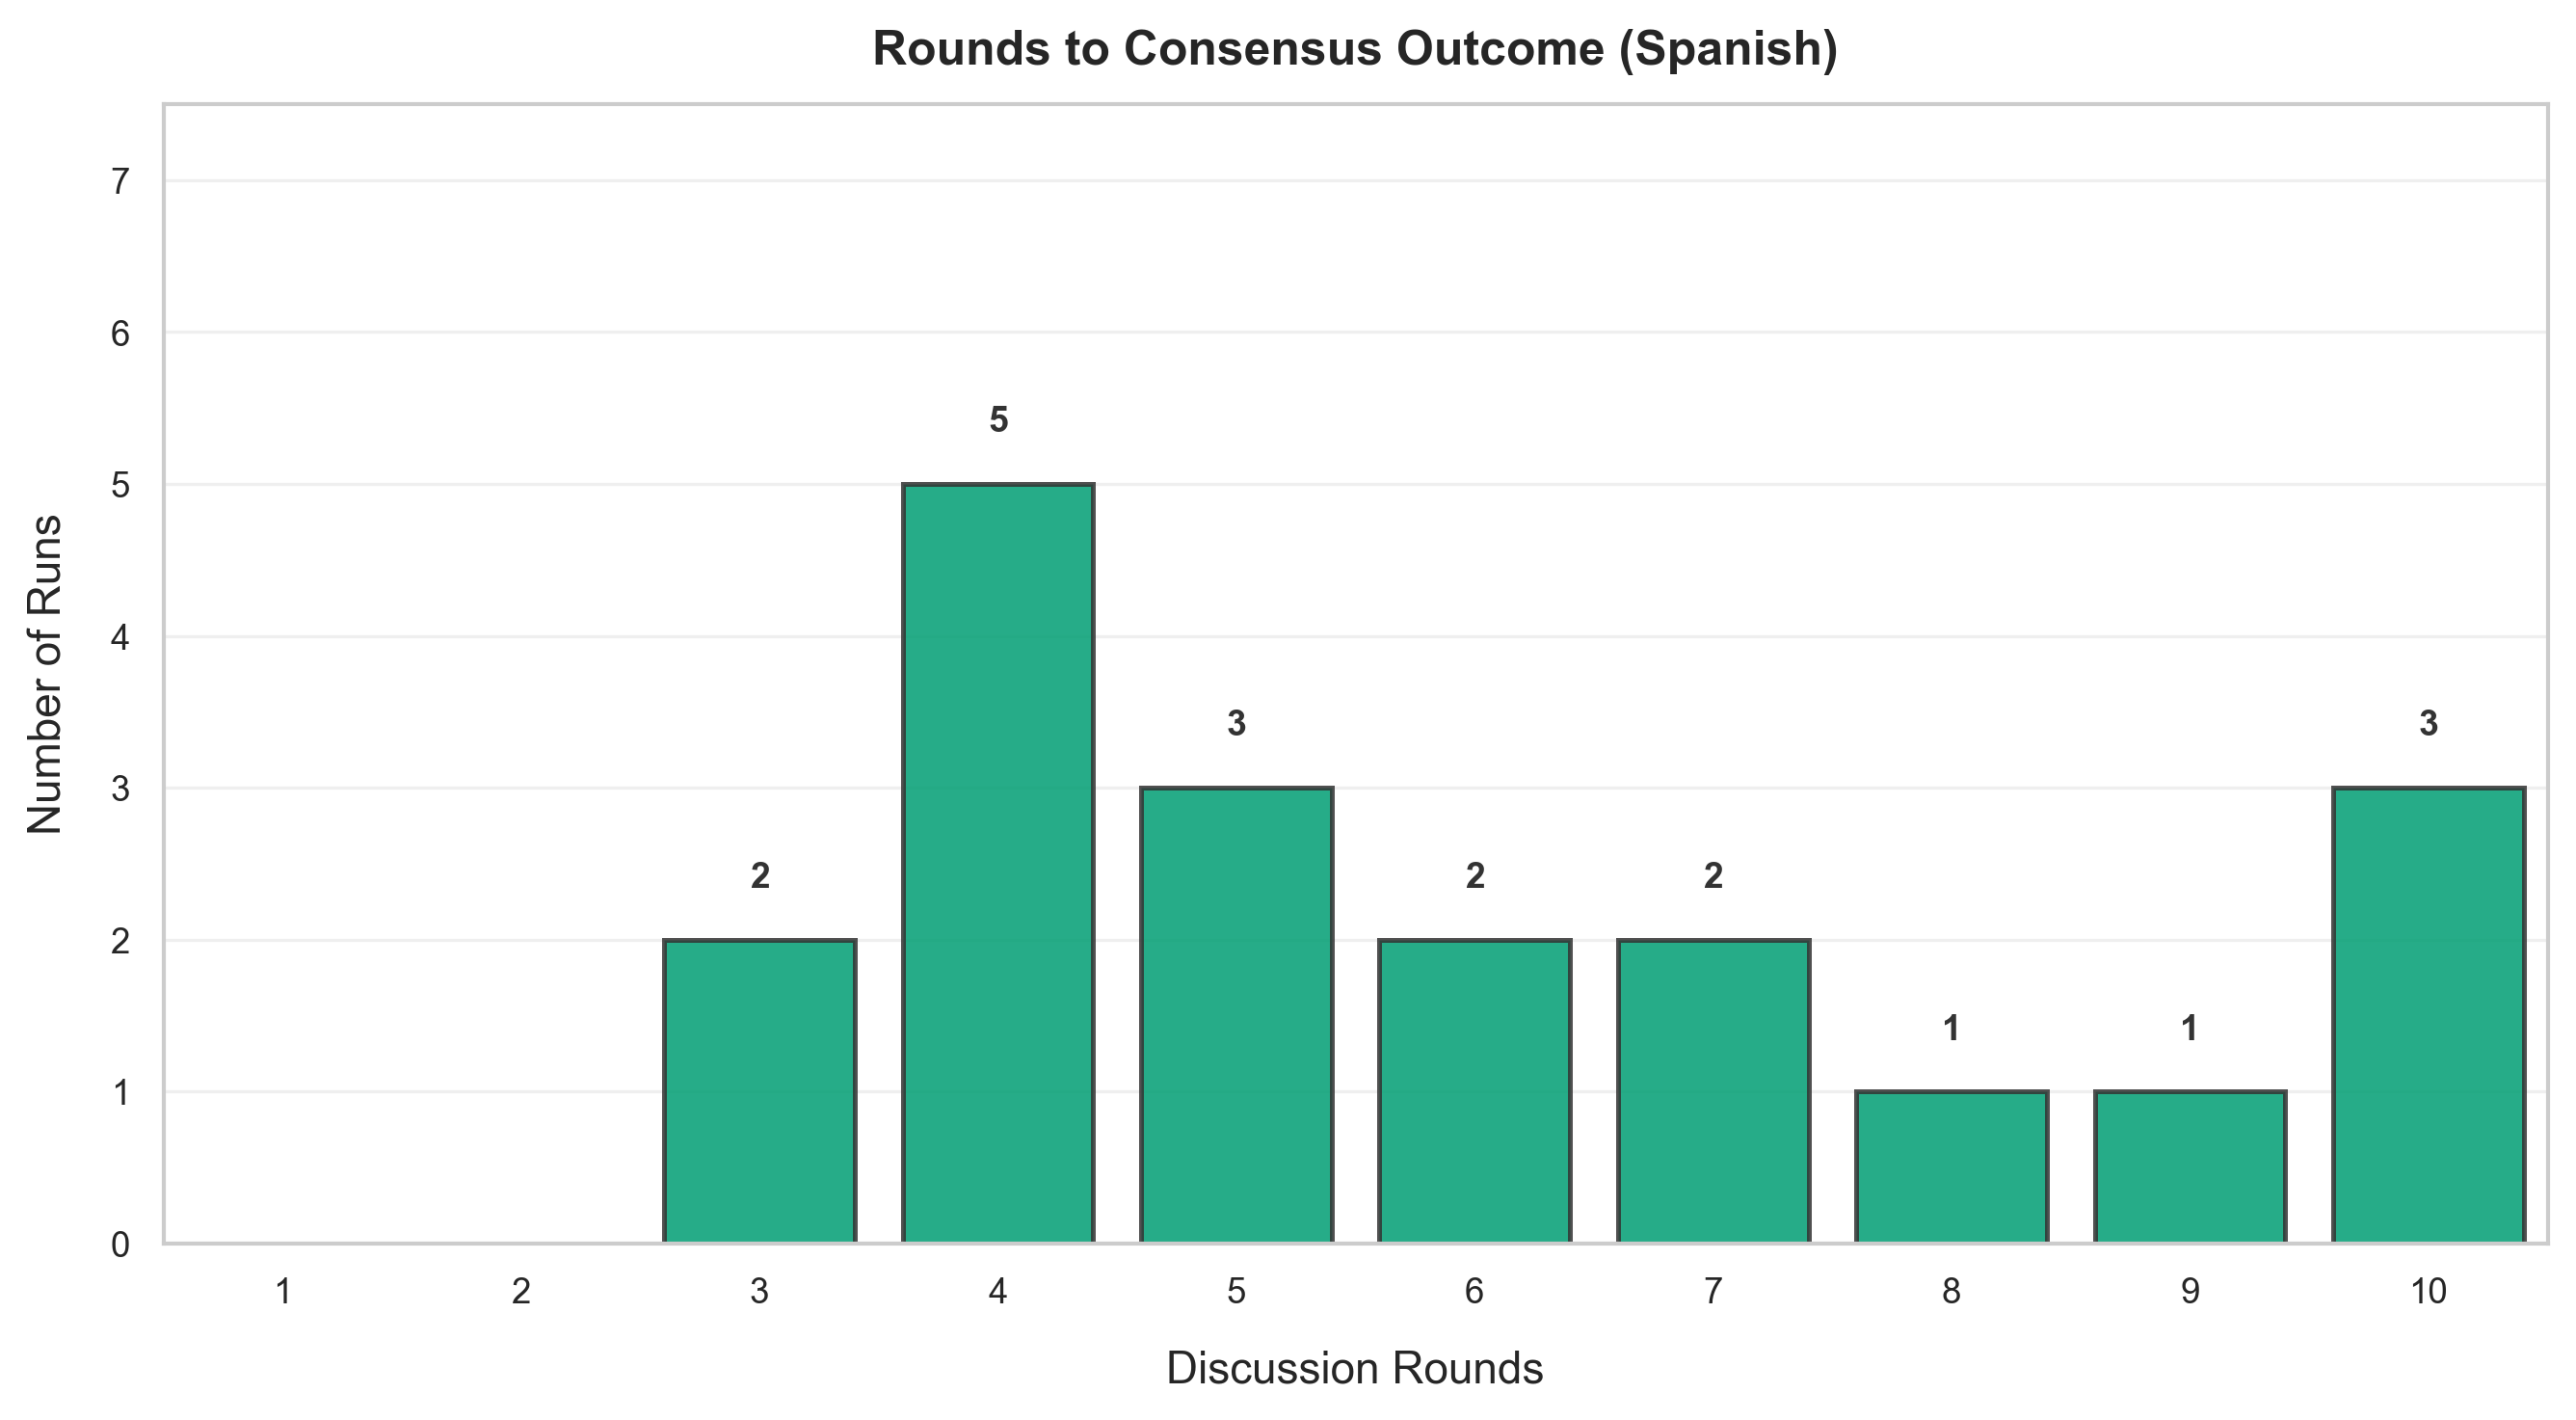

Consensus Timing Summary:
  Total consensus runs: 19
  Range: 3-10 rounds
  Mean: 6.00 rounds  |  Median: 5 rounds


### Floor Constraint Amounts

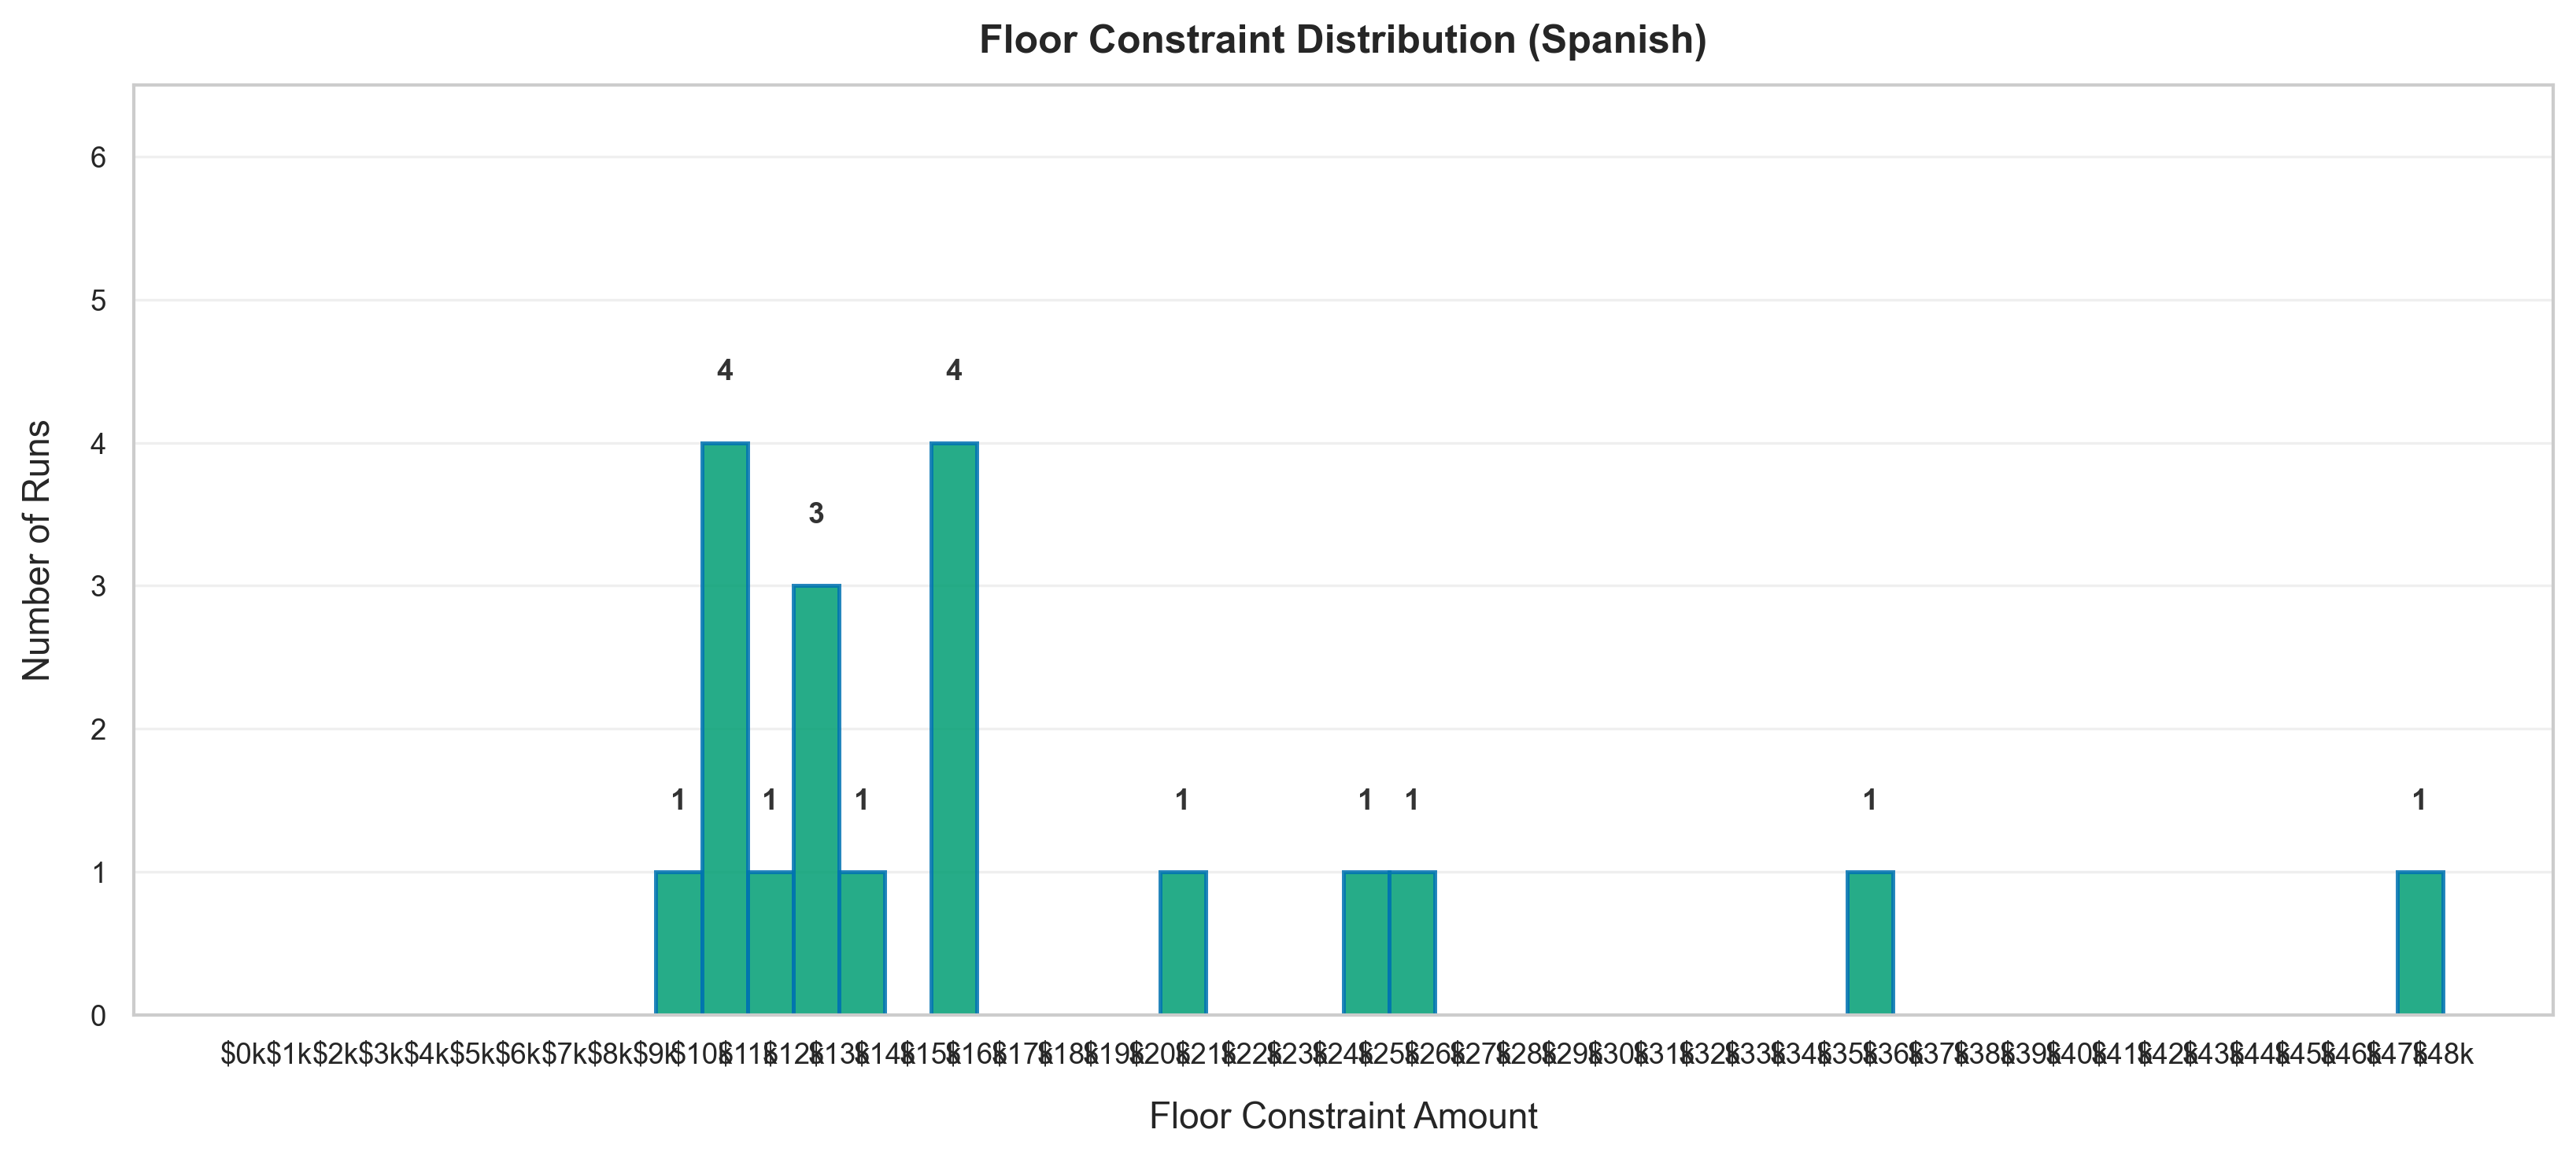

Floor Amount Summary:
  Total votes: 19
  Range: $9,000 - $48,000
  Mean: $16,895  |  Median: $13,000  |  SD: $9,760


### Voting Attempts and Success Rate

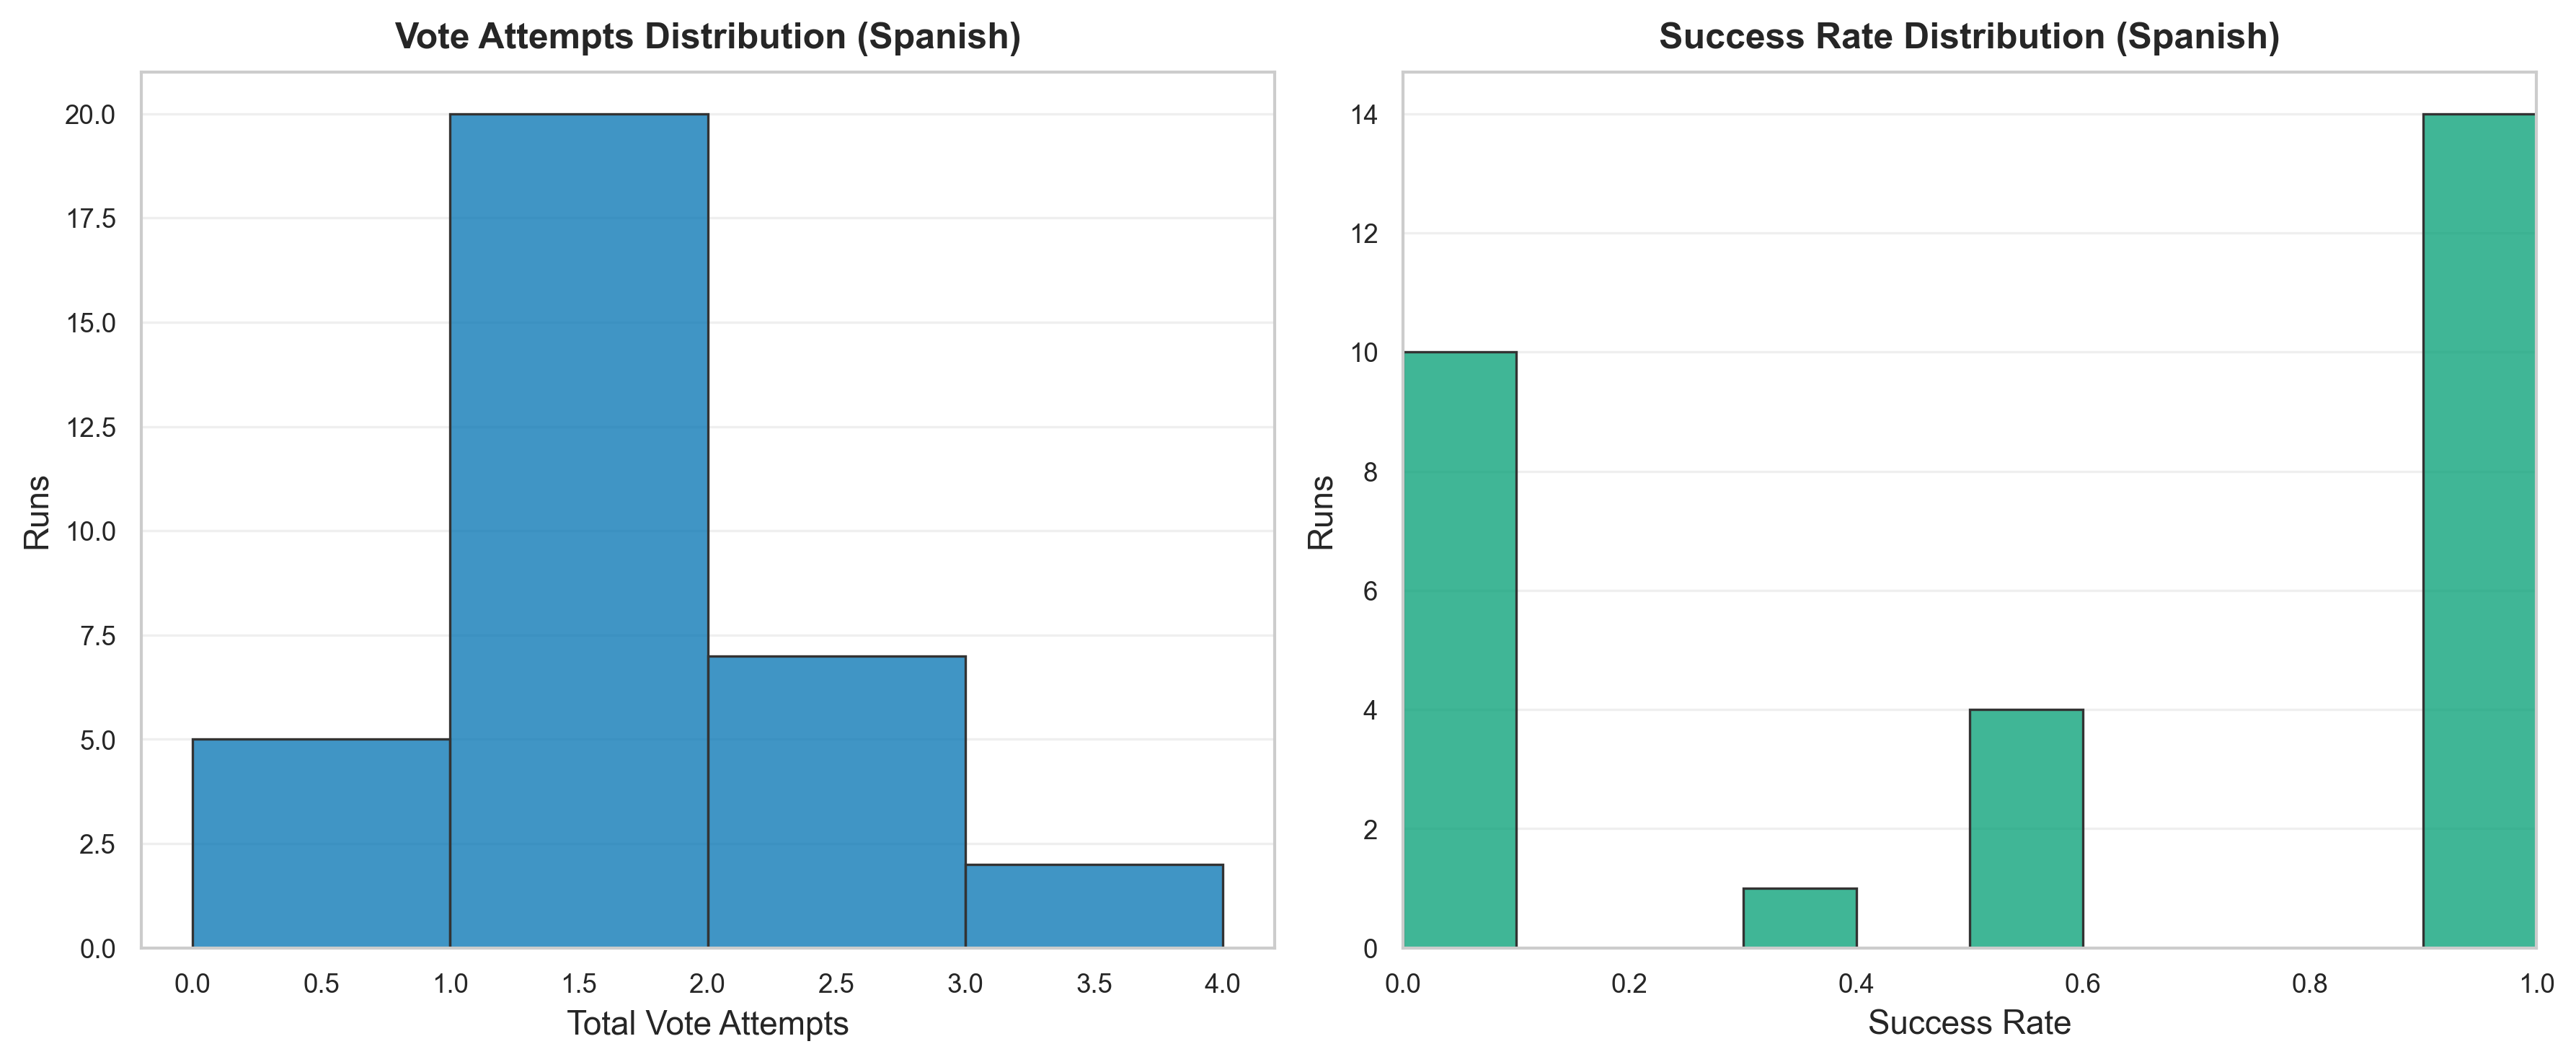

Voting Attempts Summary:
  Mean attempts per run: 1.18
  Median attempts per run: 1
  Mean success rate: 56.32%
  Median success rate: 50.00%


### Preference Evolution and Transitions

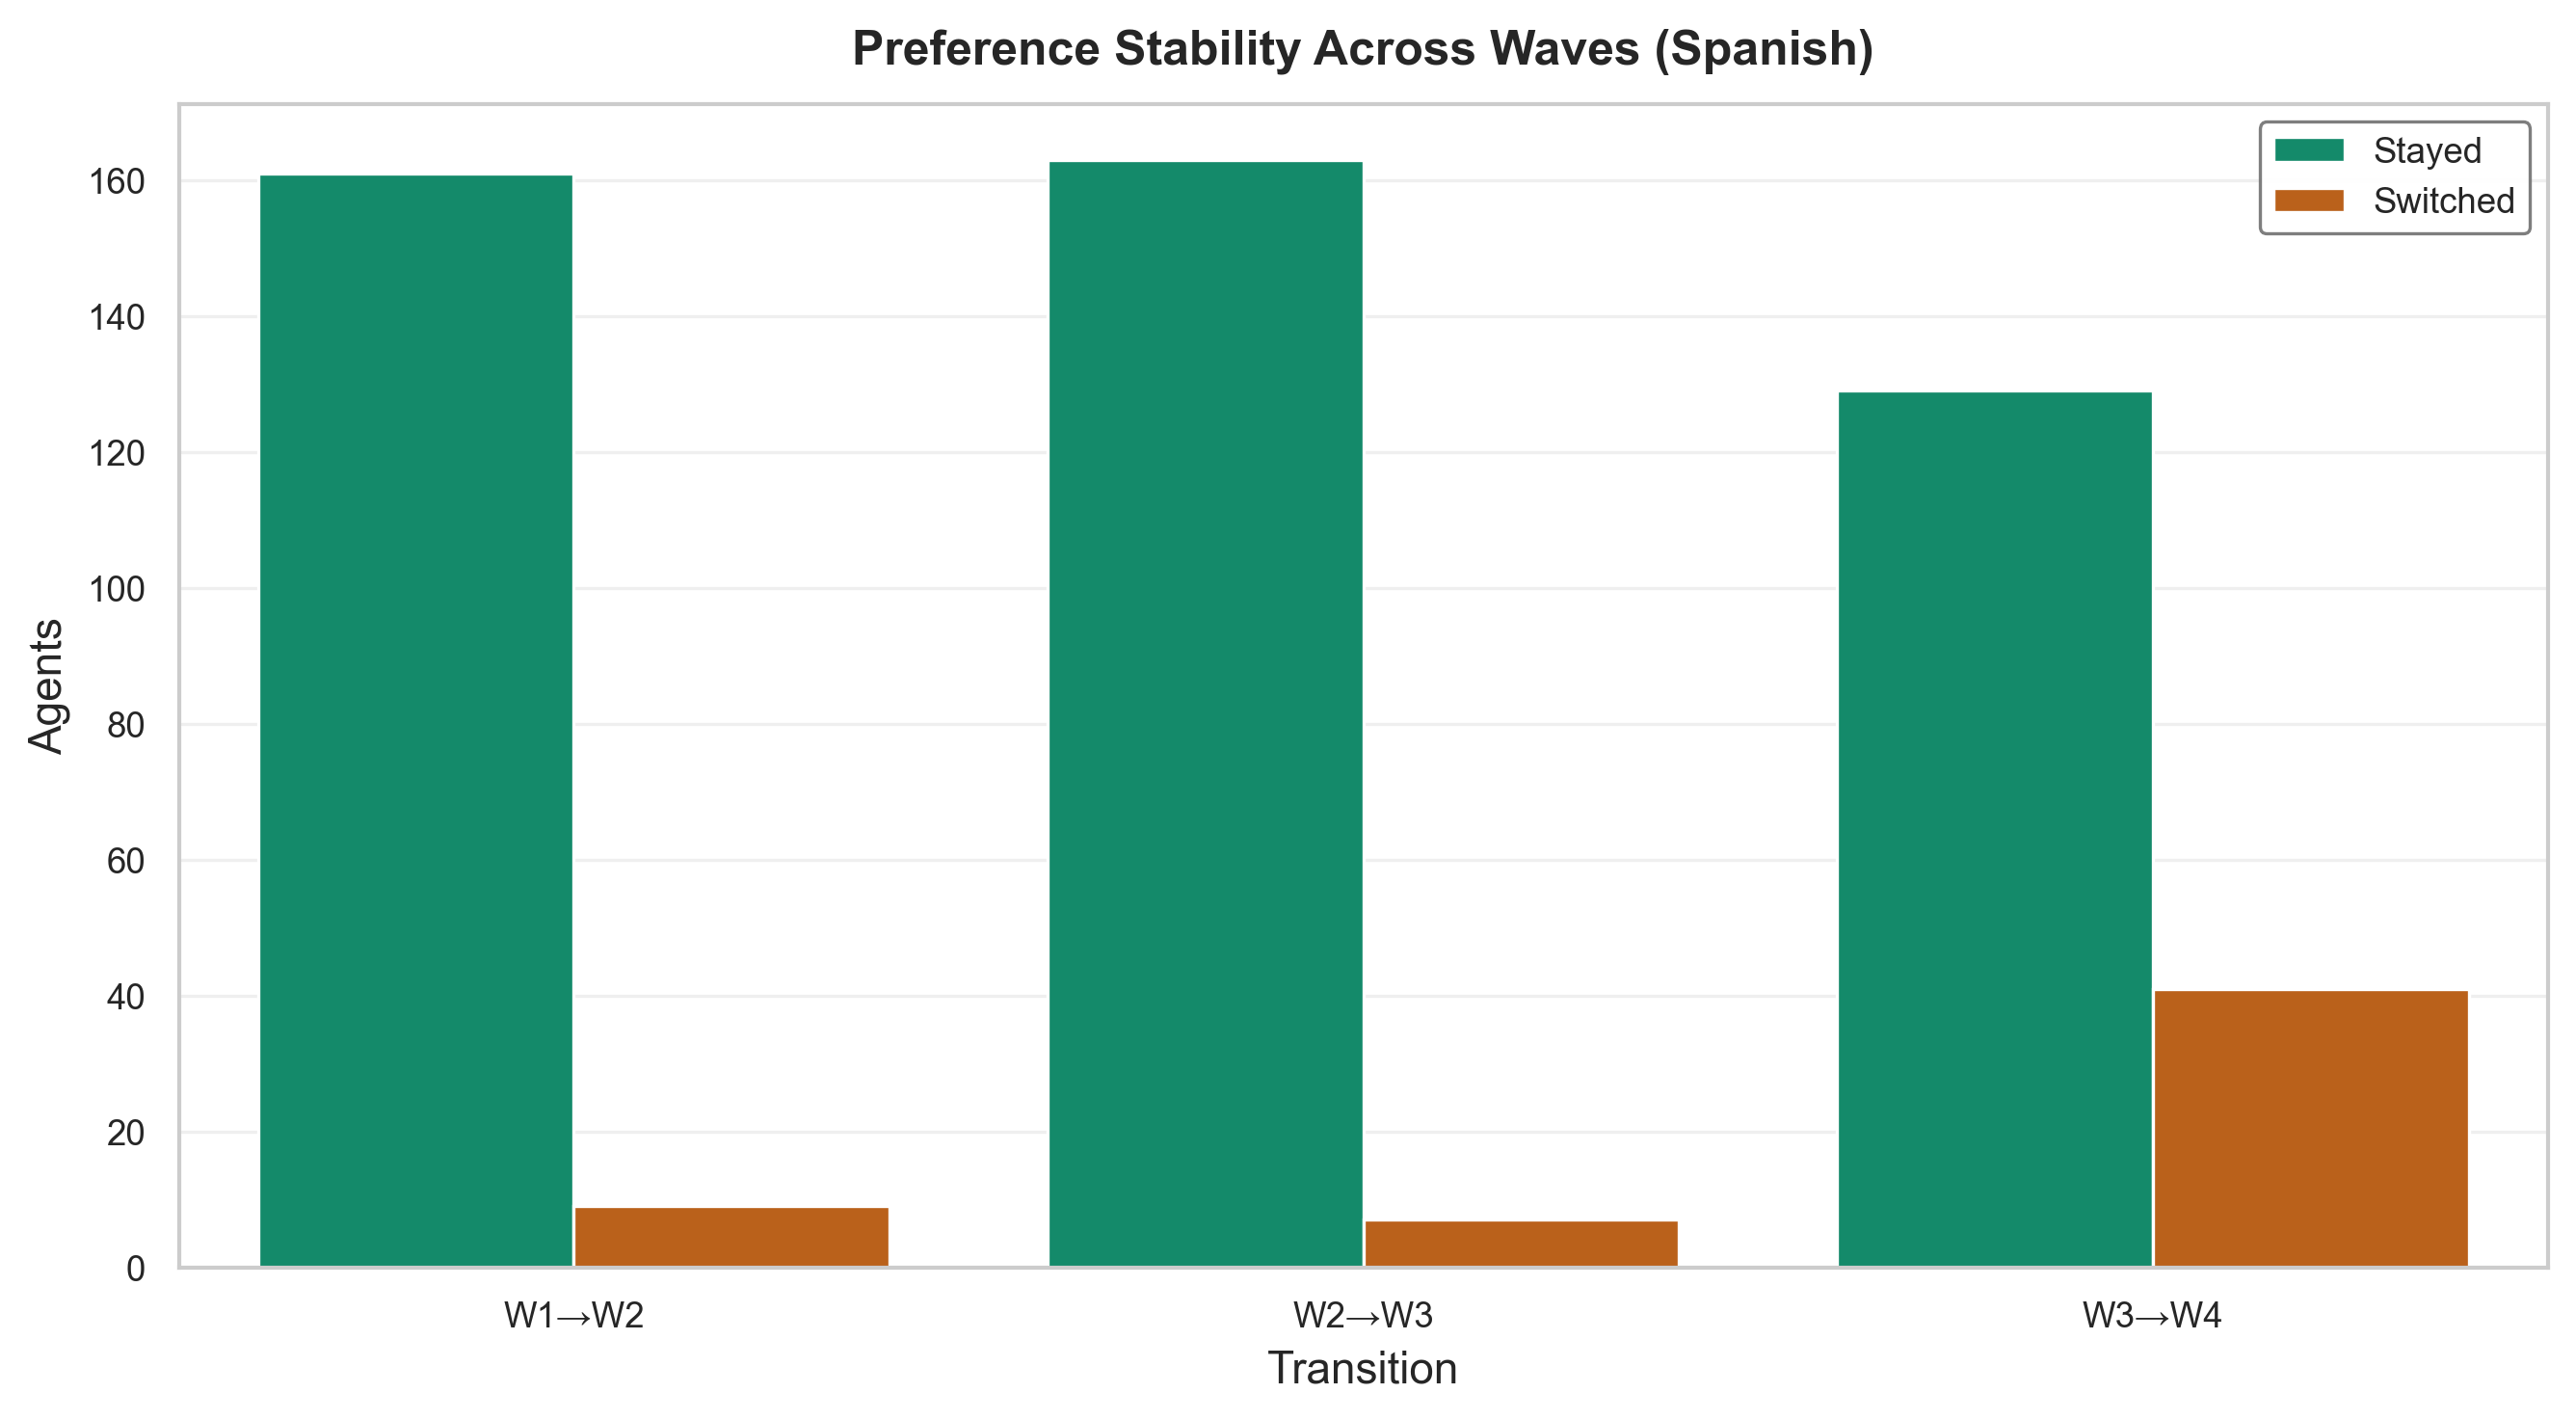

Stability Breakdown:
  W1→W2: 161/170 stayed (94.7%)
  W2→W3: 163/170 stayed (95.9%)
  W3→W4: 129/170 stayed (75.9%)


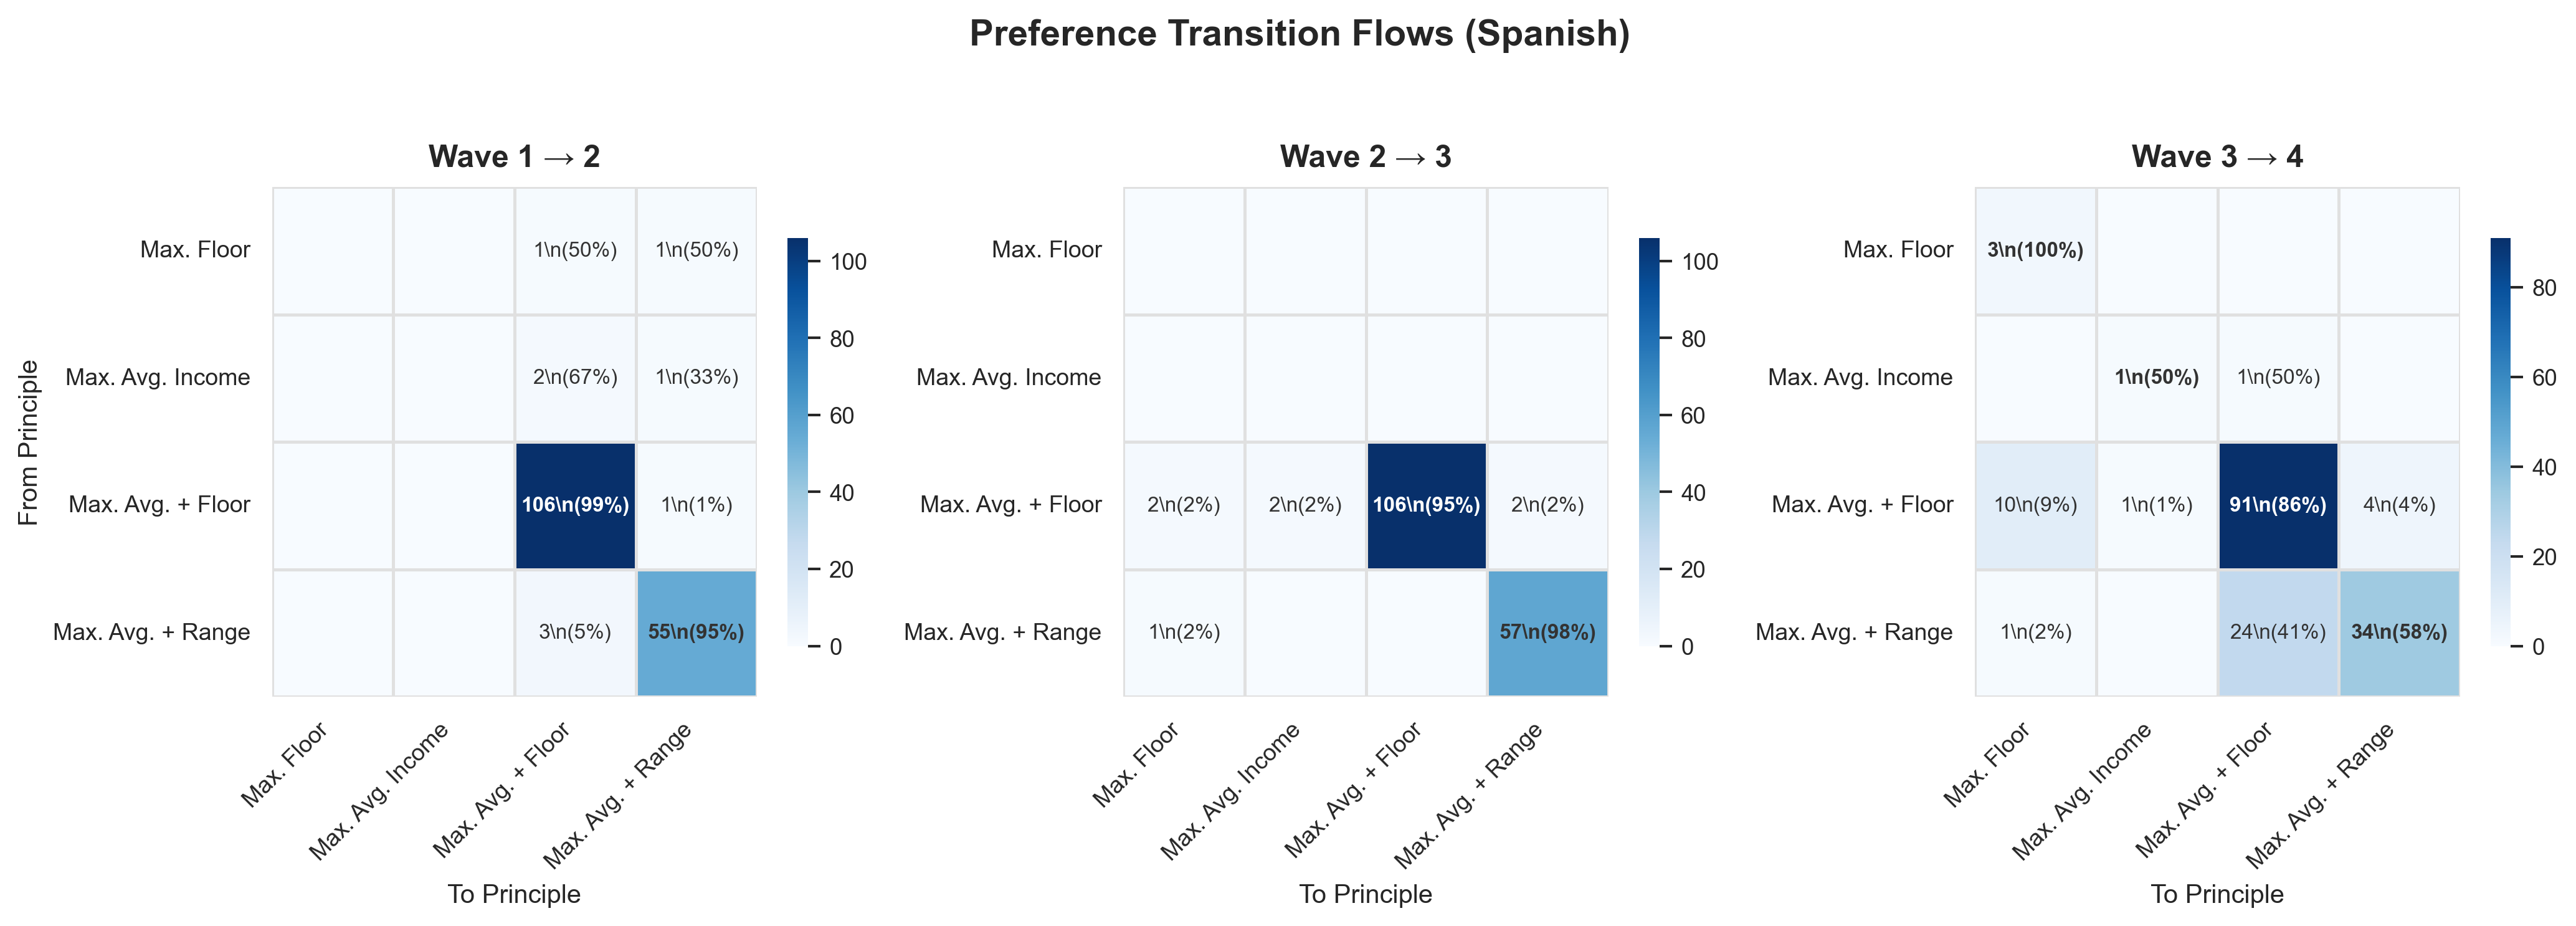

Transition Stay Rates:
  Wave 1 → 2: 161/170 stayed (94.7%)
  Wave 2 → 3: 163/170 stayed (95.9%)
  Wave 3 → 4: 129/170 stayed (75.9%)


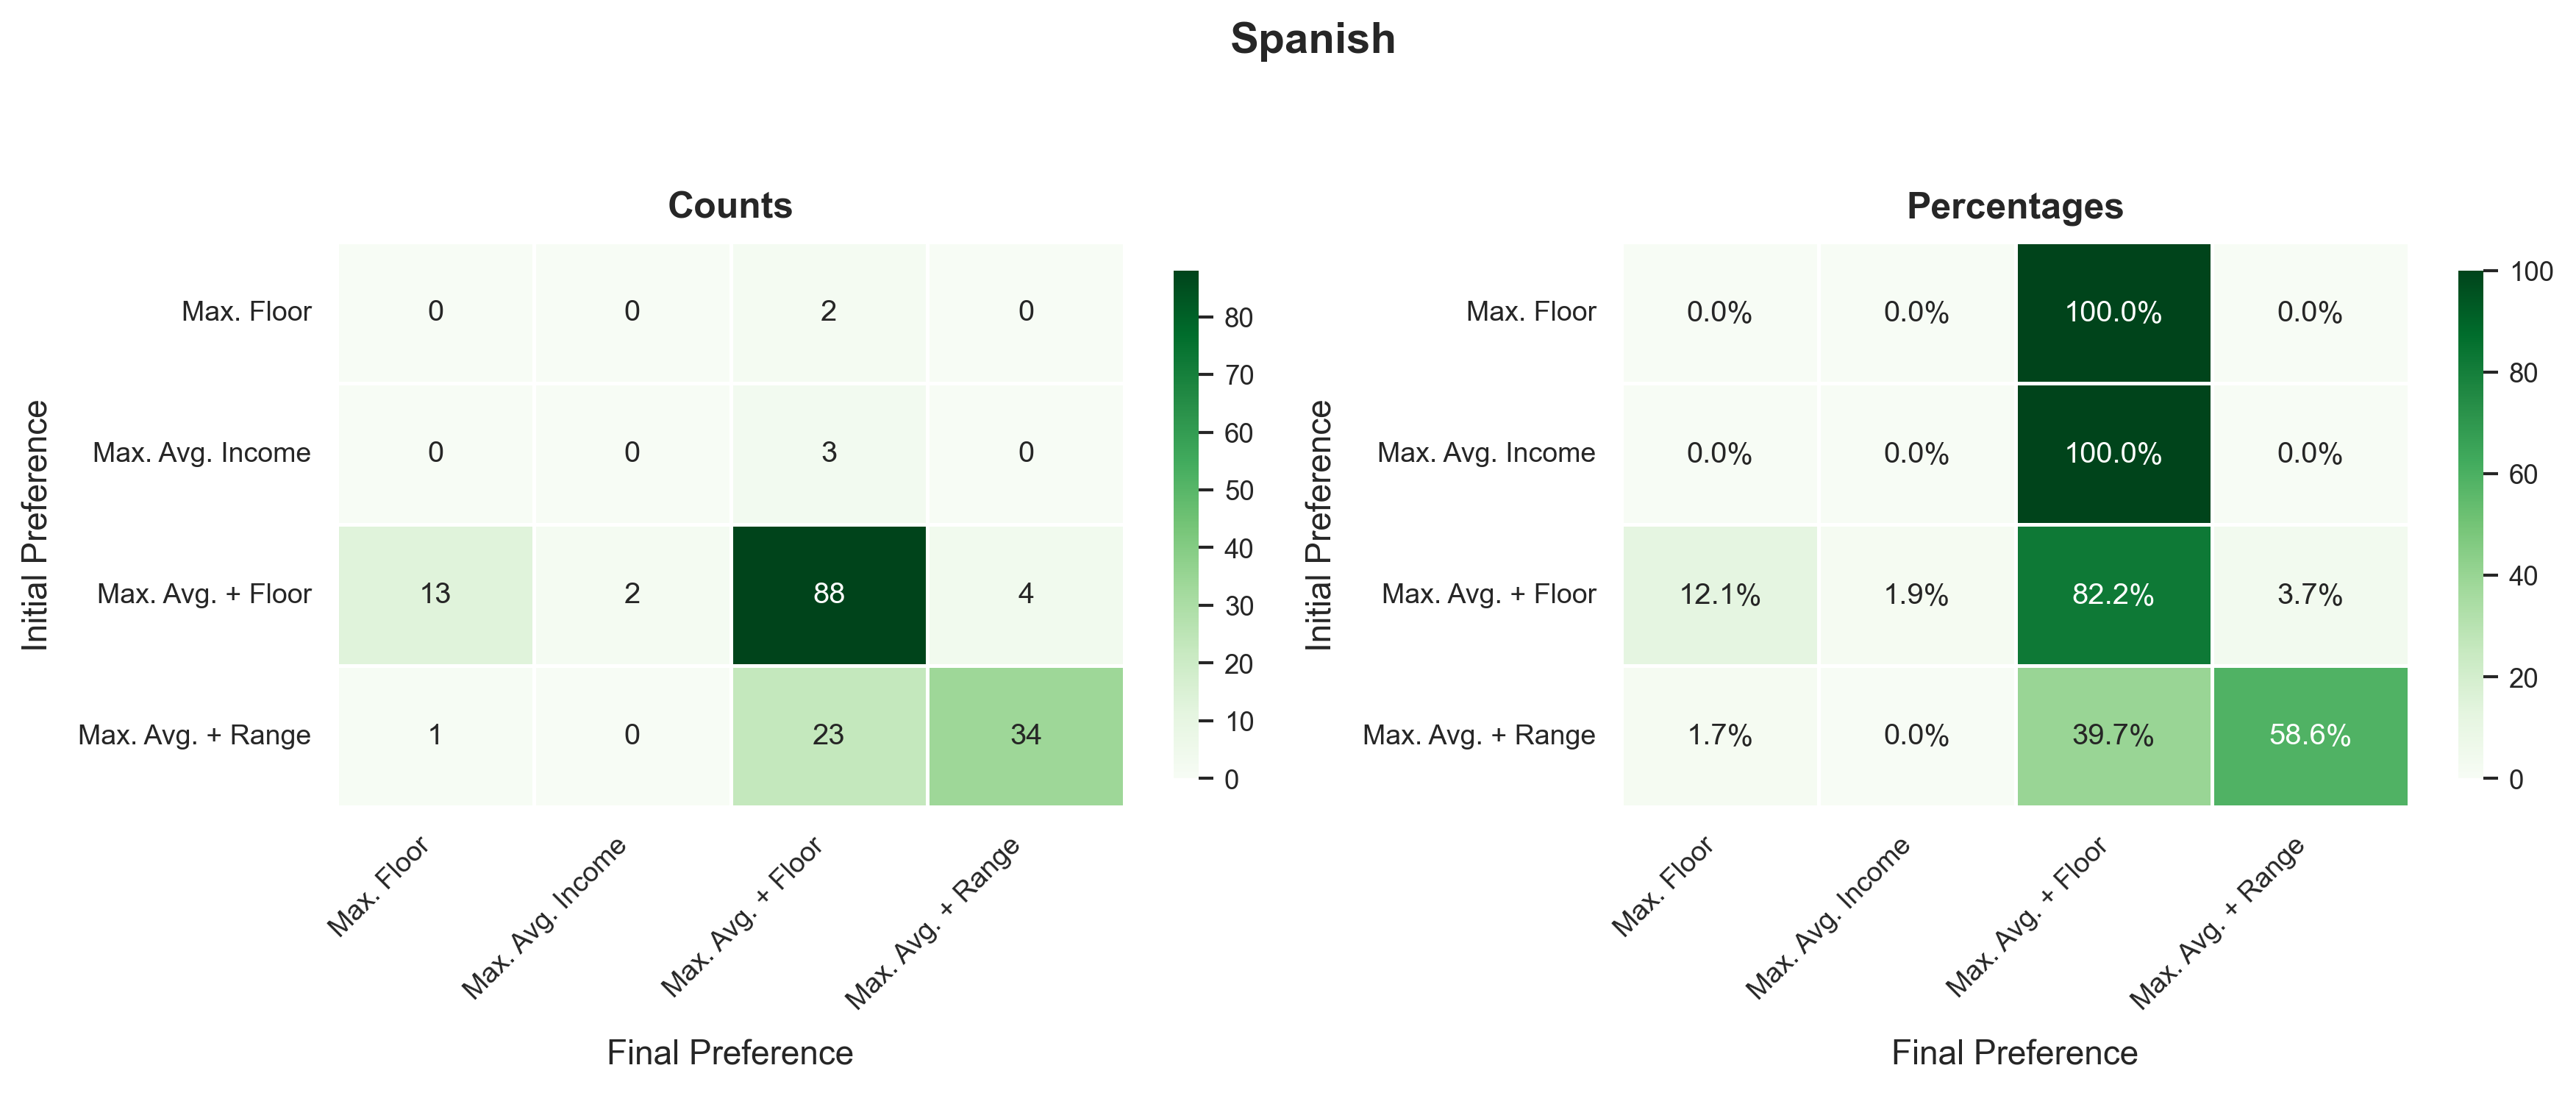

Long-Term Stability (Wave 1 → Wave 4) [Spanish]
Max. Floor               :   0/  2 maintained (  0.0%)
Max. Avg. Income         :   0/  3 maintained (  0.0%)
Max. Avg. + Floor        :  88/107 maintained ( 82.2%)
Max. Avg. + Range        :  34/ 58 maintained ( 58.6%)
OVERALL                  : 122/170 agents ( 71.8%)


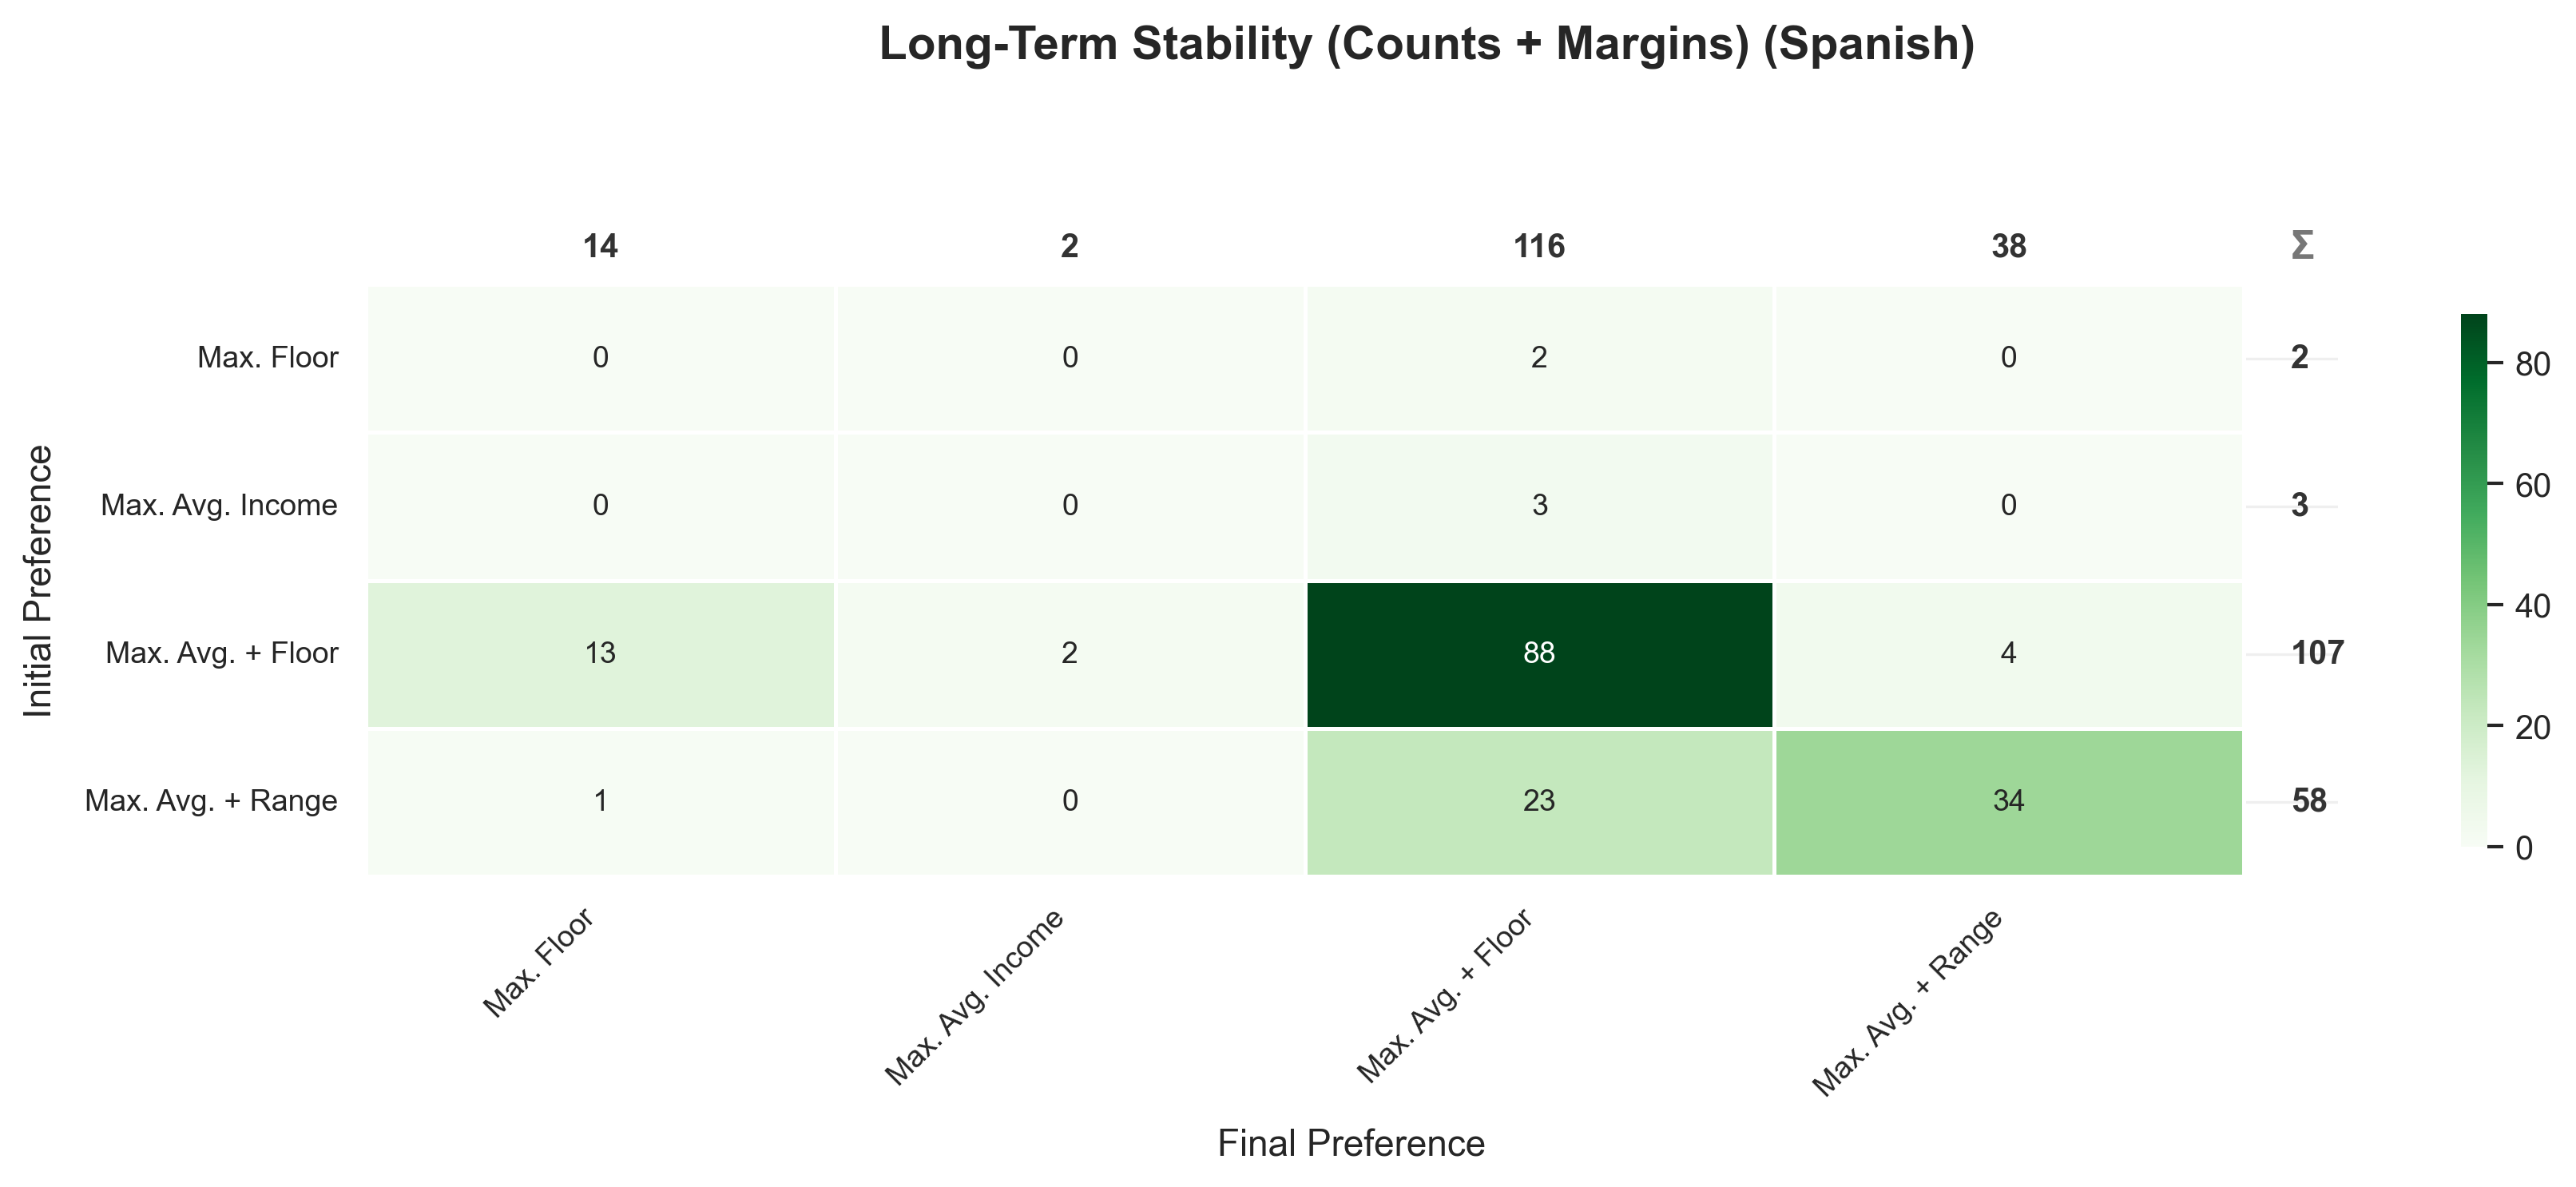

### Switcher Analysis: Income Class and Preference Changes

,Income Class,Changed Preference Count,Changed Preference %,Maintained Preference Count,Maintained Preference %,Diff Changed vs Maintained (pp)
0,Low,12,23.5,8,6.7,16.8
1,Medium-Low,12,23.5,25,21.0,2.5
2,Medium,20,39.2,73,61.3,-22.1
3,Medium-High,6,11.8,9,7.6,4.2
4,High,1,2.0,4,3.4,-1.4


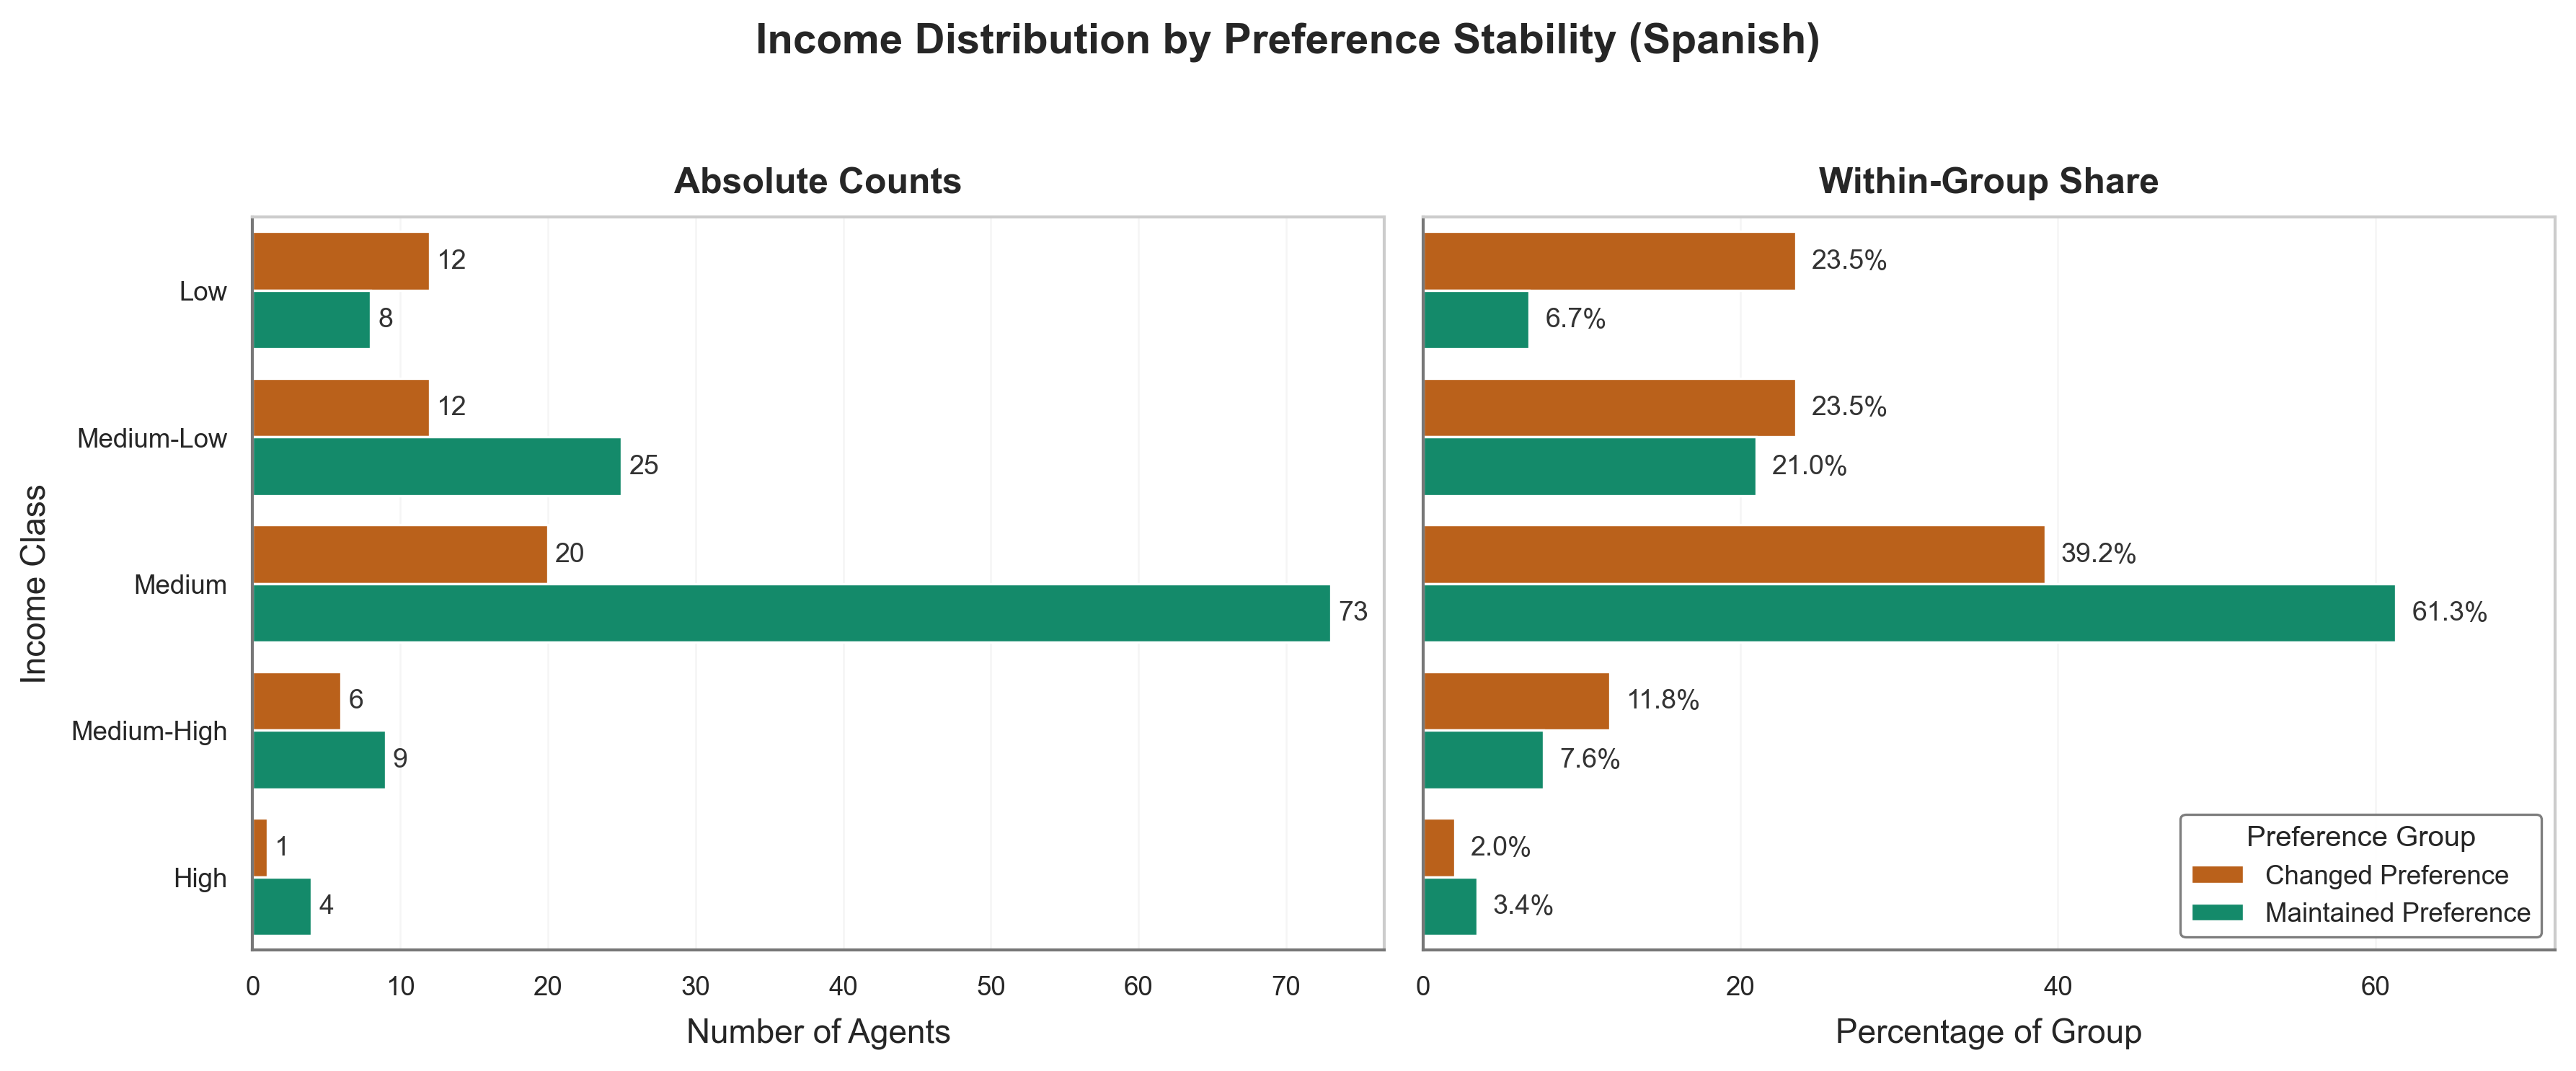

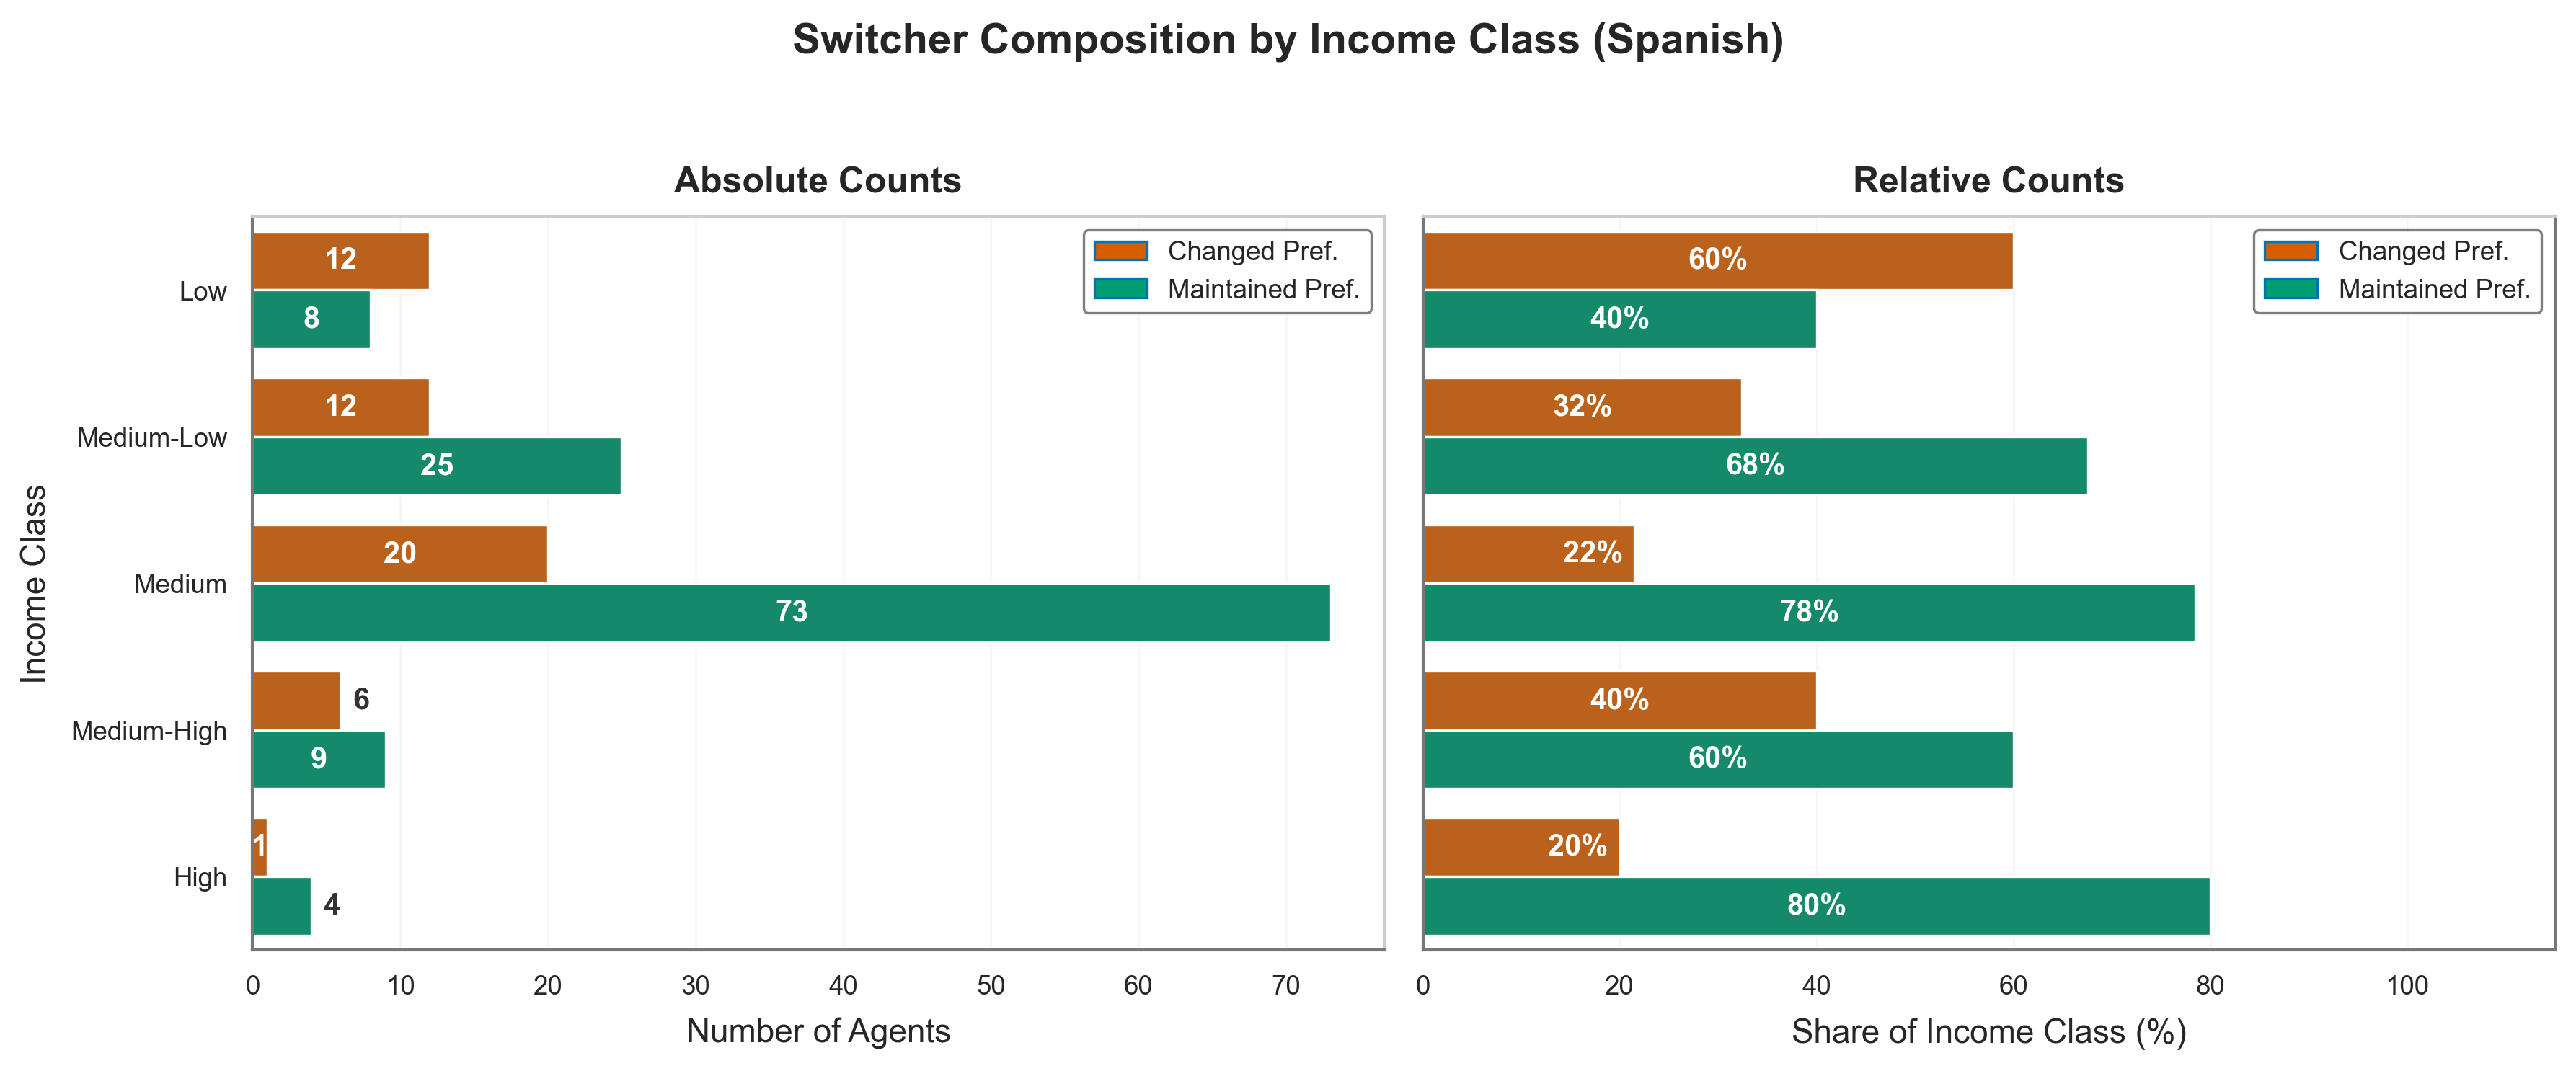

## Mandarin Cohort

### Data Summary

,Metric,Value
0,Runs,34
1,Consensus runs,28
2,Agent sessions,170
3,Preference waves,4


Transition coverage: 170/170 agents with full wave data


### Preference Orderings by Wave

...

**Wave 3 - Final Phase 1**

,Preference Ordering,Count,Percentage
0,Max Avg + Floor > Max Floor > Max Avg Income >...,42,24.7
1,Max Avg + Floor > Max Avg + Range > Max Floor ...,34,20.0
2,Max Avg + Floor > Max Floor > Max Avg + Range ...,29,17.1
3,Max Floor > Max Avg Income > Max Avg + Floor >...,28,16.5
4,Max Avg + Floor > Max Avg Income > Max Avg + R...,10,5.9
5,Max Avg + Floor > Max Avg + Range > Max Avg In...,9,5.3
6,Max Avg + Floor > Max Avg Income > Max Floor >...,8,4.7
7,Max Floor > Max Avg + Floor > Max Avg + Range ...,6,3.5
8,Max Avg Income > Max Avg + Floor > Max Avg + R...,3,1.8
9,Max Avg + Range > Max Avg + Floor > Max Avg In...,1,0.6


**Wave 4 - Post-Group**

,Preference Ordering,Count,Percentage
0,Max Avg + Floor > Max Floor > Max Avg Income >...,49,28.8
1,Max Avg + Floor > Max Avg + Range > Max Floor ...,39,22.9
2,Max Avg + Floor > Max Floor > Max Avg + Range ...,22,12.9
3,Max Avg + Floor > Max Avg Income > Max Floor >...,16,9.4
4,Max Floor > Max Avg + Floor > Max Avg + Range ...,12,7.1
5,Max Avg + Floor > Max Avg Income > Max Avg + R...,10,5.9
6,Max Avg + Floor > Max Avg + Range > Max Avg In...,9,5.3
7,Max Floor > Max Avg Income > Max Avg + Floor >...,6,3.5
8,Max Floor > Max Avg + Range > Max Avg + Floor ...,2,1.2
9,Max Avg + Range > Max Avg + Floor > Max Floor ...,1,0.6


### Rounds to Outcome

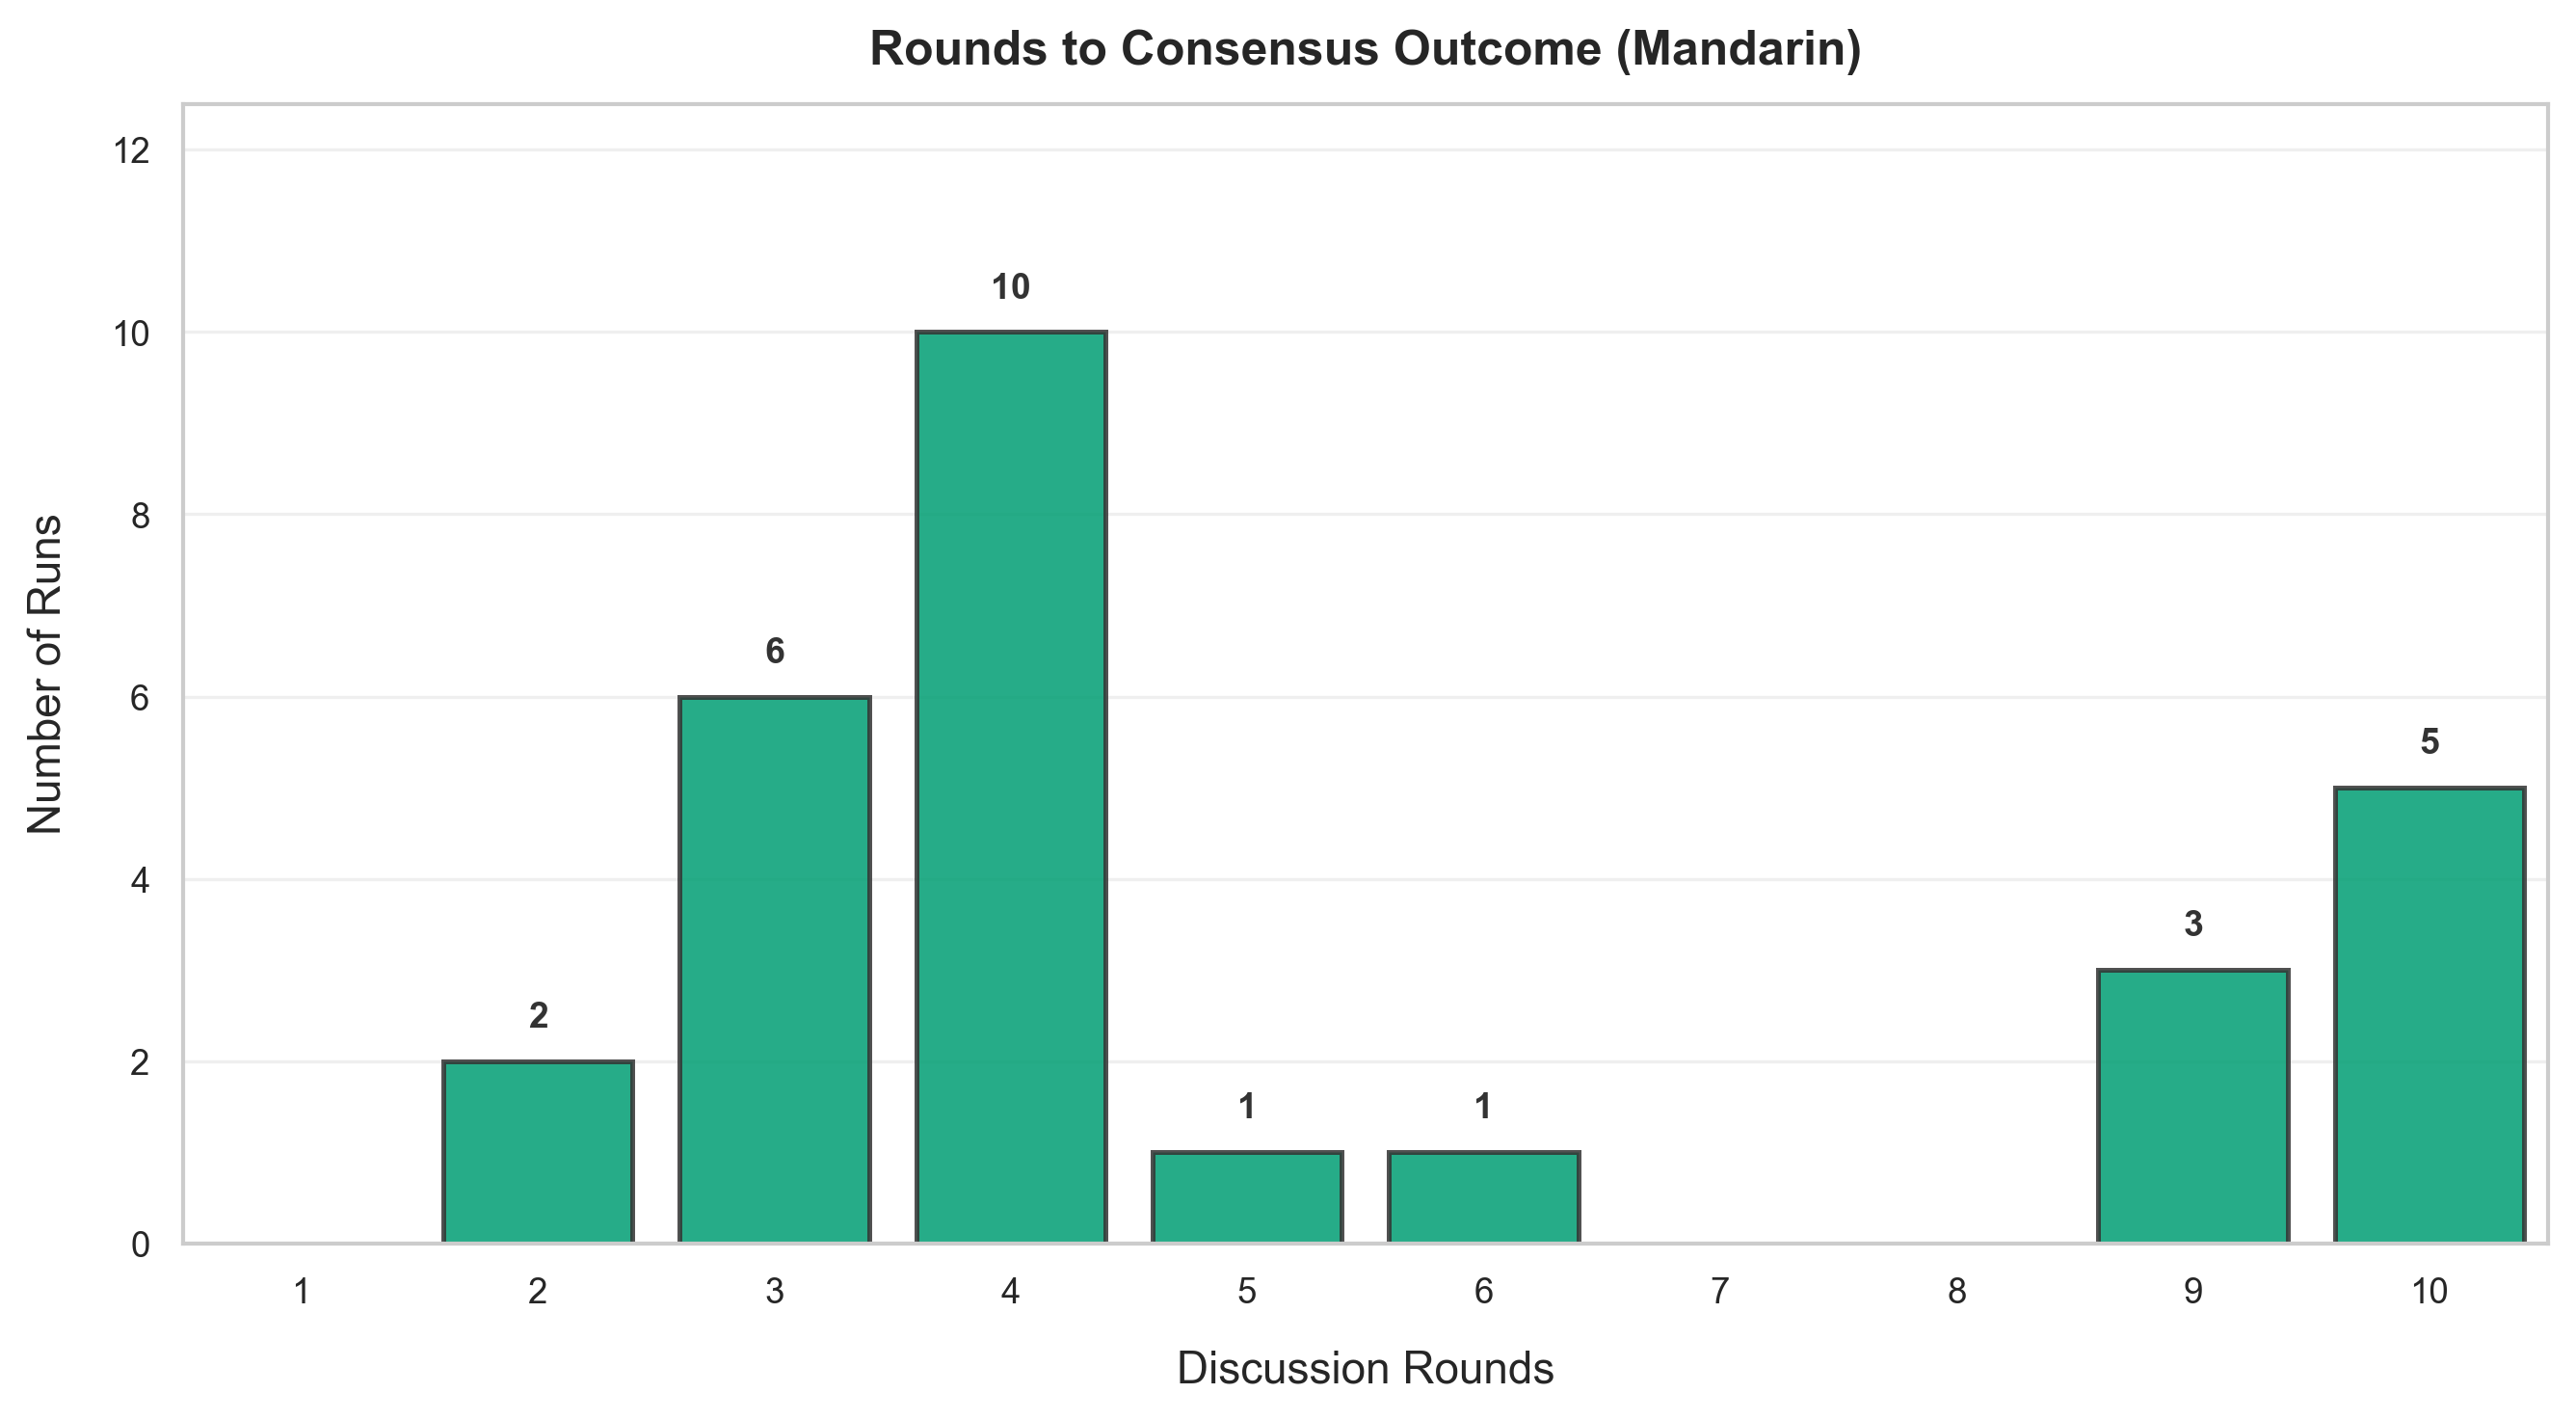

Consensus Timing Summary:
  Total consensus runs: 28
  Range: 2-10 rounds
  Mean: 5.36 rounds  |  Median: 4 rounds


### Floor Constraint Amounts

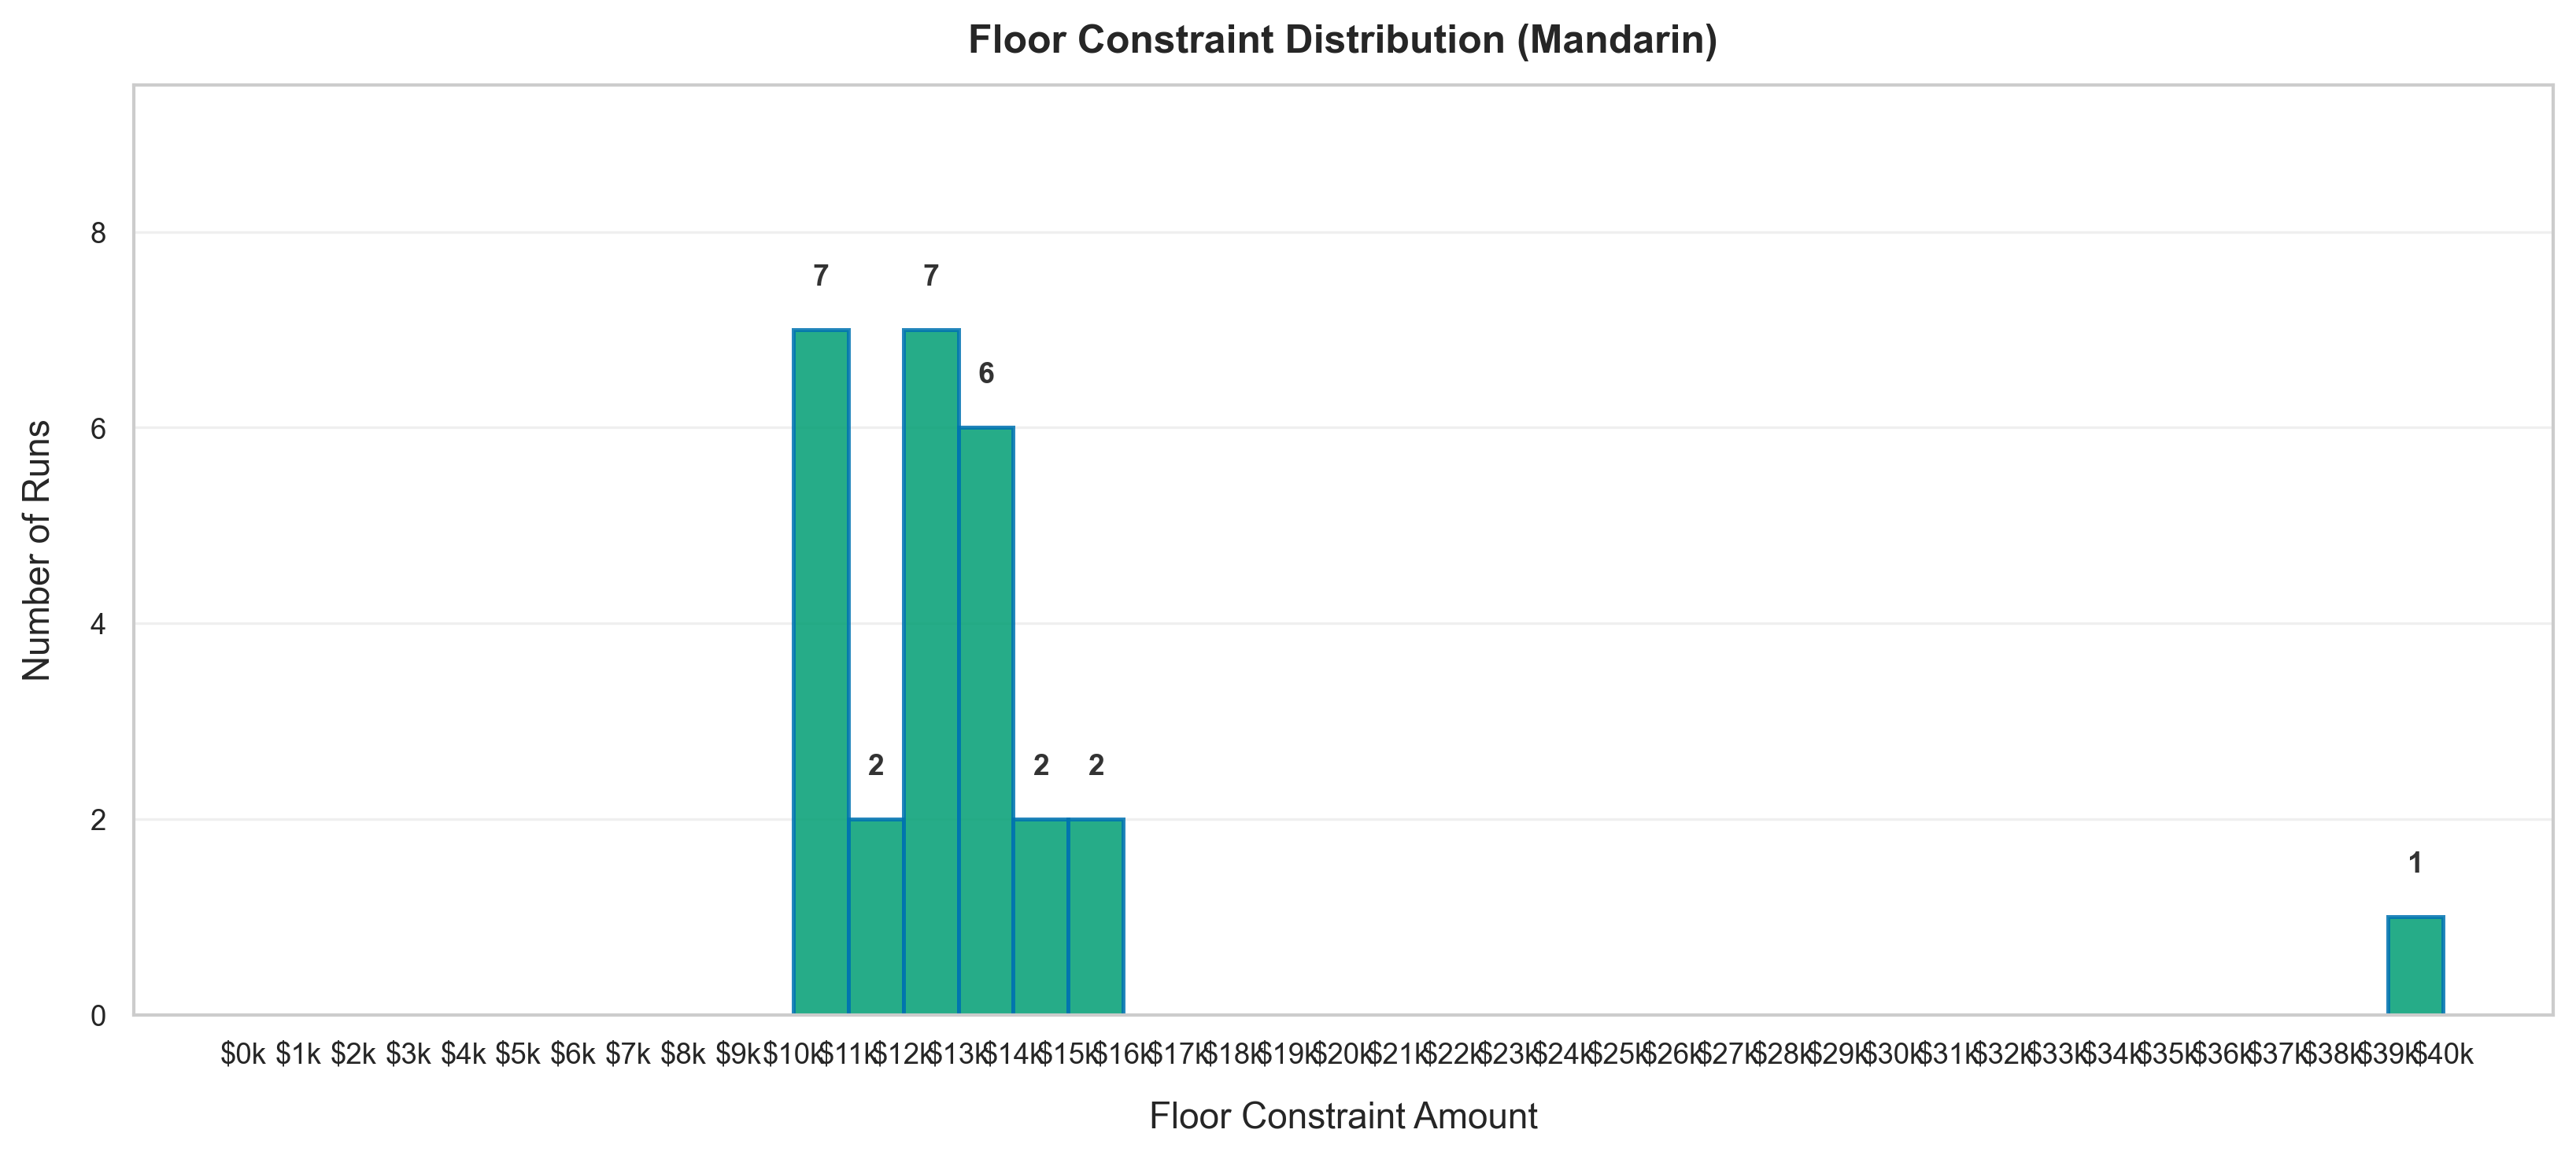

Floor Amount Summary:
  Total votes: 27
  Range: $10,000 - $40,000
  Mean: $13,074  |  Median: $12,000  |  SD: $5,495


### Voting Attempts and Success Rate

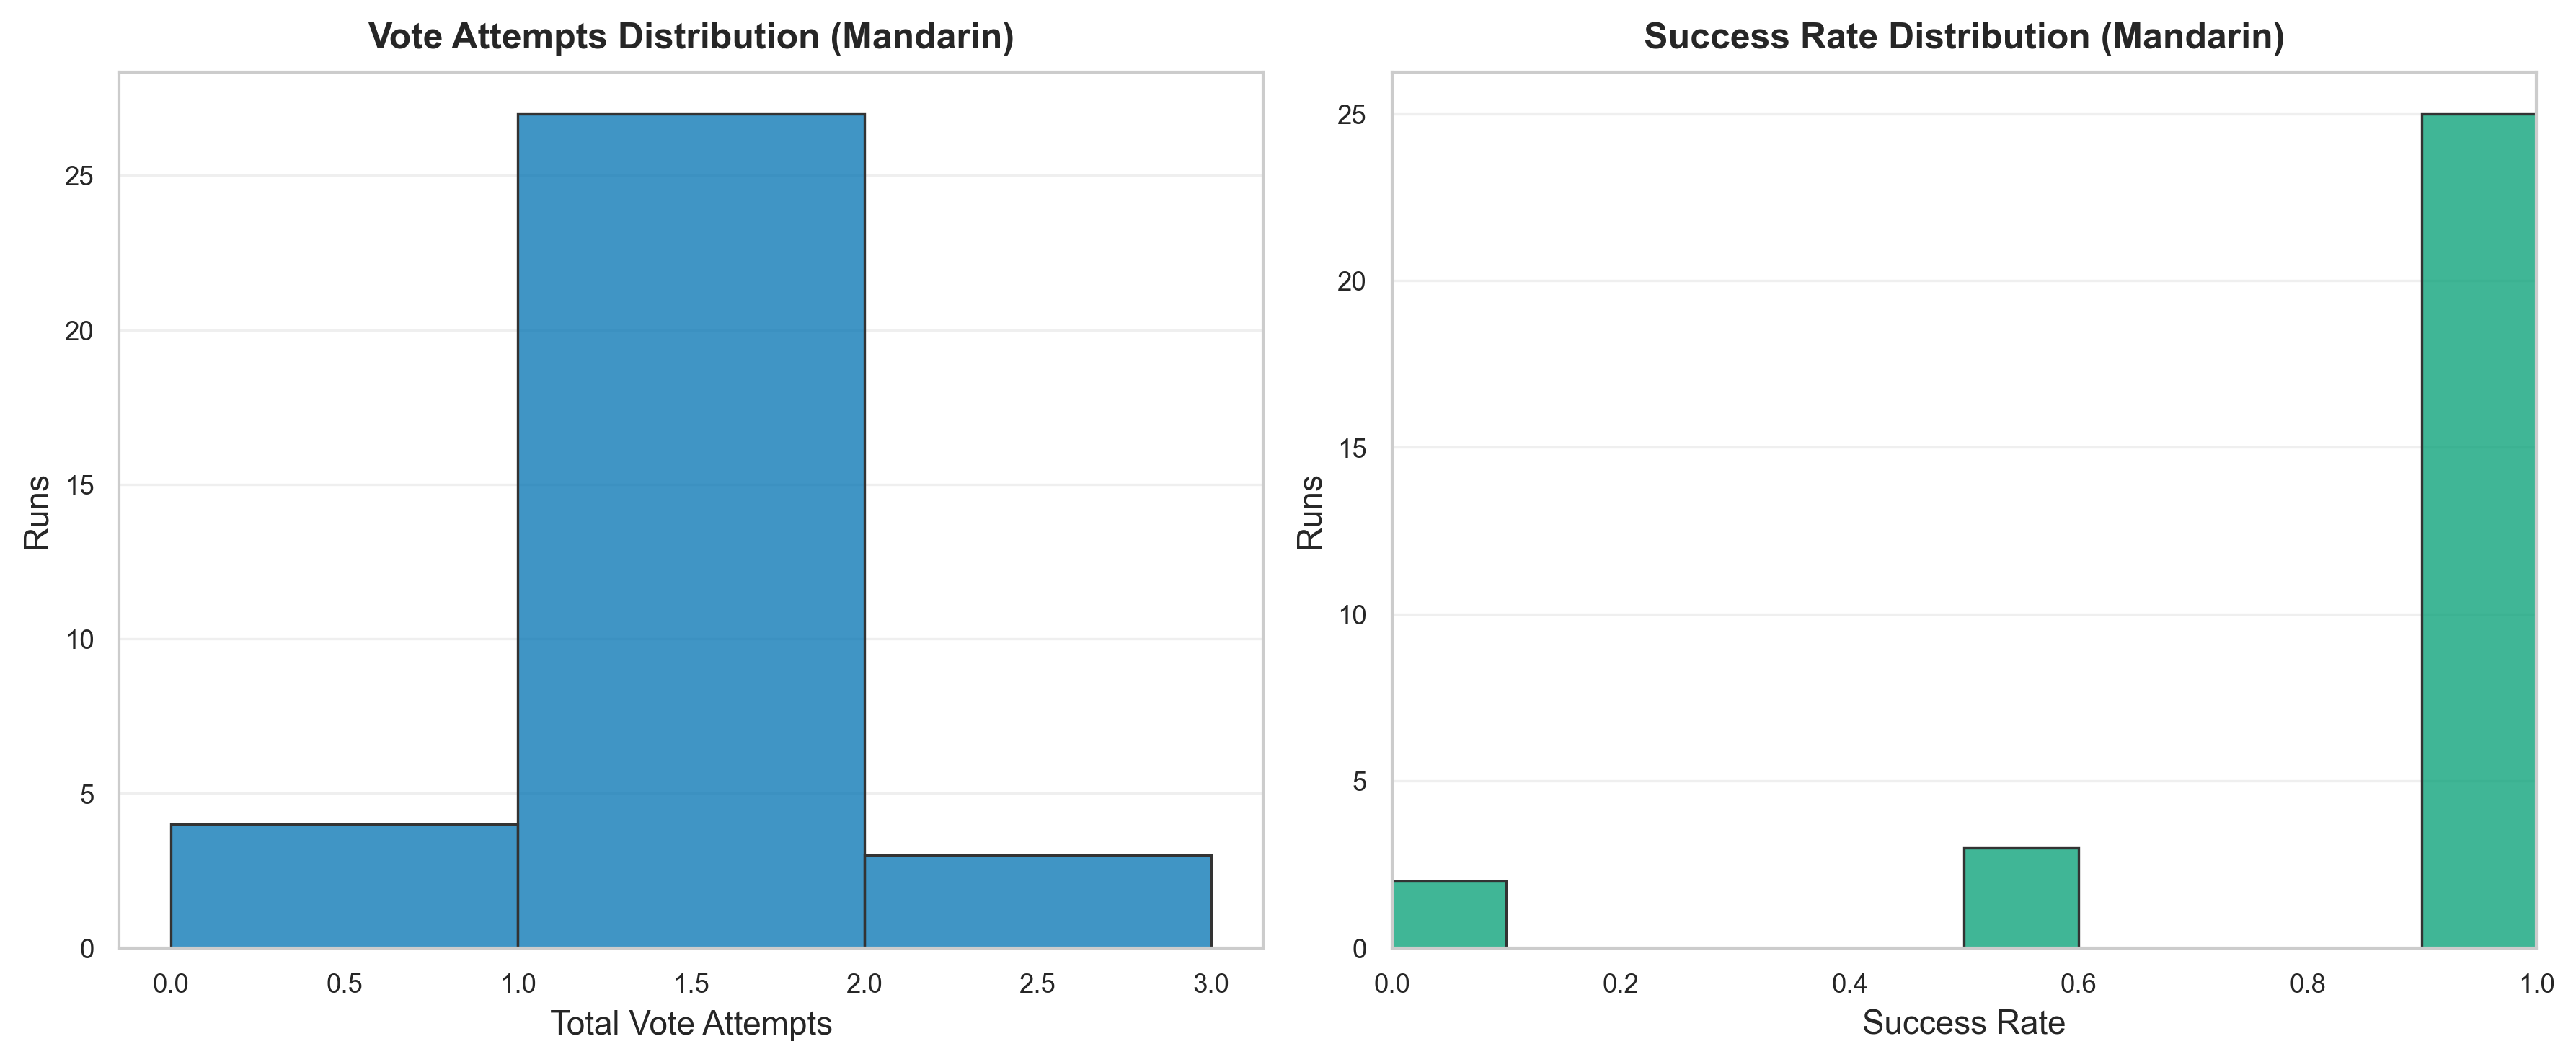

Voting Attempts Summary:
  Mean attempts per run: 0.97
  Median attempts per run: 1
  Mean success rate: 88.33%
  Median success rate: 100.00%


### Preference Evolution and Transitions

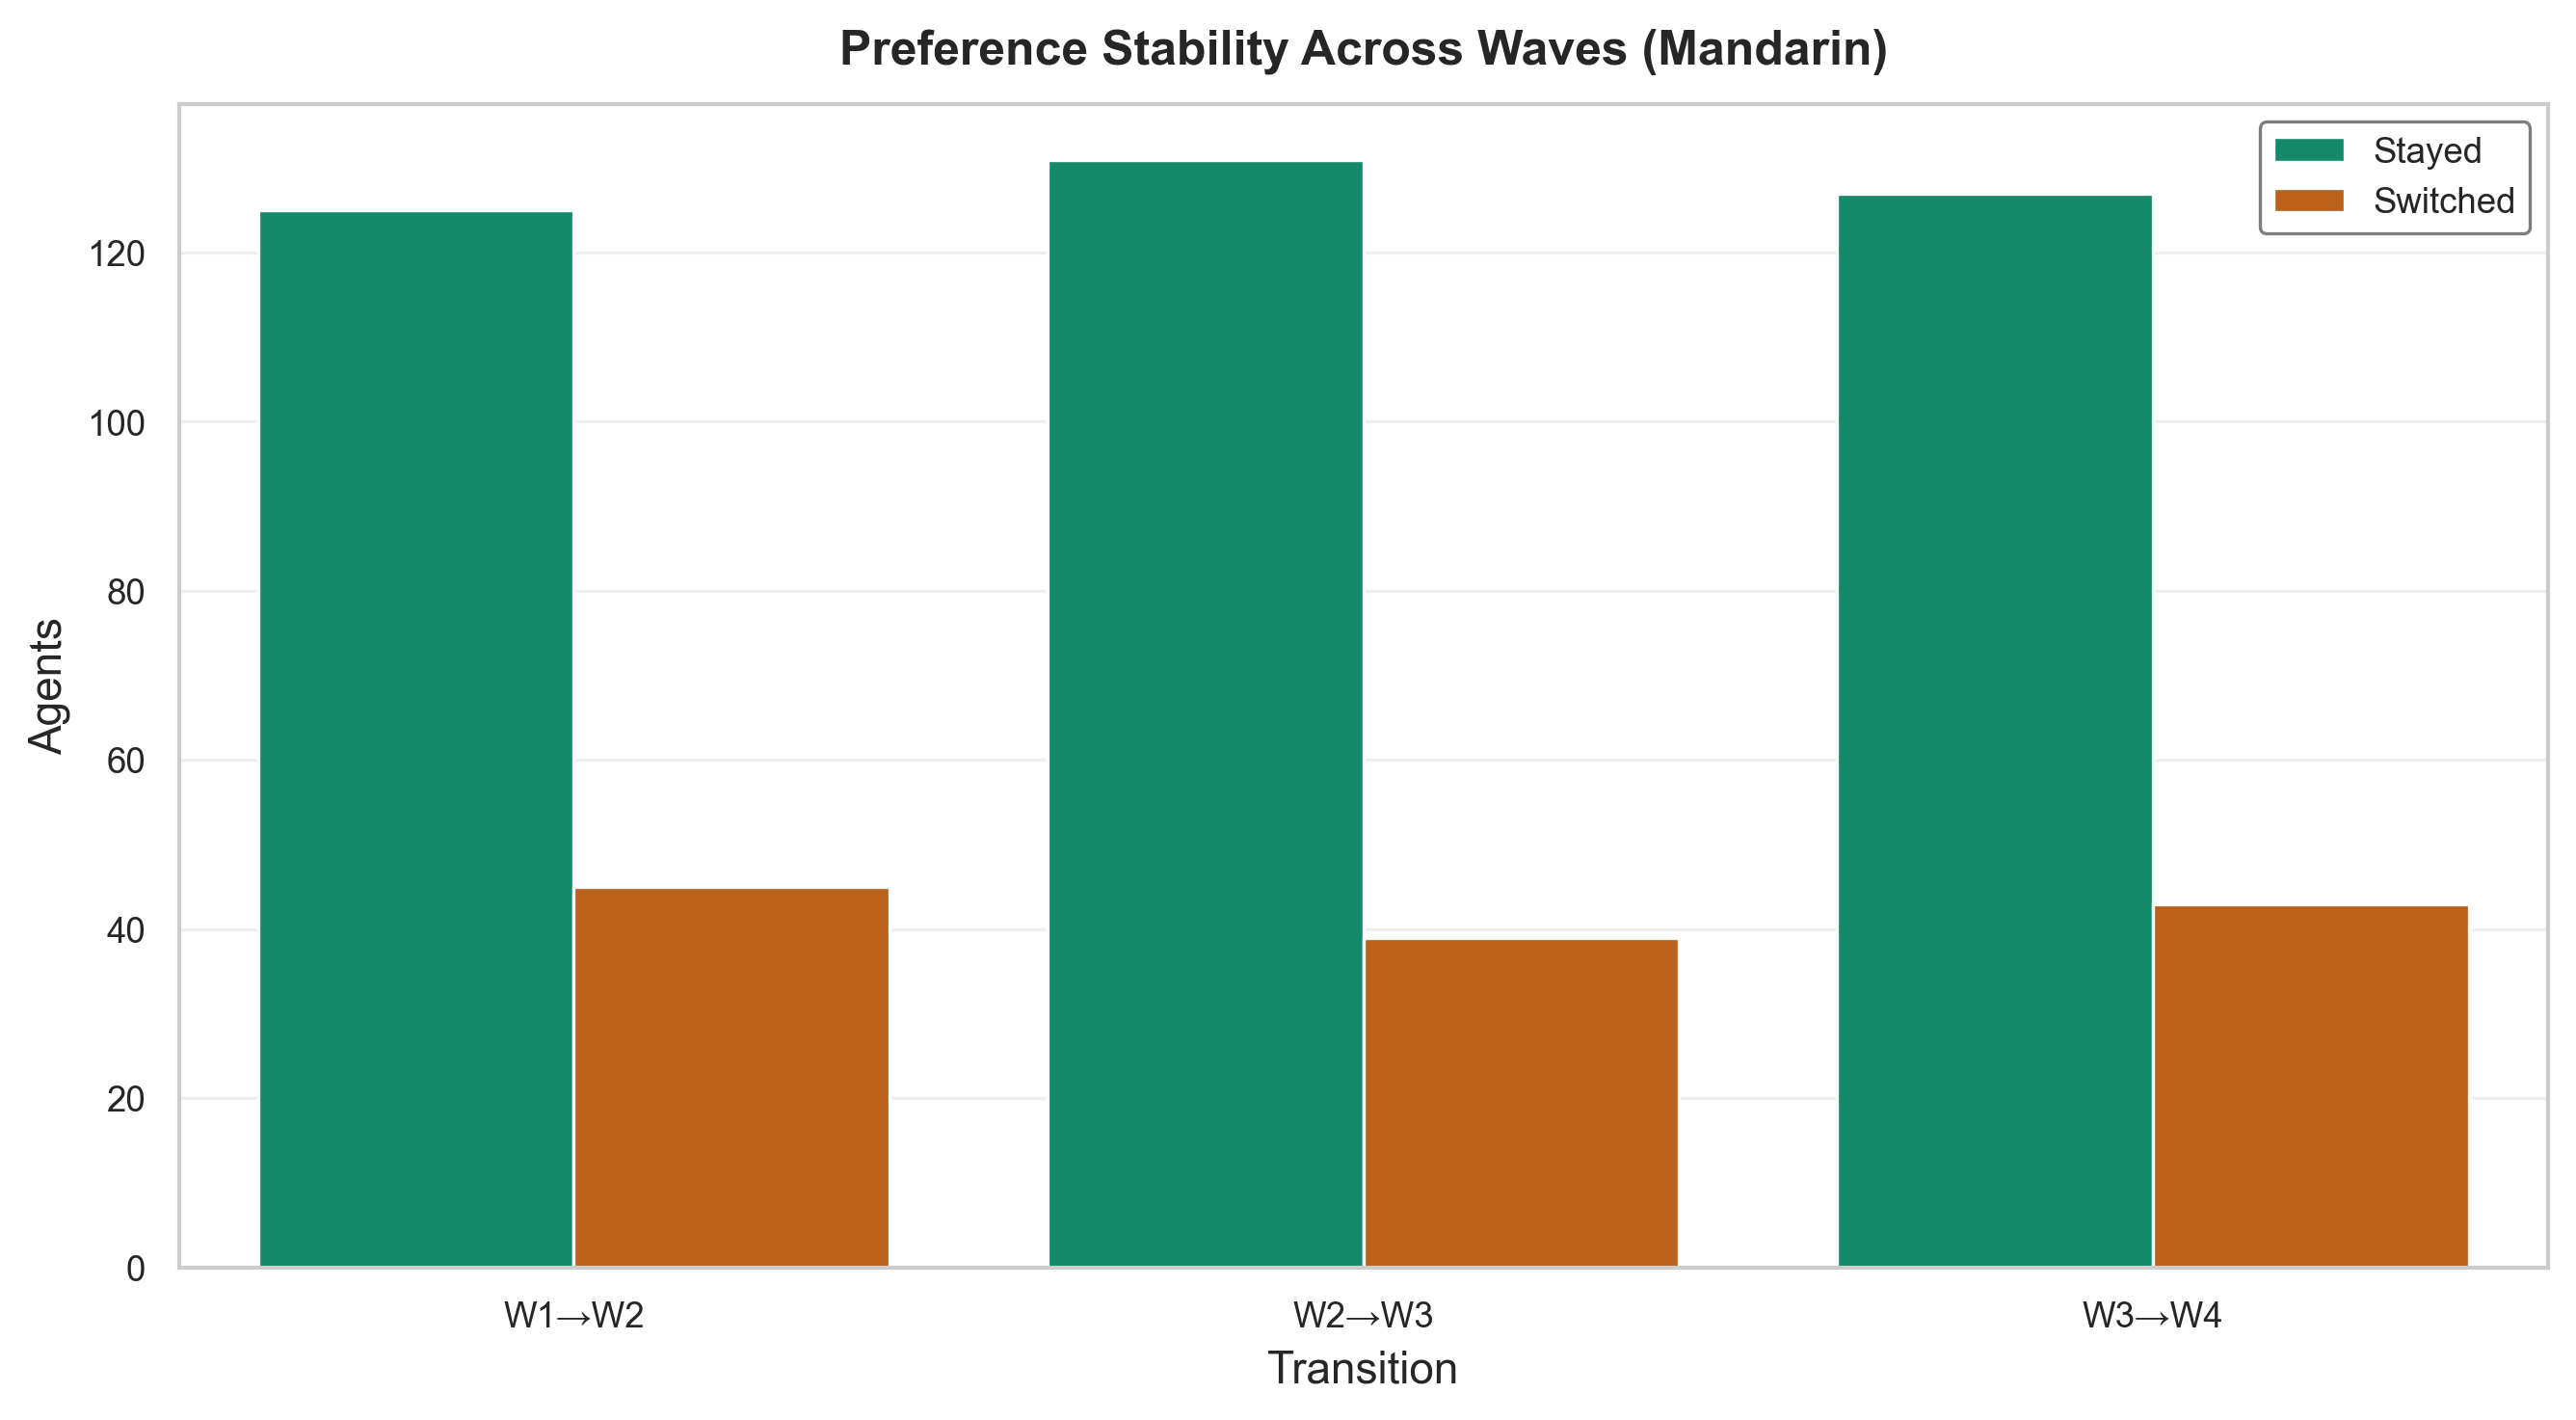

Stability Breakdown:
  W1→W2: 125/170 stayed (73.5%)
  W2→W3: 131/170 stayed (77.1%)
  W3→W4: 127/170 stayed (74.7%)


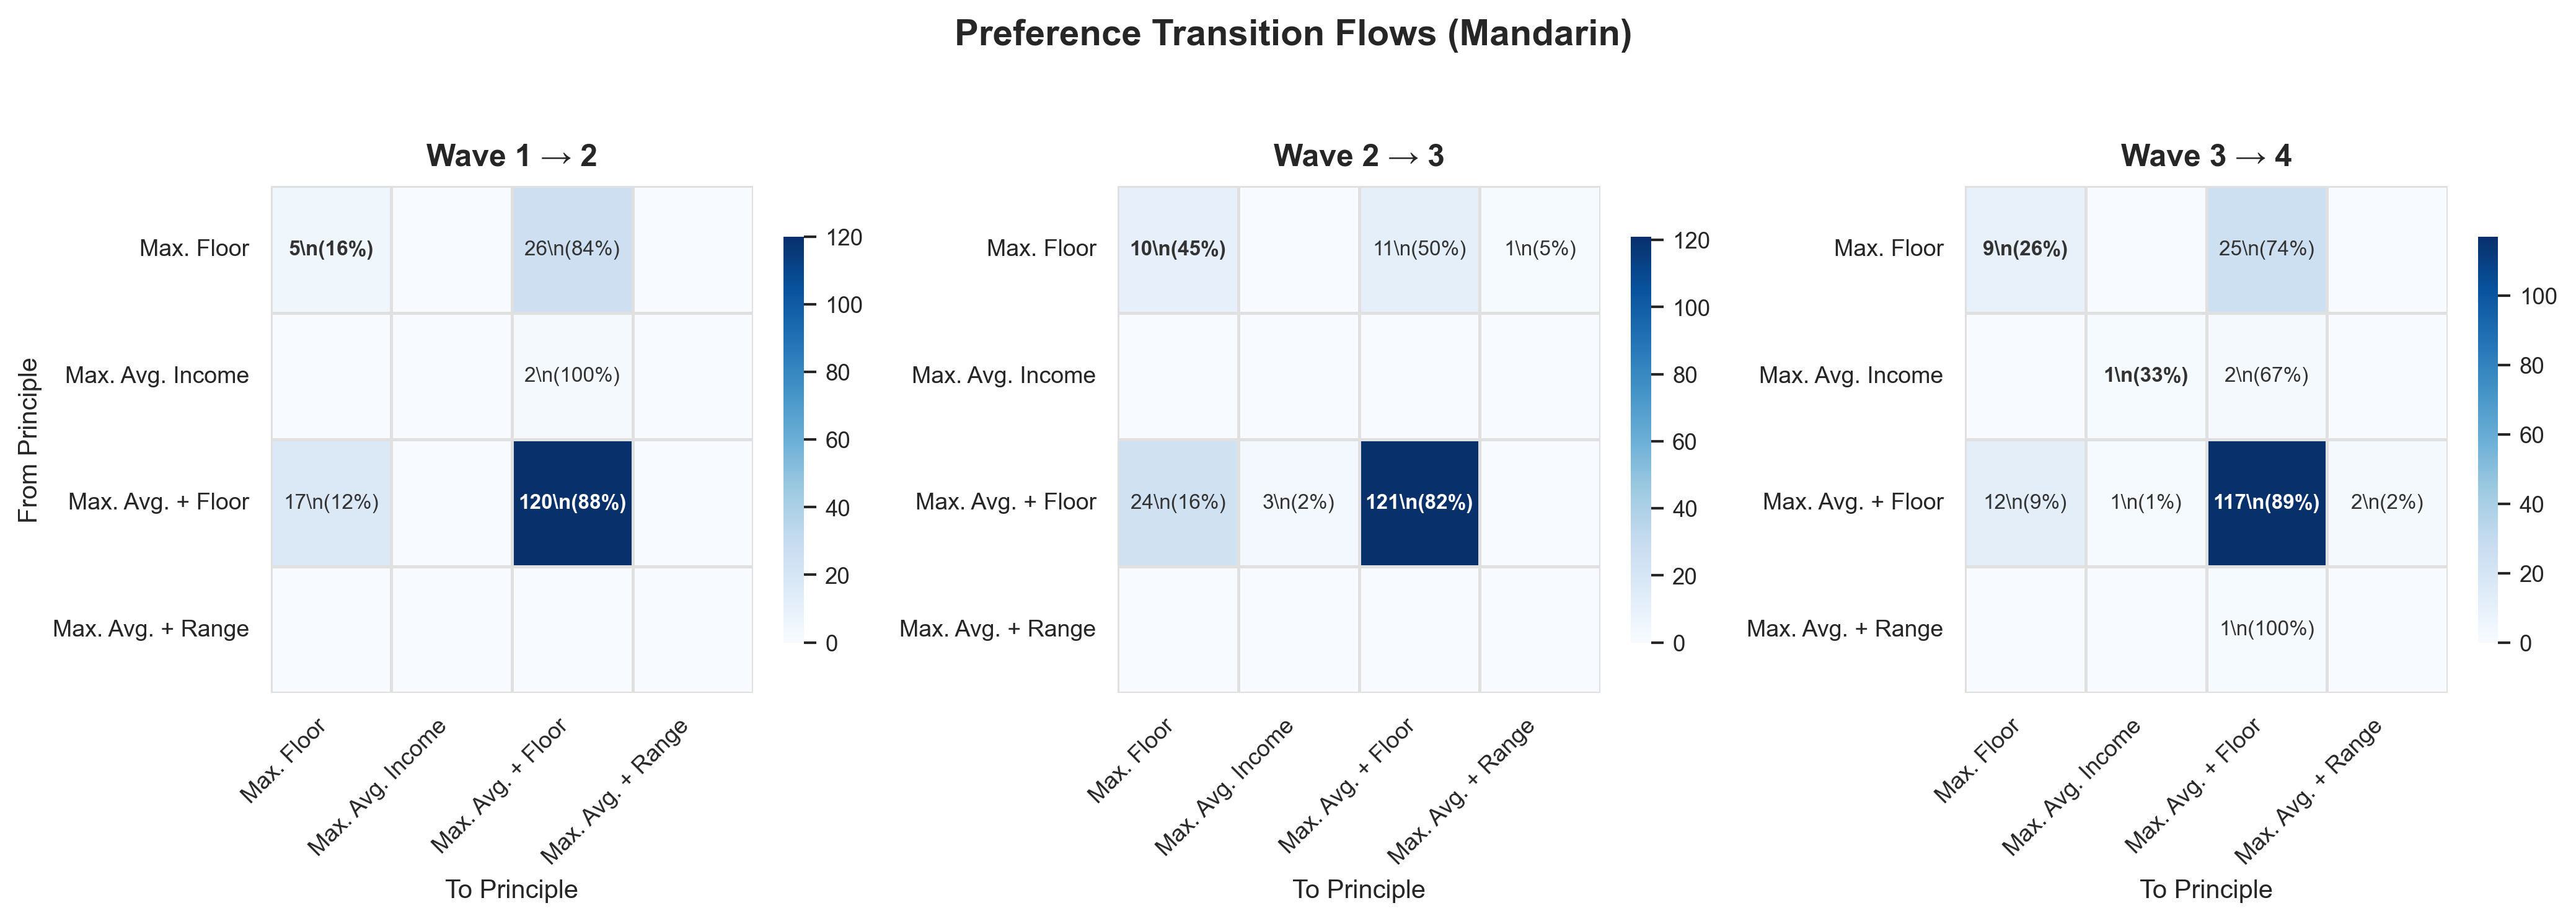

Transition Stay Rates:
  Wave 1 → 2: 125/170 stayed (73.5%)
  Wave 2 → 3: 131/170 stayed (77.1%)
  Wave 3 → 4: 127/170 stayed (74.7%)


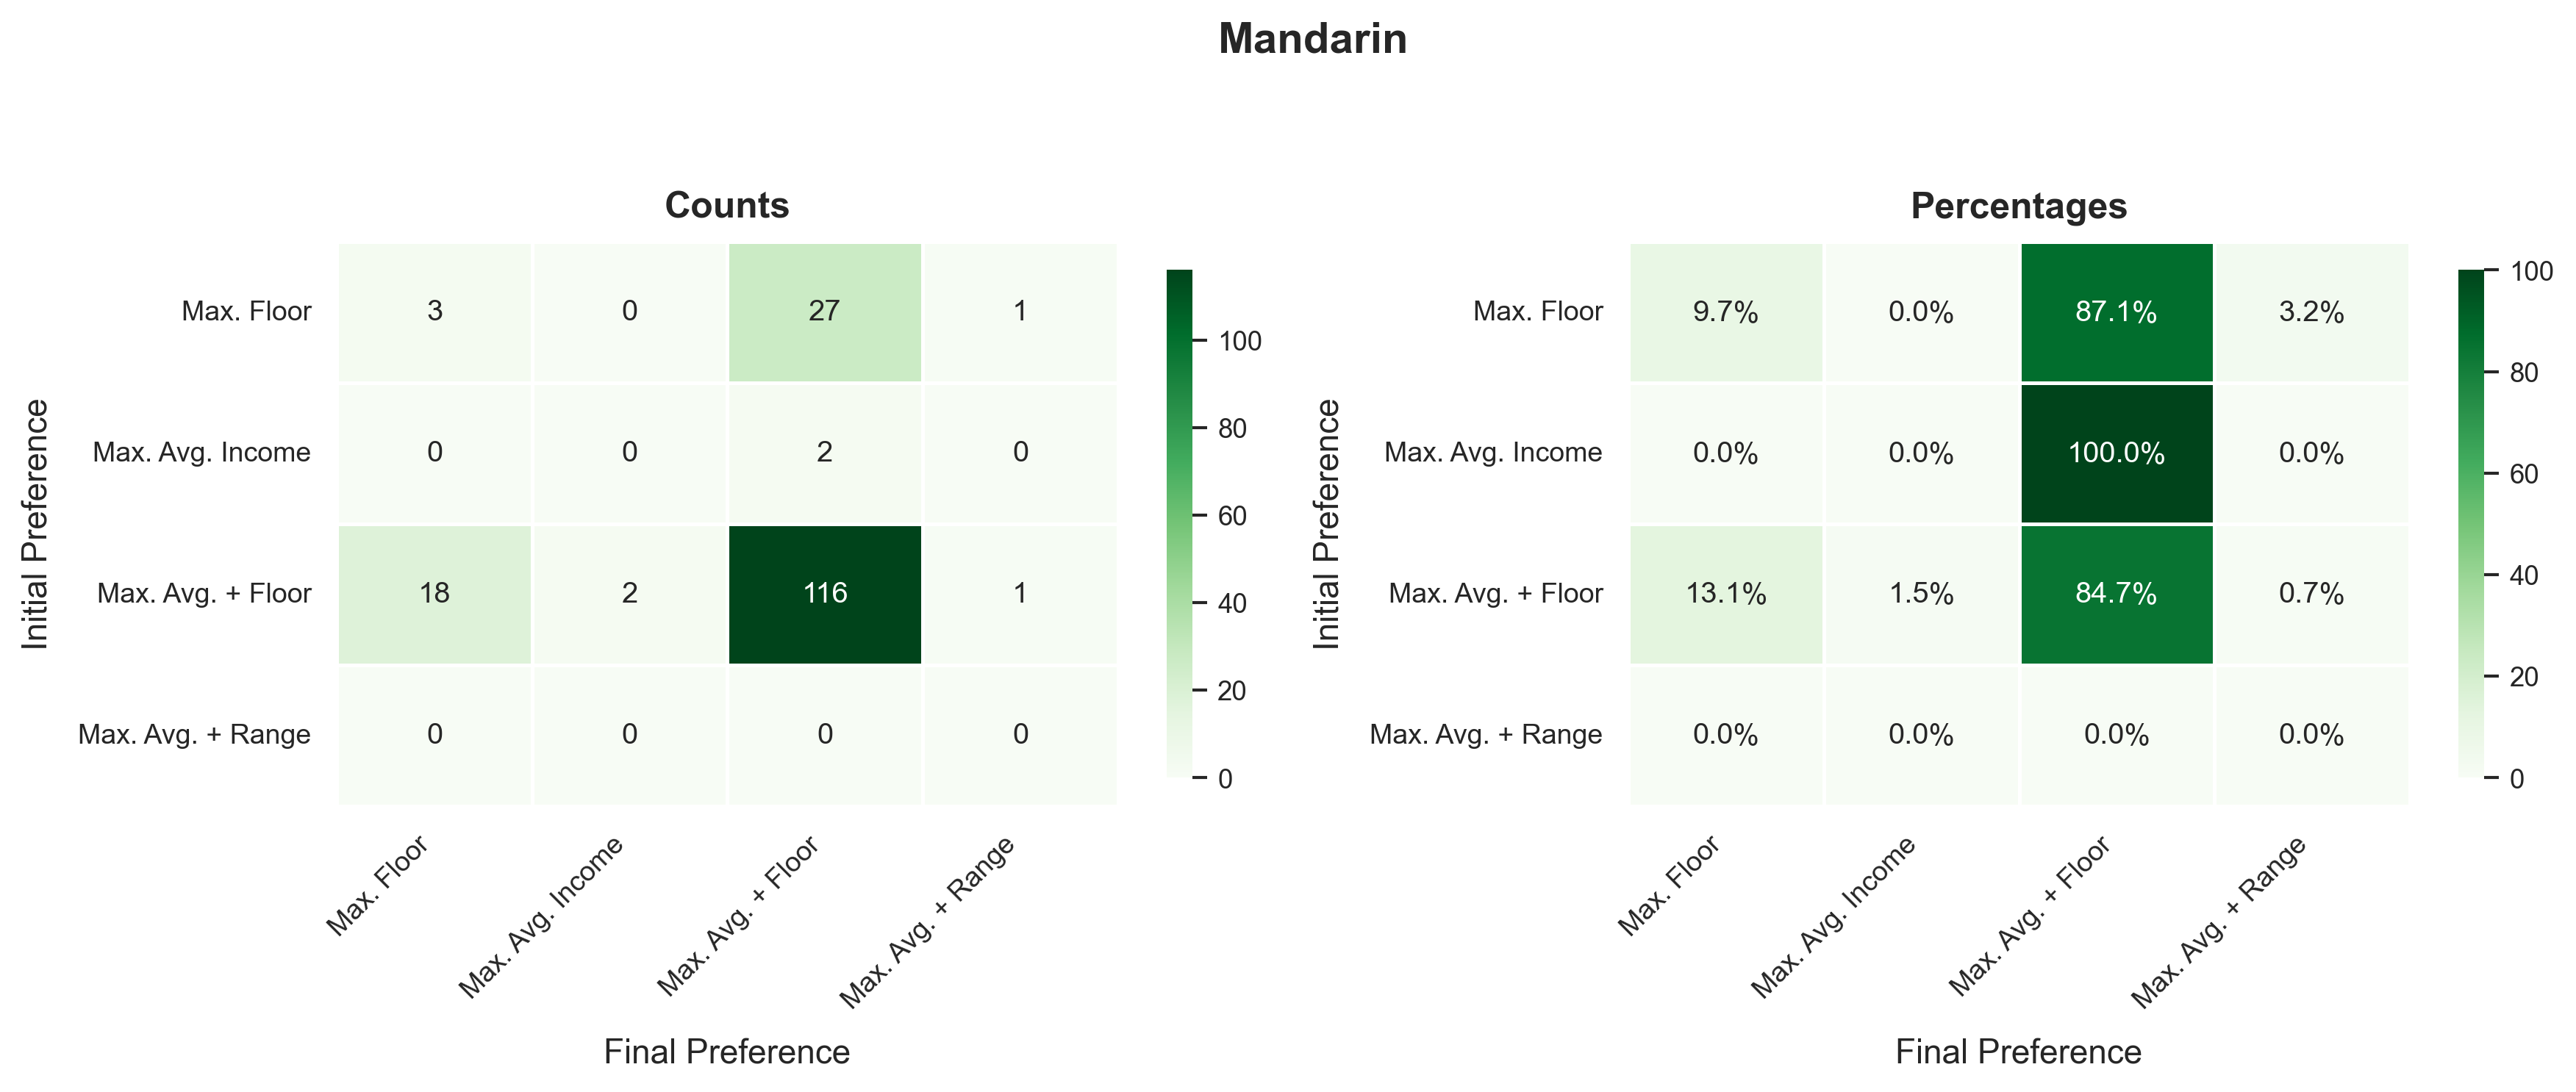

Long-Term Stability (Wave 1 → Wave 4) [Mandarin]
Max. Floor               :   3/ 31 maintained (  9.7%)
Max. Avg. Income         :   0/  2 maintained (  0.0%)
Max. Avg. + Floor        : 116/137 maintained ( 84.7%)
Max. Avg. + Range        :   0/  0 maintained (  0.0%)
OVERALL                  : 119/170 agents ( 70.0%)


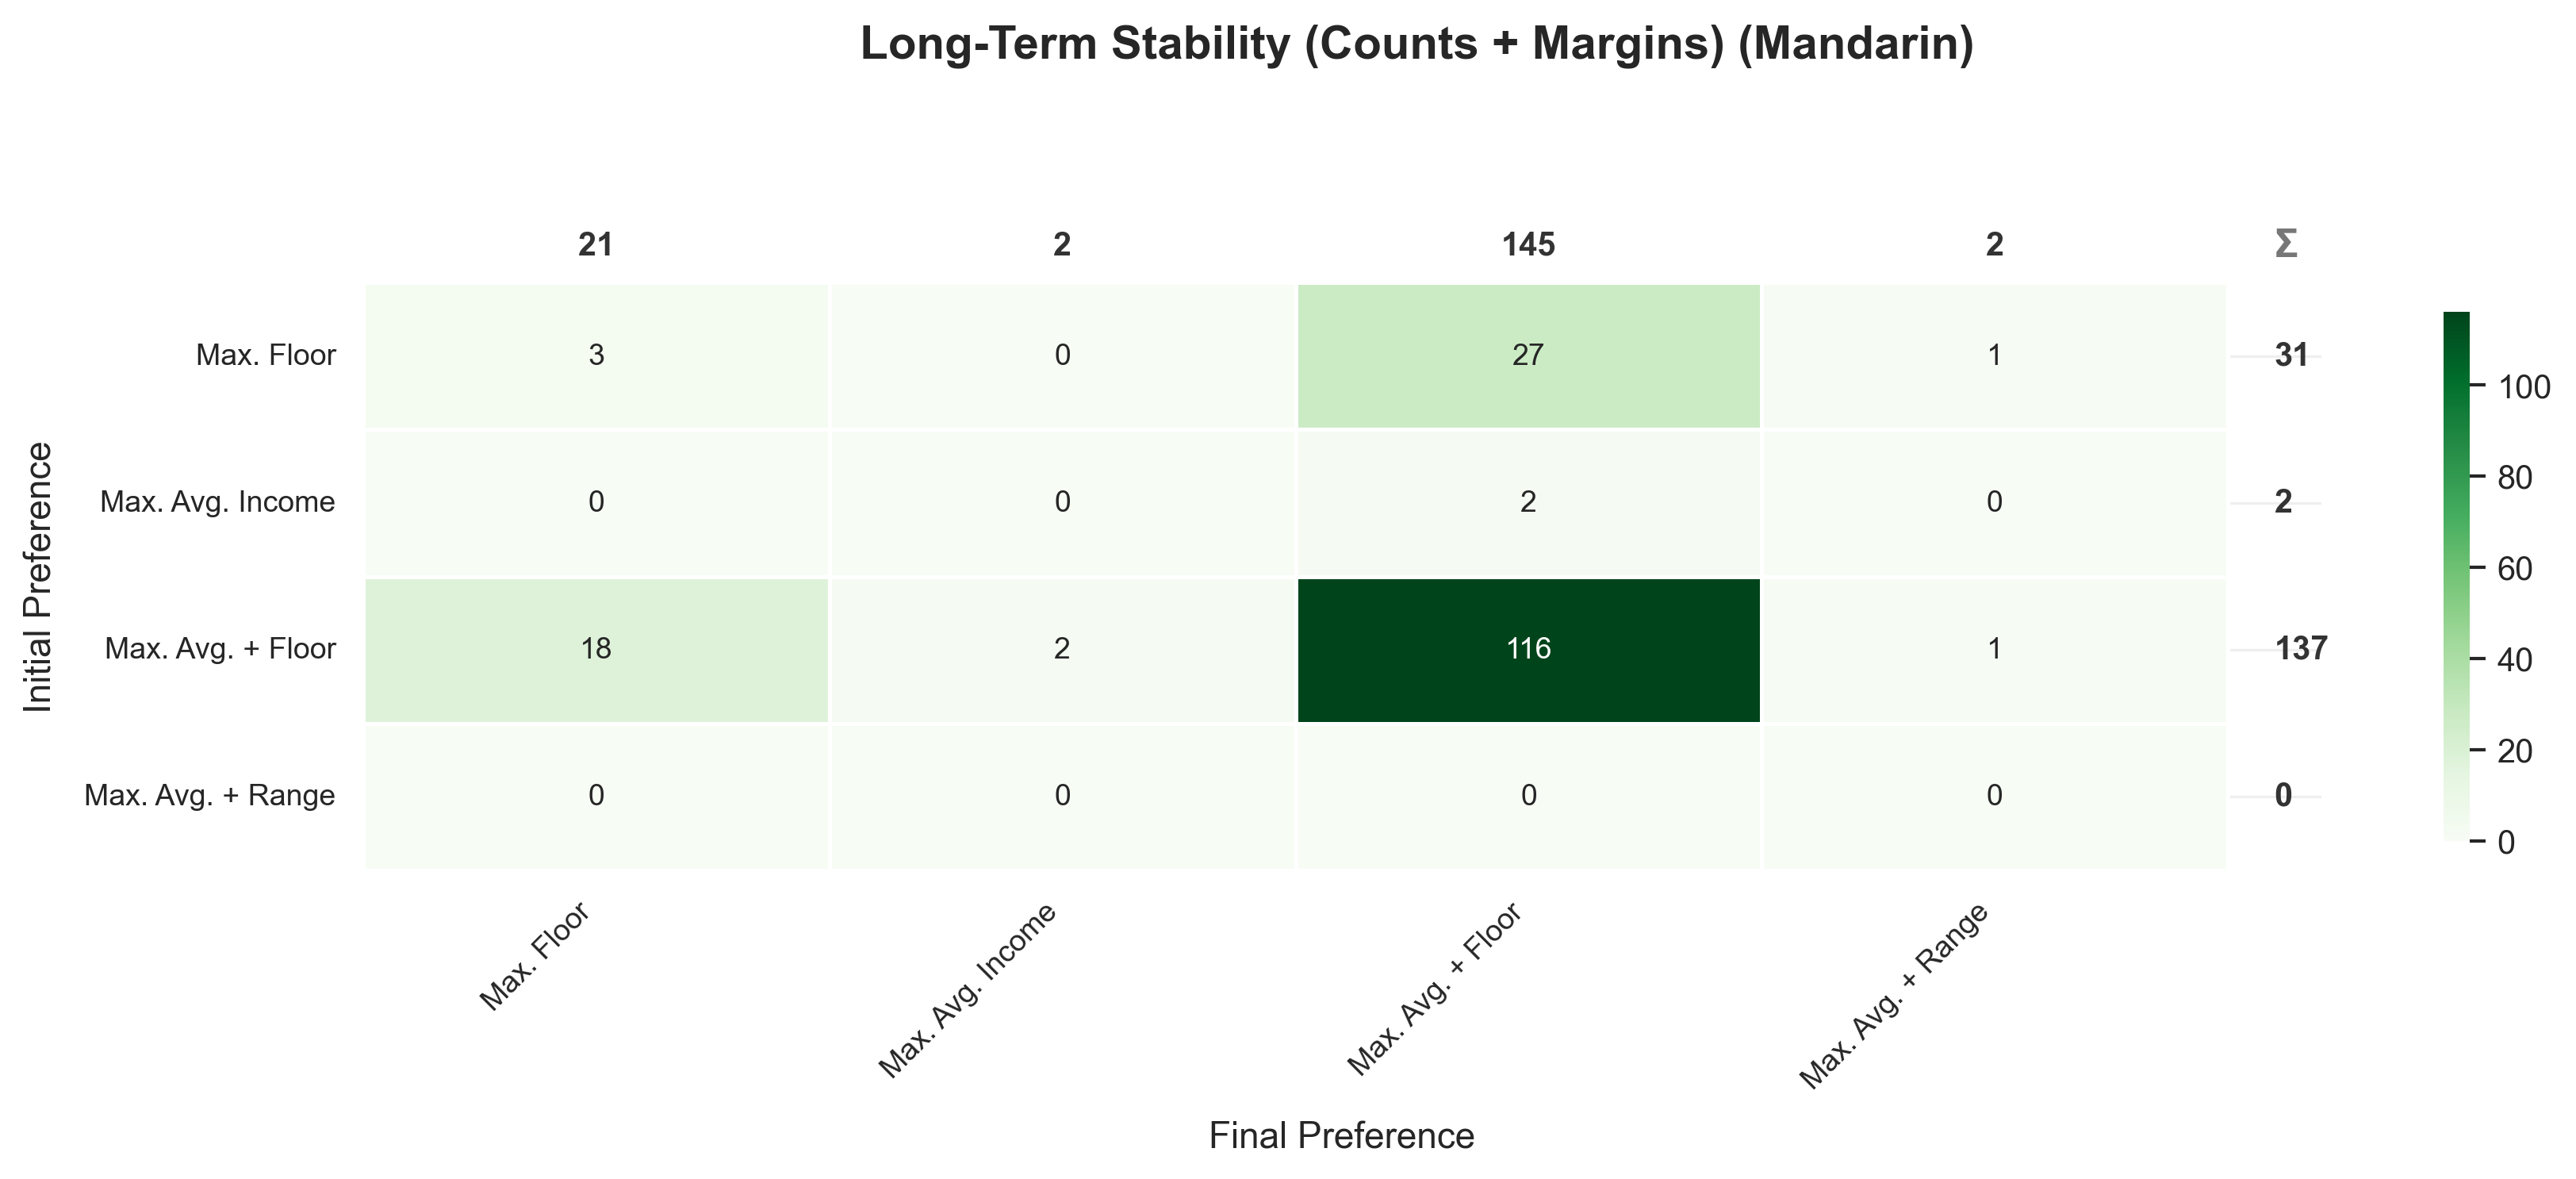

### Switcher Analysis: Income Class and Preference Changes

,Income Class,Changed Preference Count,Changed Preference %,Maintained Preference Count,Maintained Preference %,Diff Changed vs Maintained (pp)
0,Low,10,11.9,11,12.8,-0.9
1,Medium-Low,25,29.8,16,18.6,11.2
2,Medium,37,44.0,48,55.8,-11.8
3,Medium-High,7,8.3,8,9.3,-1.0
4,High,5,6.0,3,3.5,2.5


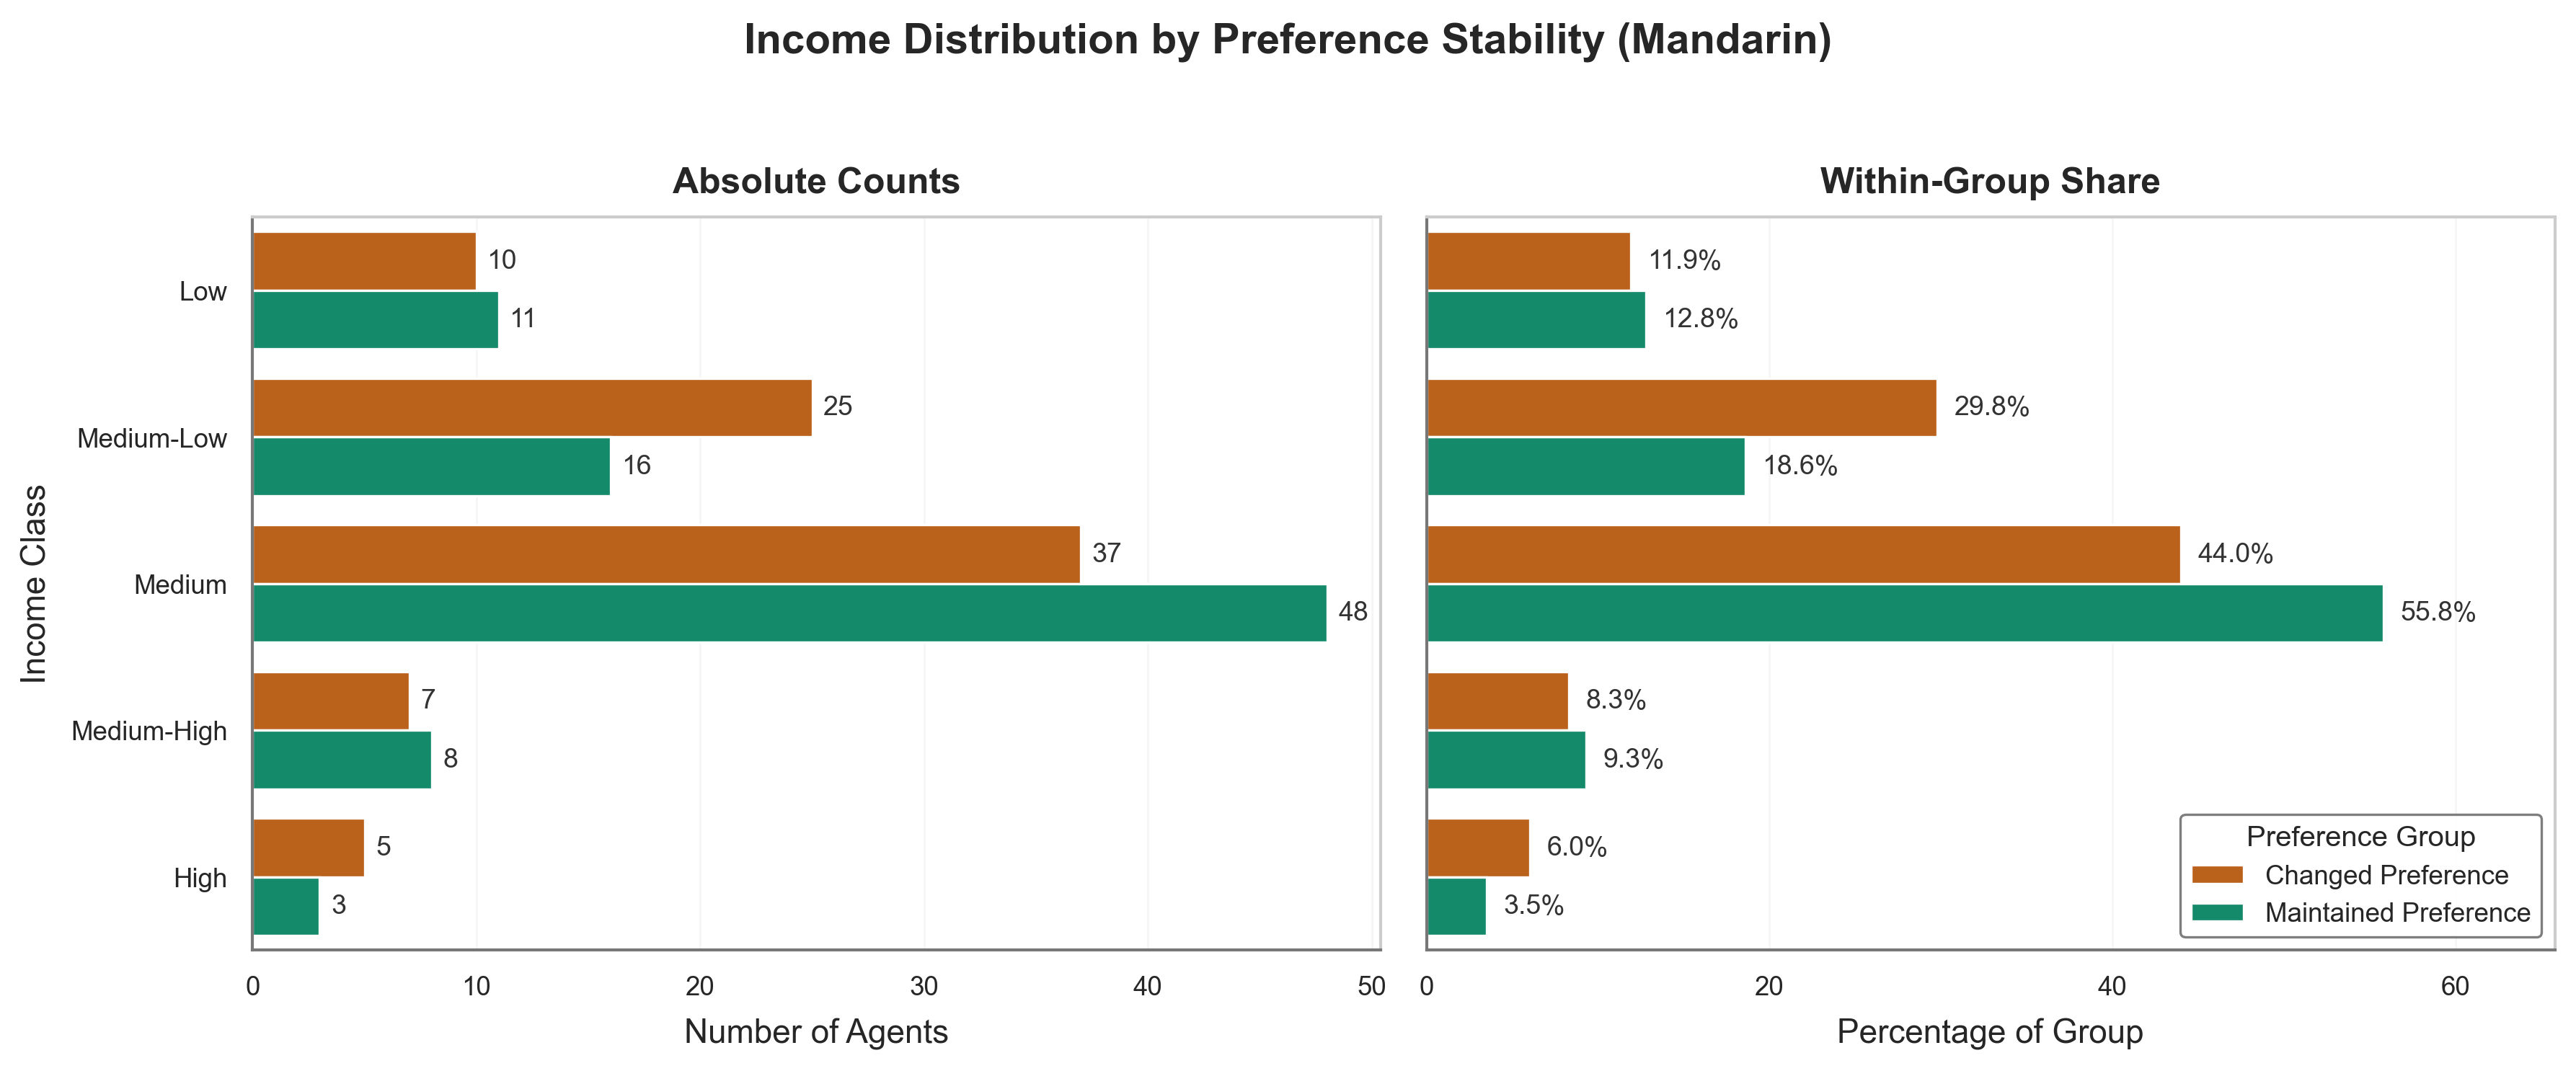

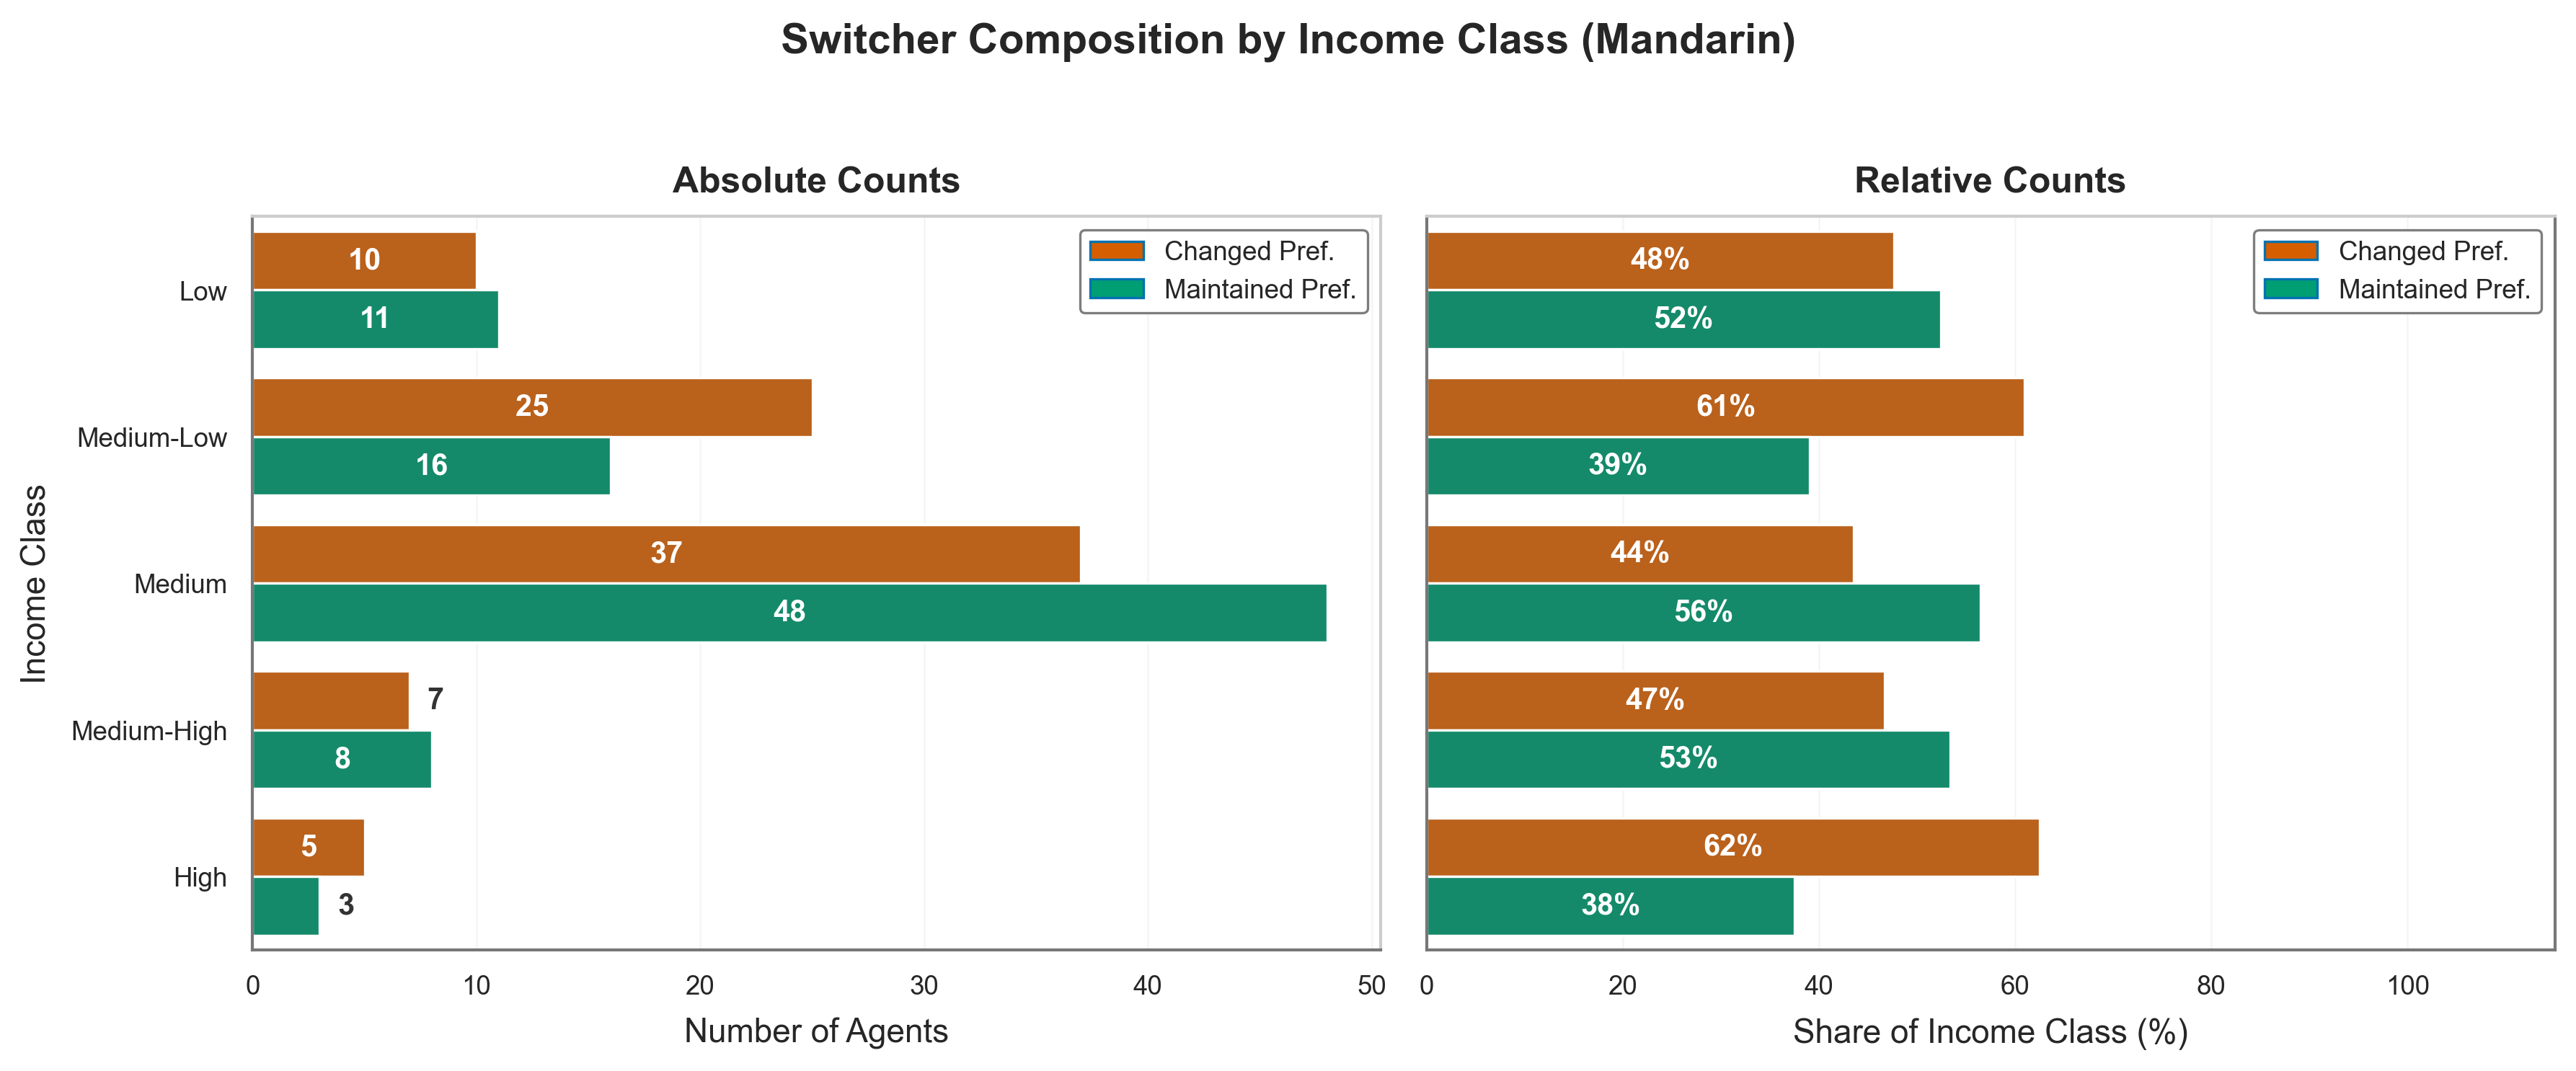

In [21]:
# Run full descriptive workflow per cohort

for label, dataset in group_datasets.items():
    display(Markdown(f"## {label} Cohort"))

    # Data summary
    display(Markdown("### Data Summary"))
    num_runs = dataset.run_metrics.shape[0]
    consensus_runs = dataset.run_metrics[dataset.run_metrics["consensus_reached"] == True].shape[0]
    unique_agents = dataset.ranking_top[["run_id", "agent"]].drop_duplicates().shape[0]
    num_waves = dataset.ranking_top["wave_label"].nunique()
    summary_df = pd.DataFrame(
        {
            "Metric": ["Runs", "Consensus runs", "Agent sessions", "Preference waves"],
            "Value": [num_runs, consensus_runs, unique_agents, num_waves],
        }
    )
    display(summary_df)
    
    # Compute transition coverage directly
    if dataset.transition_data is not None and not dataset.transition_data.empty:
        complete = len(dataset.transition_data)
        print(f"Transition coverage: {complete}/{unique_agents} agents with full wave data")

    # Preference orderings
    display(Markdown("### Preference Orderings by Wave"))
    for wave_name in WAVE_ORDER:
        display(Markdown(f"**{wave_name}**"))
        table = create_preference_ordering_table(dataset.ranking_long, wave_name)
        display(table)

    # Rounds to outcome
    display(Markdown("### Rounds to Outcome"))
    plot_rounds_to_outcome(
        dataset.run_metrics,
        title_suffix=label,
    )

    # Floor constraints
    display(Markdown("### Floor Constraint Amounts"))
    plot_floor_constraint_distribution(
        dataset.vote_rounds,
        title_suffix=label,
    )

    # Voting attempts
    display(Markdown("### Voting Attempts and Success Rate"))
    plot_voting_attempts_summary(
        dataset.run_metrics,
        title_suffix=label,
    )

    # Preference transitions
    display(Markdown("### Preference Evolution and Transitions"))
    plot_preference_stability(
        dataset.transition_data,
        title_suffix=label,
    )
    plot_transition_heatmaps(
        dataset.transition_data,
        principle_display_order=PRINCIPLE_DISPLAY_ORDER,
        format_principle_label=format_principle_label,
        title_suffix=label,
    )
    plot_long_term_stability(
        dataset.transition_data,
        principle_order=PRINCIPLE_ORDER,
        principle_display_order=PRINCIPLE_DISPLAY_ORDER,
        format_principle_label=format_principle_label,
        title_suffix=label,
        title=label,
    )
    plot_long_term_margin(
        dataset.transition_data,
        principle_display_order=PRINCIPLE_DISPLAY_ORDER,
        format_principle_label=format_principle_label,
        title_suffix=label,
    )

    # Switcher analysis
    display(Markdown("### Switcher Analysis: Income Class and Preference Changes"))
    if dataset.switcher_analysis is None or dataset.switcher_analysis.empty:
        print("No switcher data available for this cohort.")
    else:
        switcher_summary, count_long, share_long, composition_percent_long = summarize_income_preferences(dataset.switcher_analysis)
        display(switcher_summary)
        plot_income_preference_bars(
            switcher_summary,
            count_long,
            share_long,
            title_suffix=label,
        )
        plot_income_composition(
            count_long,
            composition_percent_long,
            title_suffix=label,
        )


In [22]:

# Cross-cohort comparison of final top choices

final_choice_records: List[Dict[str, Any]] = []
for label, dataset in group_datasets.items():
    if dataset.transition_data is None or dataset.transition_data.empty:
        continue
    final_wave = dataset.transition_data["wave4"].map(format_principle_label)
    counts = final_wave.value_counts()
    total = counts.sum()
    for principle, count in counts.items():
        final_choice_records.append({
            "Cohort": label,
            "Top Principle": principle,
            "Agents": int(count),
            "Share %": round(count / total * 100, 1) if total else np.nan,
        })

final_choice_df = pd.DataFrame(final_choice_records).sort_values(["Top Principle", "Cohort"])

display(Markdown("### Final Wave Top-Choice Distribution"))
display(final_choice_df)


### Final Wave Top-Choice Distribution

,Cohort,Top Principle,Agents,Share %
0,English,Max. Avg. + Floor,155,91.2
8,Mandarin,Max. Avg. + Floor,145,85.3
4,Spanish,Max. Avg. + Floor,116,68.2
2,English,Max. Avg. + Range,3,1.8
10,Mandarin,Max. Avg. + Range,2,1.2
5,Spanish,Max. Avg. + Range,38,22.4
3,English,Max. Avg. Income,3,1.8
11,Mandarin,Max. Avg. Income,2,1.2
7,Spanish,Max. Avg. Income,2,1.2
1,English,Max. Floor,9,5.3


## Direct Comparison

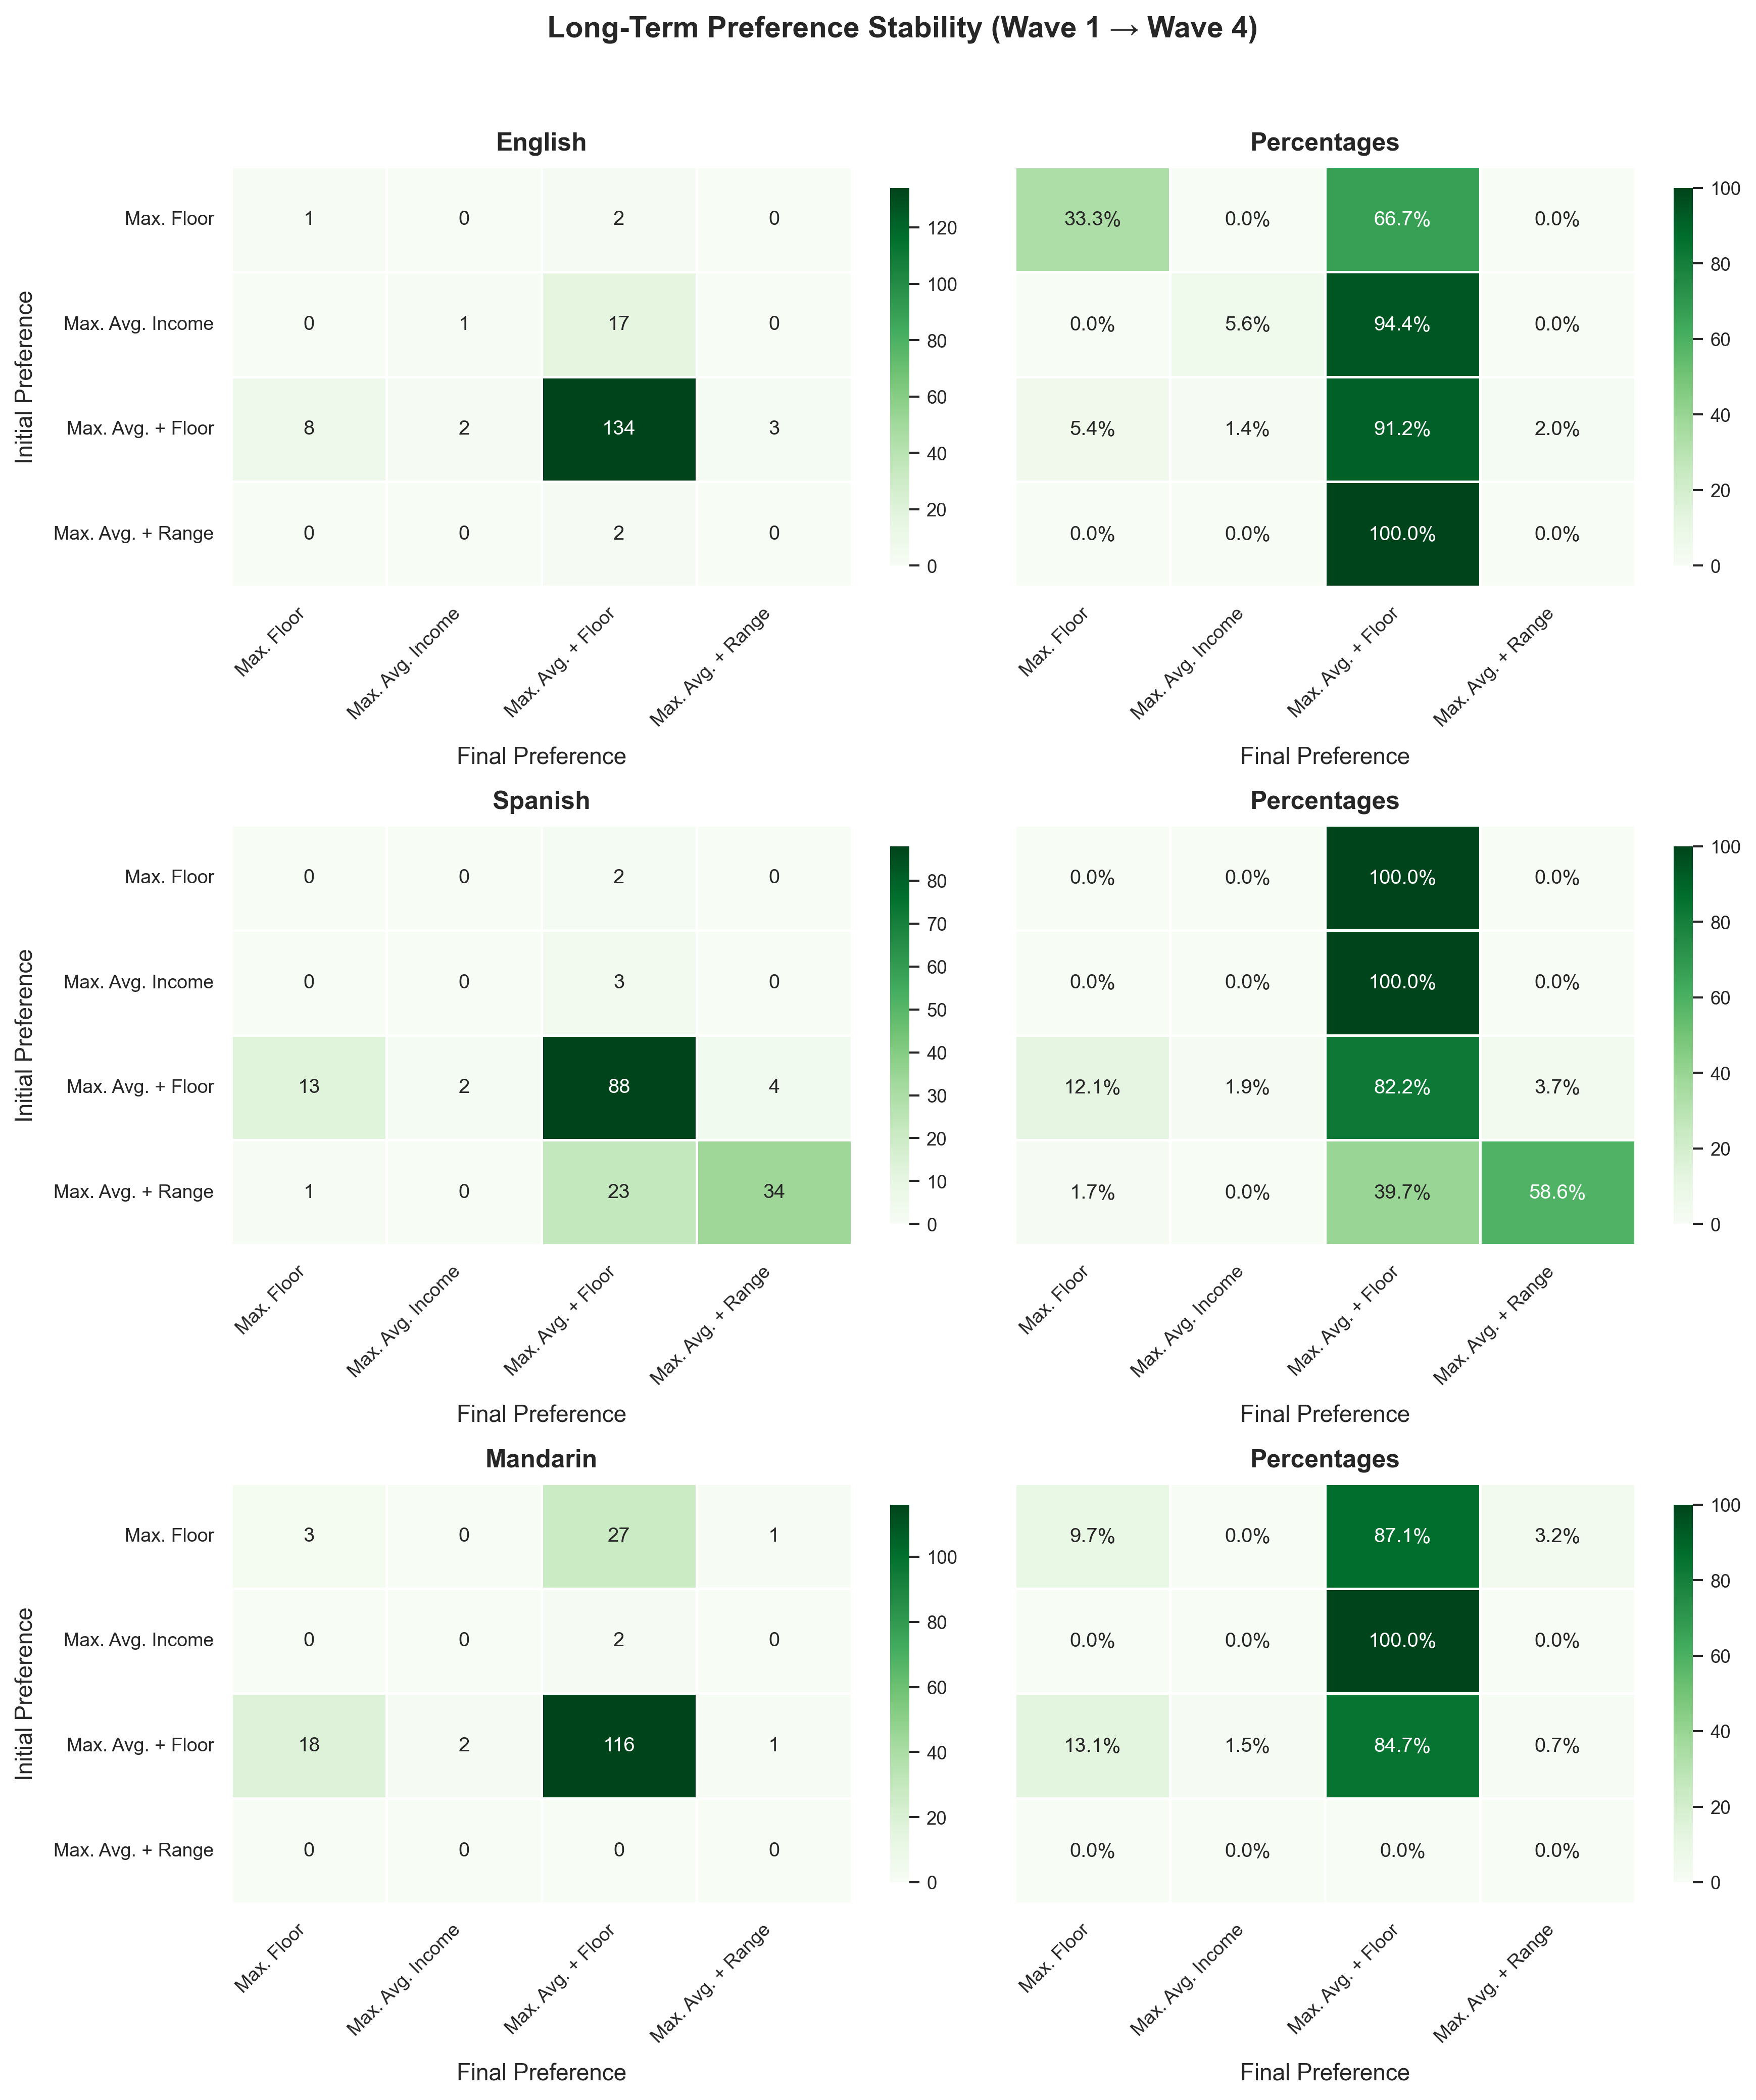

In [23]:
comparison_data = [
    (label, dataset.transition_data)
    for label, dataset in group_datasets.items()
]

plot_long_term_stability_grid(
    comparison_data,
    principle_order=PRINCIPLE_ORDER,
    principle_display_order=PRINCIPLE_DISPLAY_ORDER,
    format_principle_label=format_principle_label,
    title="Long-Term Preference Stability (Wave 1 → Wave 4)",
)


### Counts-Only Comparison

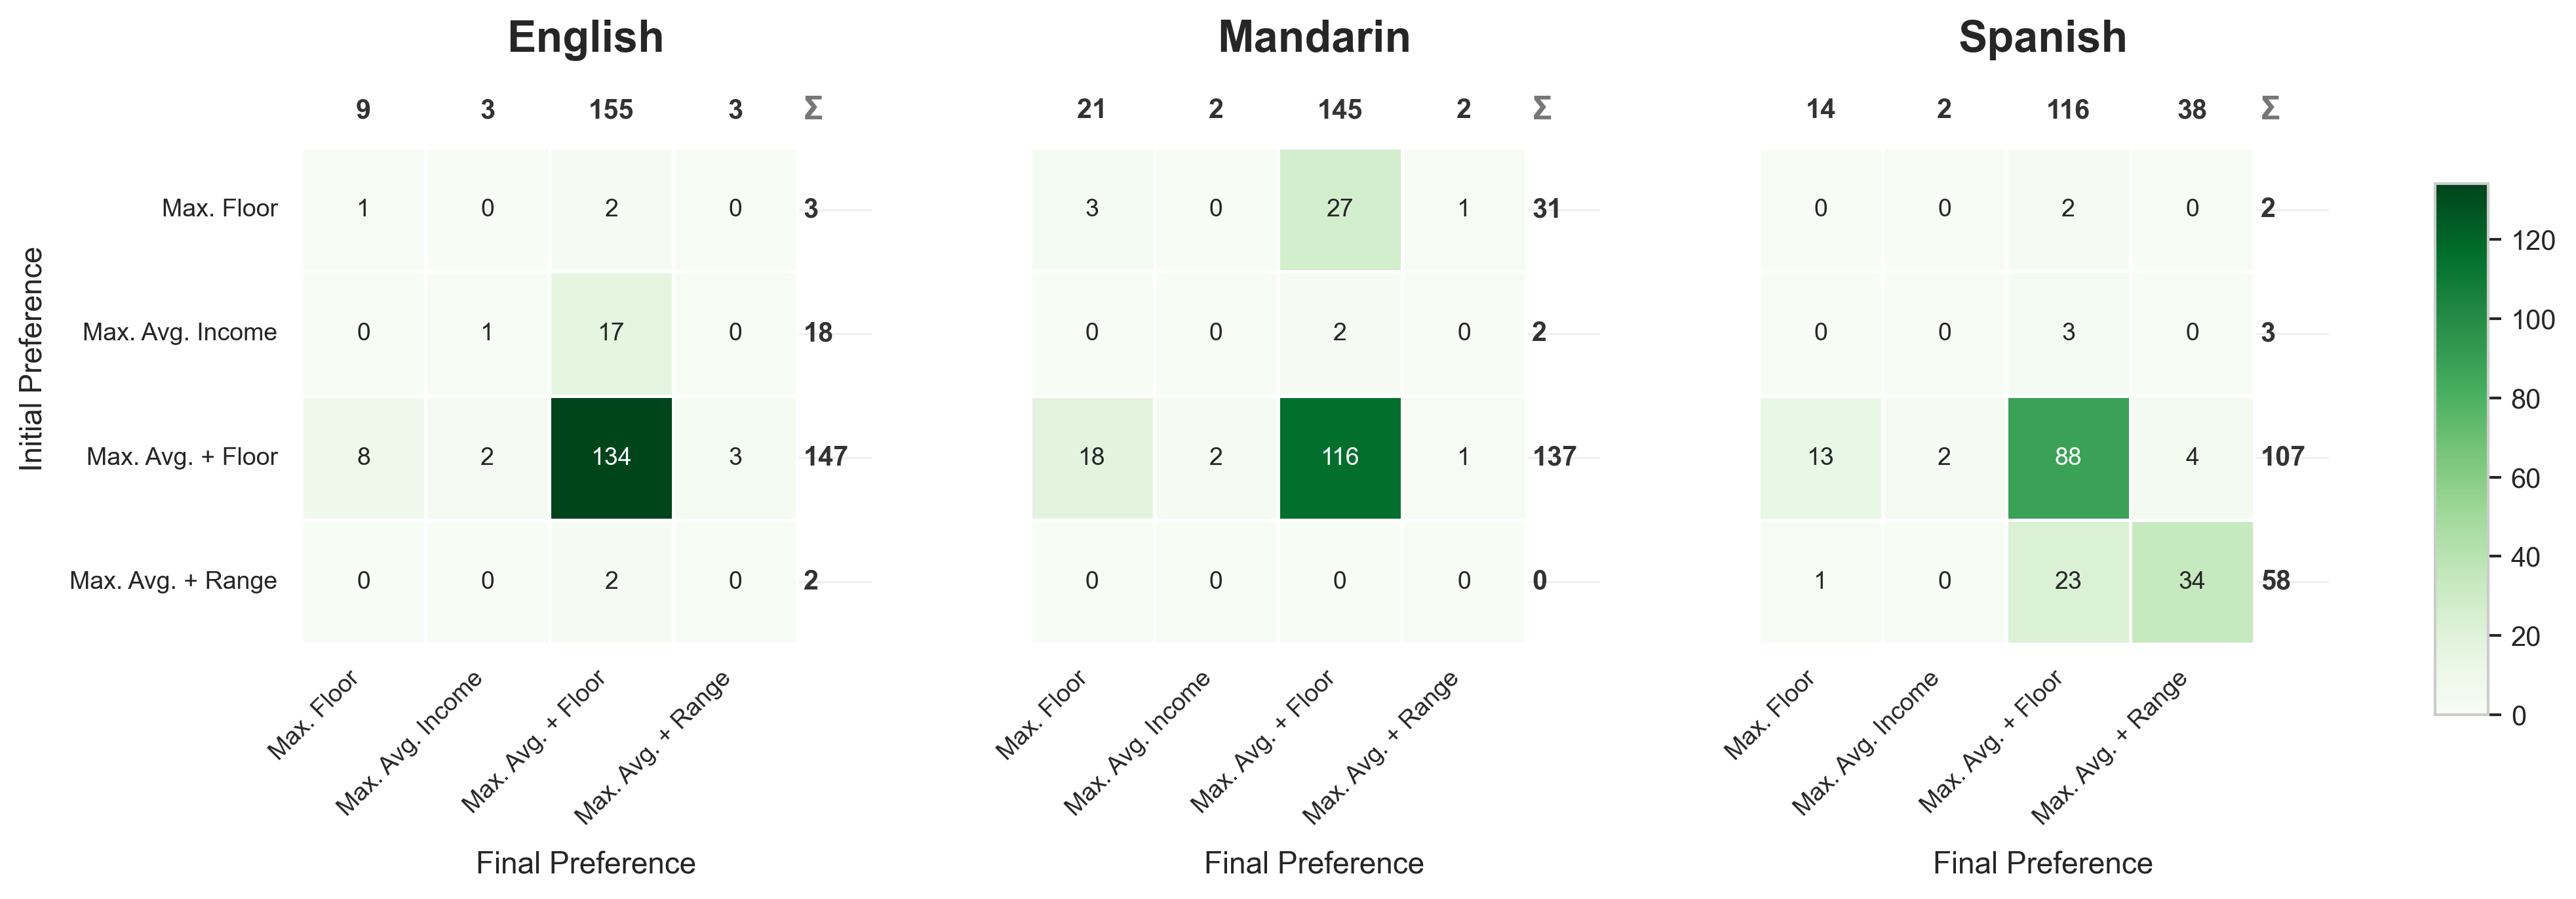

In [24]:
ordered_languages = ["English", "Mandarin", "Spanish"]
counts_only_data = [
    (label, group_datasets[label].transition_data if label in group_datasets else None)
    for label in ordered_languages
]

plot_long_term_counts_grid(
    counts_only_data,
    principle_display_order=PRINCIPLE_DISPLAY_ORDER,
    format_principle_label=format_principle_label,
    orientation="horizontal",
    axis_title_fontsize=16,

    colorbar_mode="shared",
)




### Large Font Version

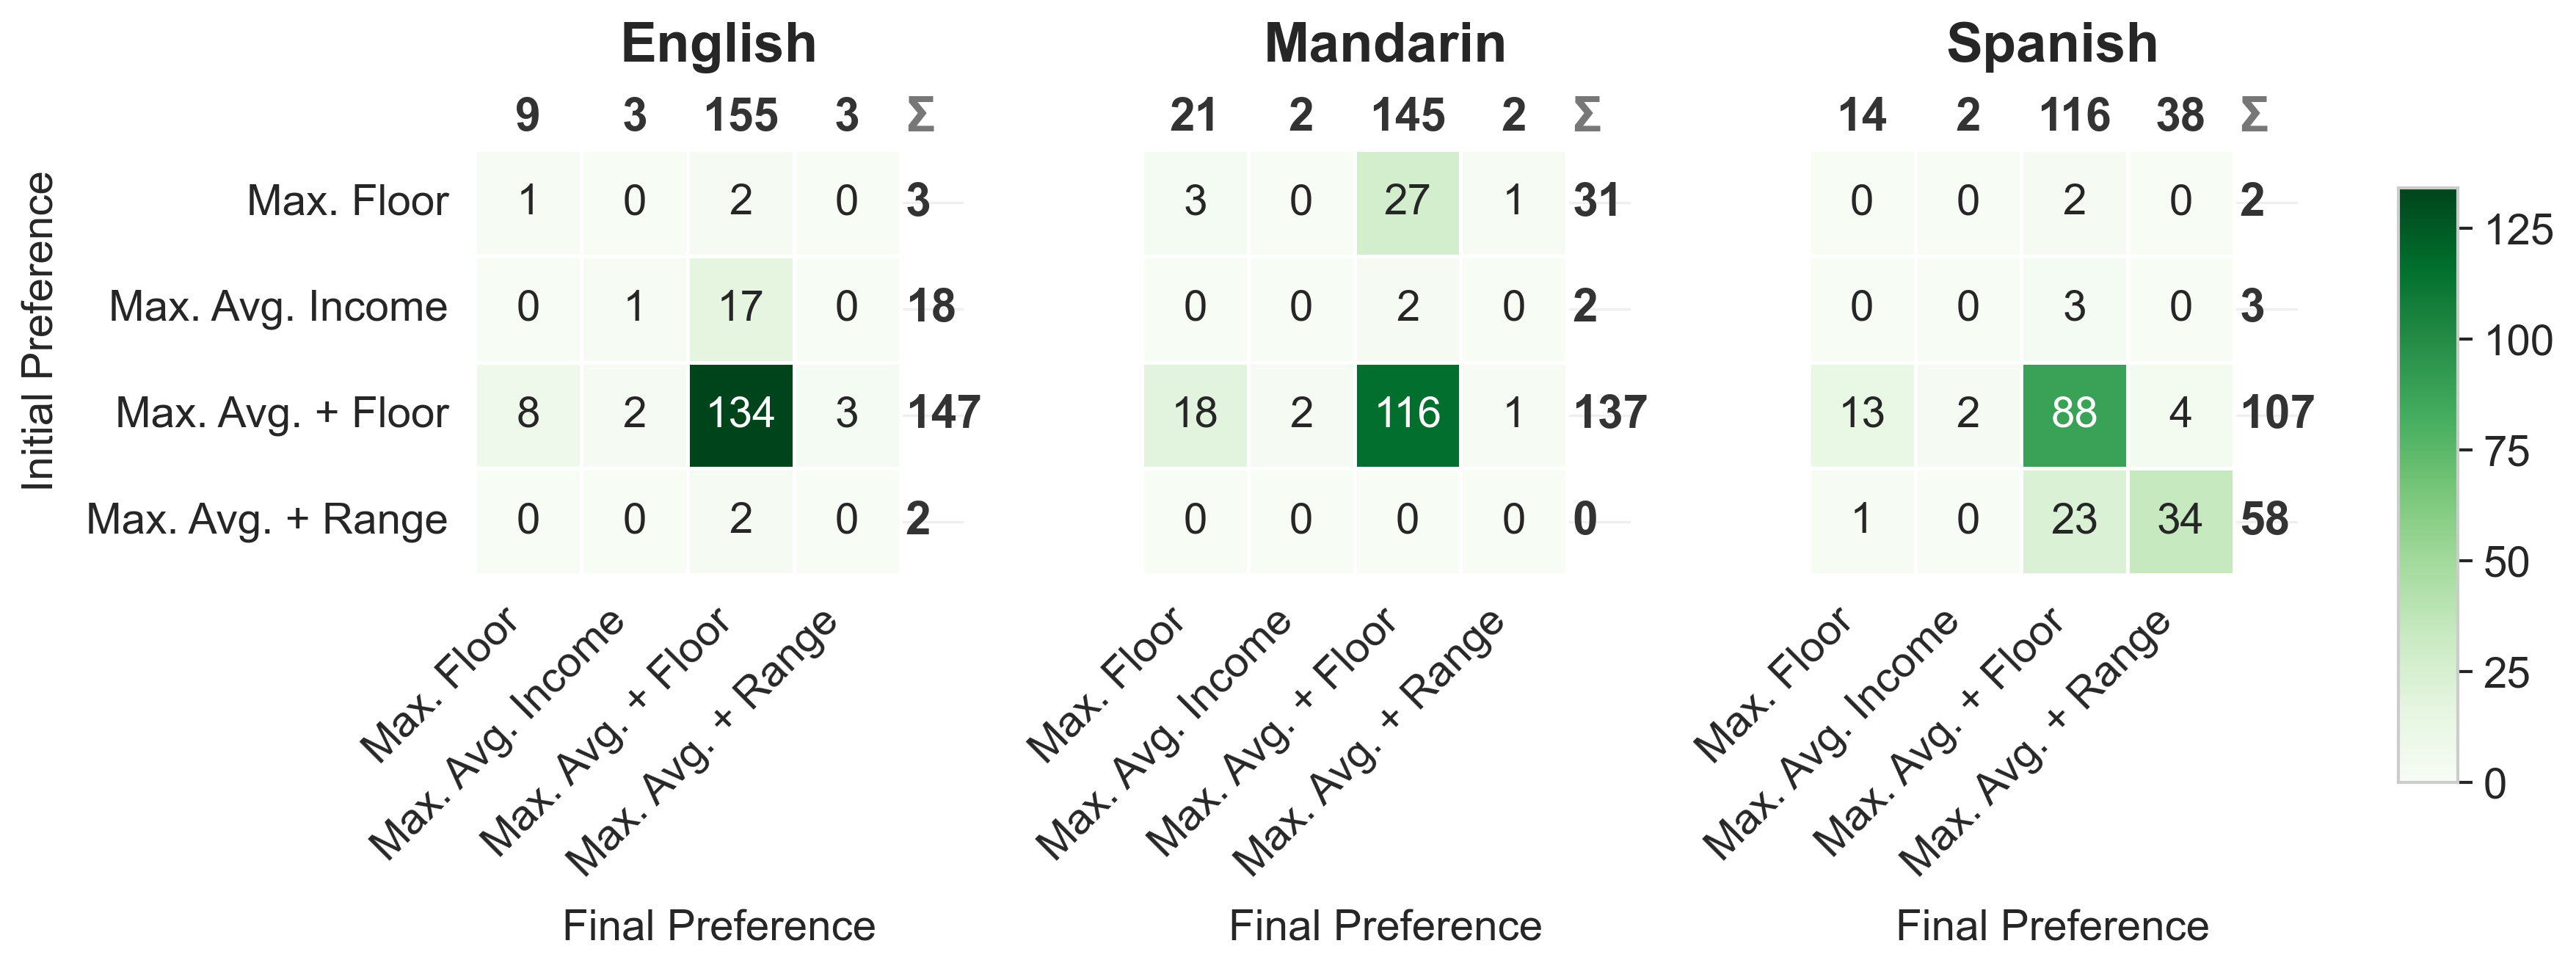

In [25]:
# Define larger font sizes for better readability
LARGE_FONT_SIZES = {
    "title": 20,
    "subtitle": 14,
    "axis_label": 14,
    "tick_label": 14,
    "legend": 14,
    "annotation": 14, # Heatmap numbers
}
display(Markdown("### Large Font Version"))
plot_long_term_counts_grid(
    counts_only_data,
    principle_display_order=PRINCIPLE_DISPLAY_ORDER,
    format_principle_label=format_principle_label,
    orientation="horizontal",
    axis_title_fontsize=18, # Explicit override for the cohort titles (English/Mandarin/Spanish)
    colorbar_mode="shared",
    font_sizes=LARGE_FONT_SIZES,
    wspace = -0.83,
    right_margin=0.8,
)

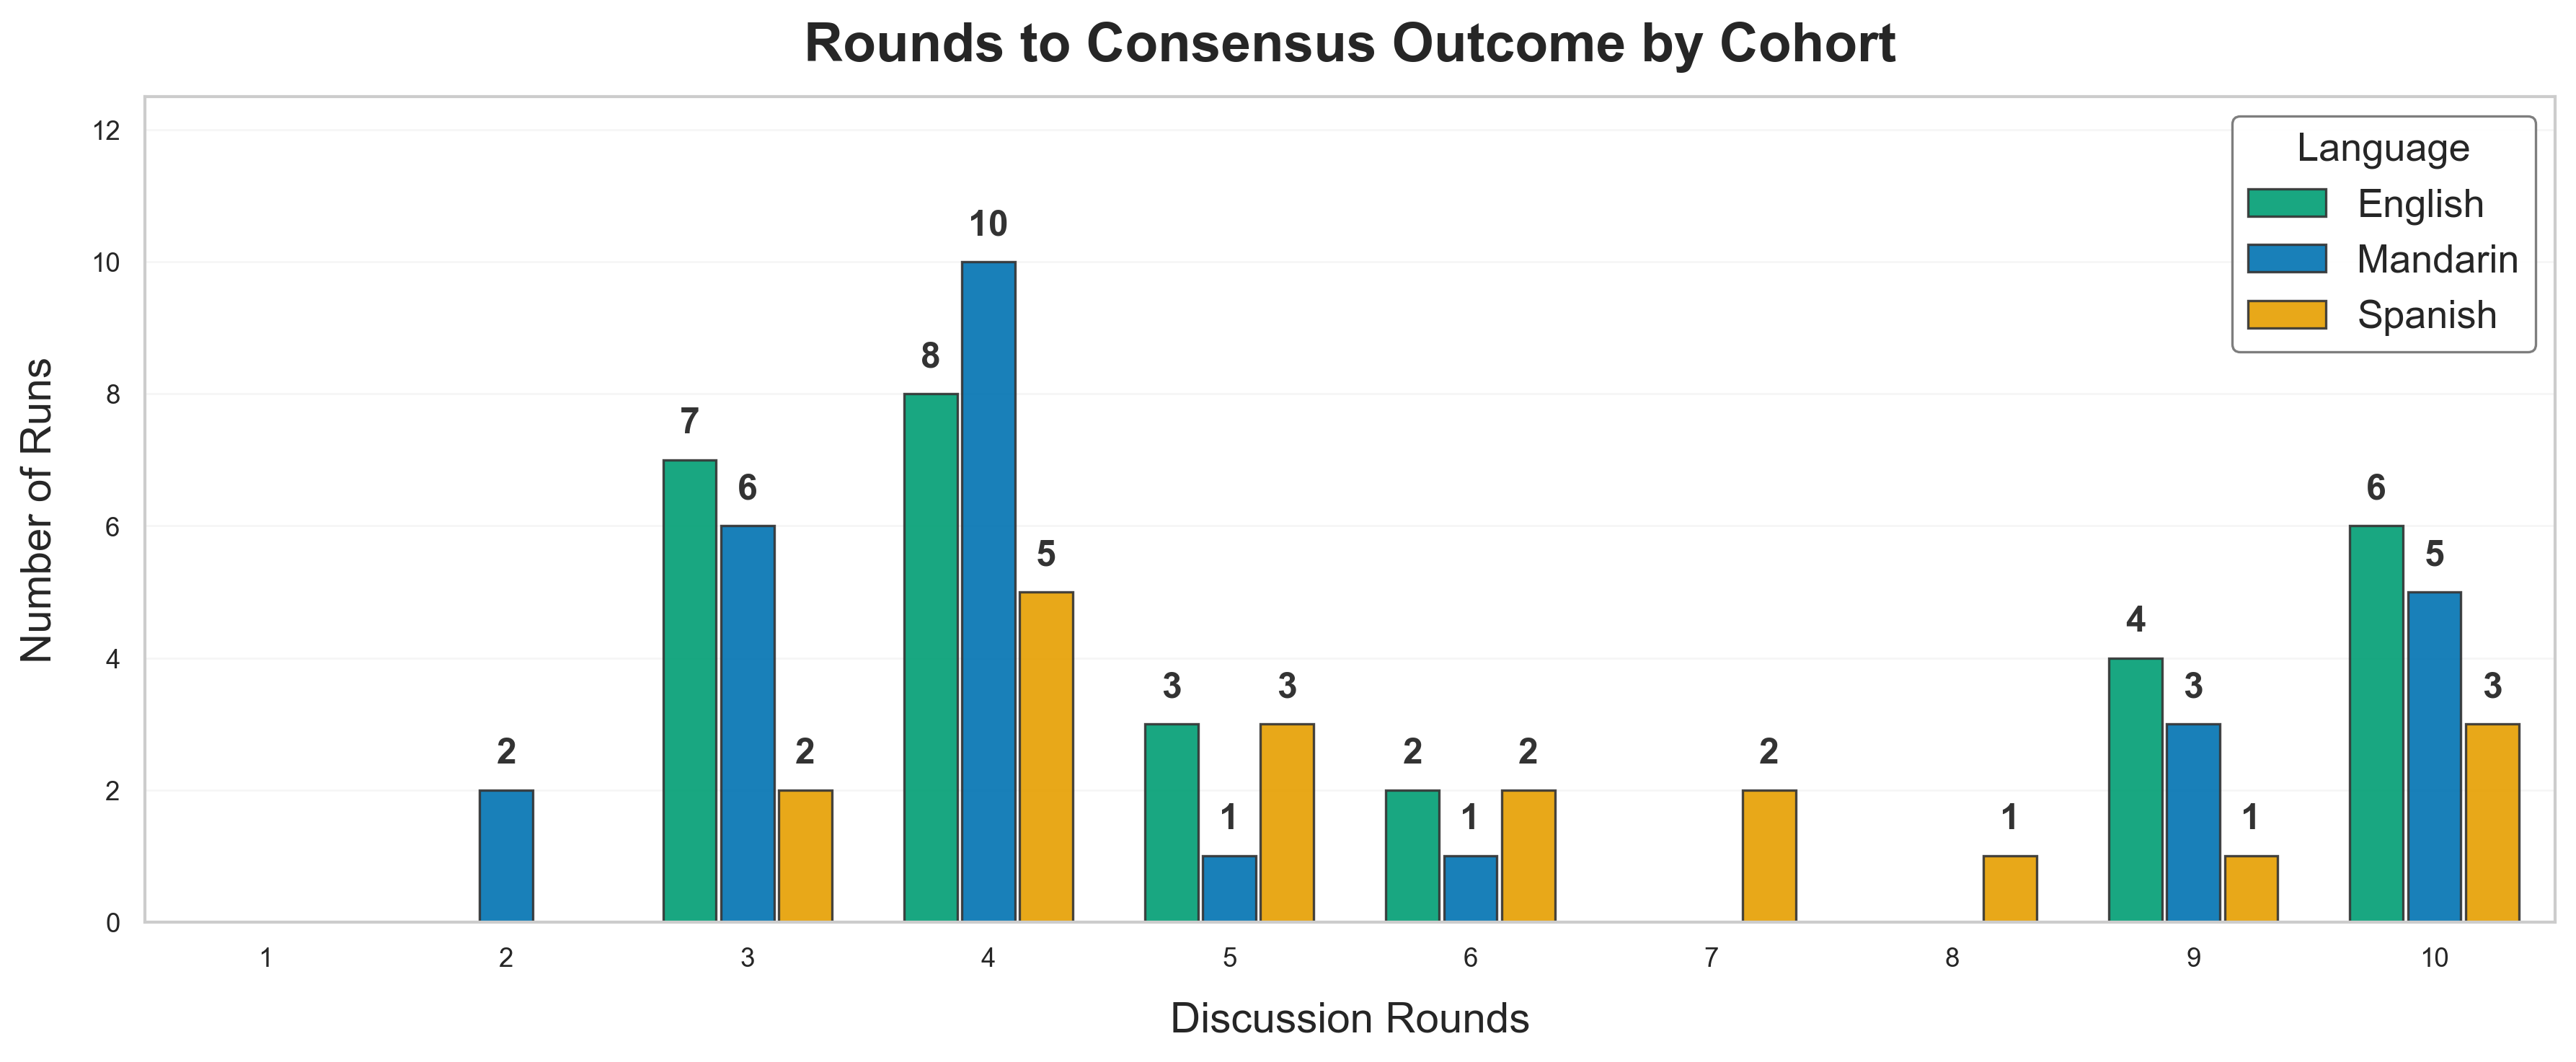

In [26]:
grouped_rounds_data = [
    (label, group_datasets[label].run_metrics if label in group_datasets else None)
    for label in ordered_languages
]

plot_rounds_to_outcome_grouped(
    grouped_rounds_data,
    language_order=ordered_languages,
    font_scale=1.3
)


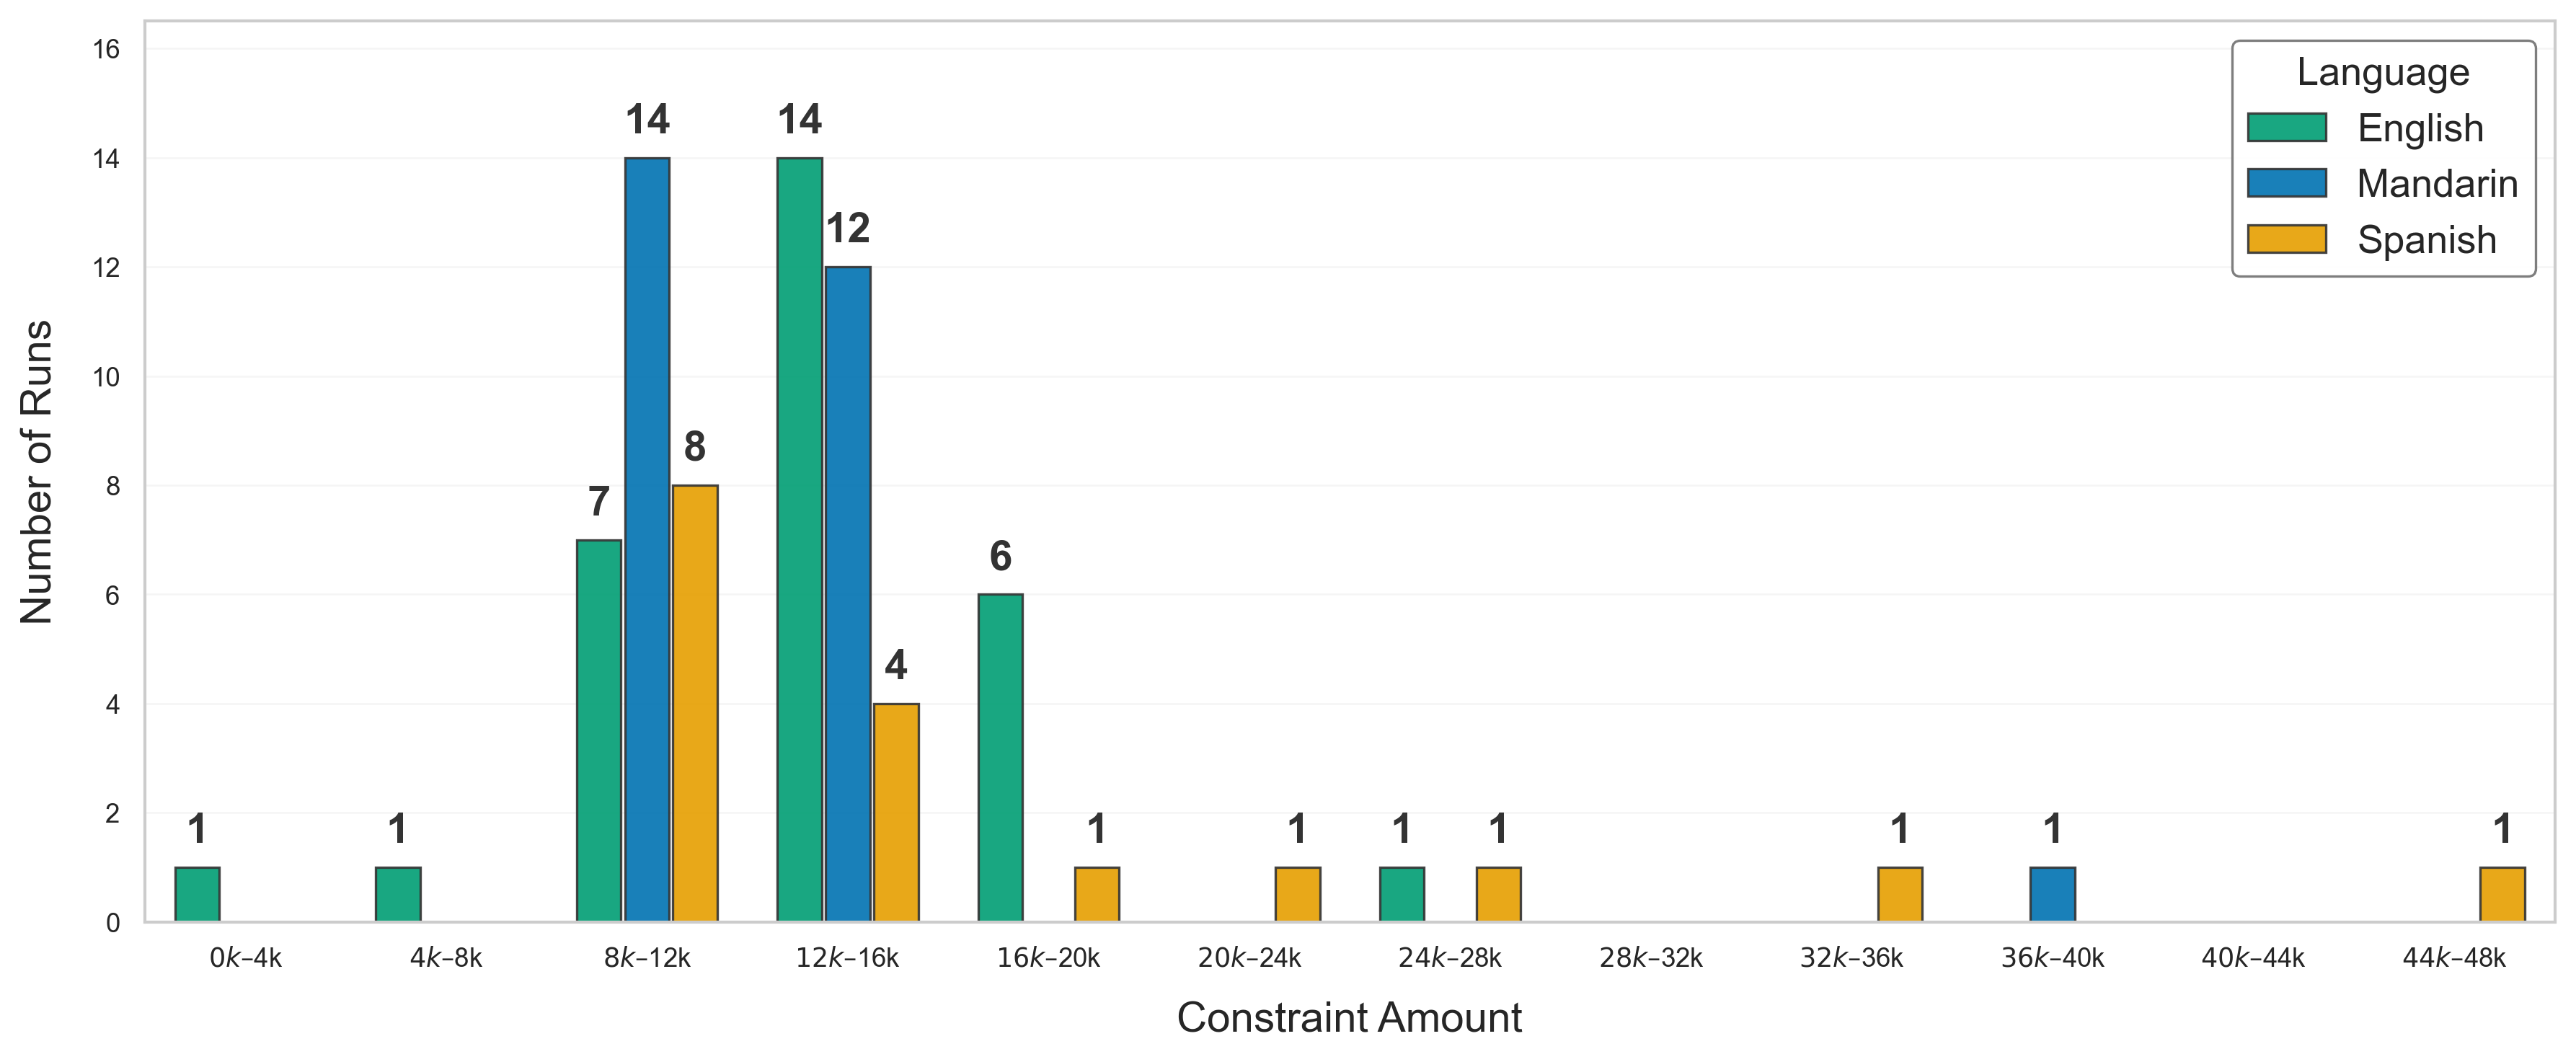

In [27]:
grouped_constraint_data = [
    (label, group_datasets[label].vote_rounds if label in group_datasets else None)
    for label in ordered_languages
]

plot_floor_constraint_distribution_grouped(
    grouped_constraint_data,
    language_order=ordered_languages,
    target_principle_label="Max Avg + Floor",
    font_scale=1.3,
    bin_width=4000,
    show_title=False,
    annotation_fontsize=14,
)


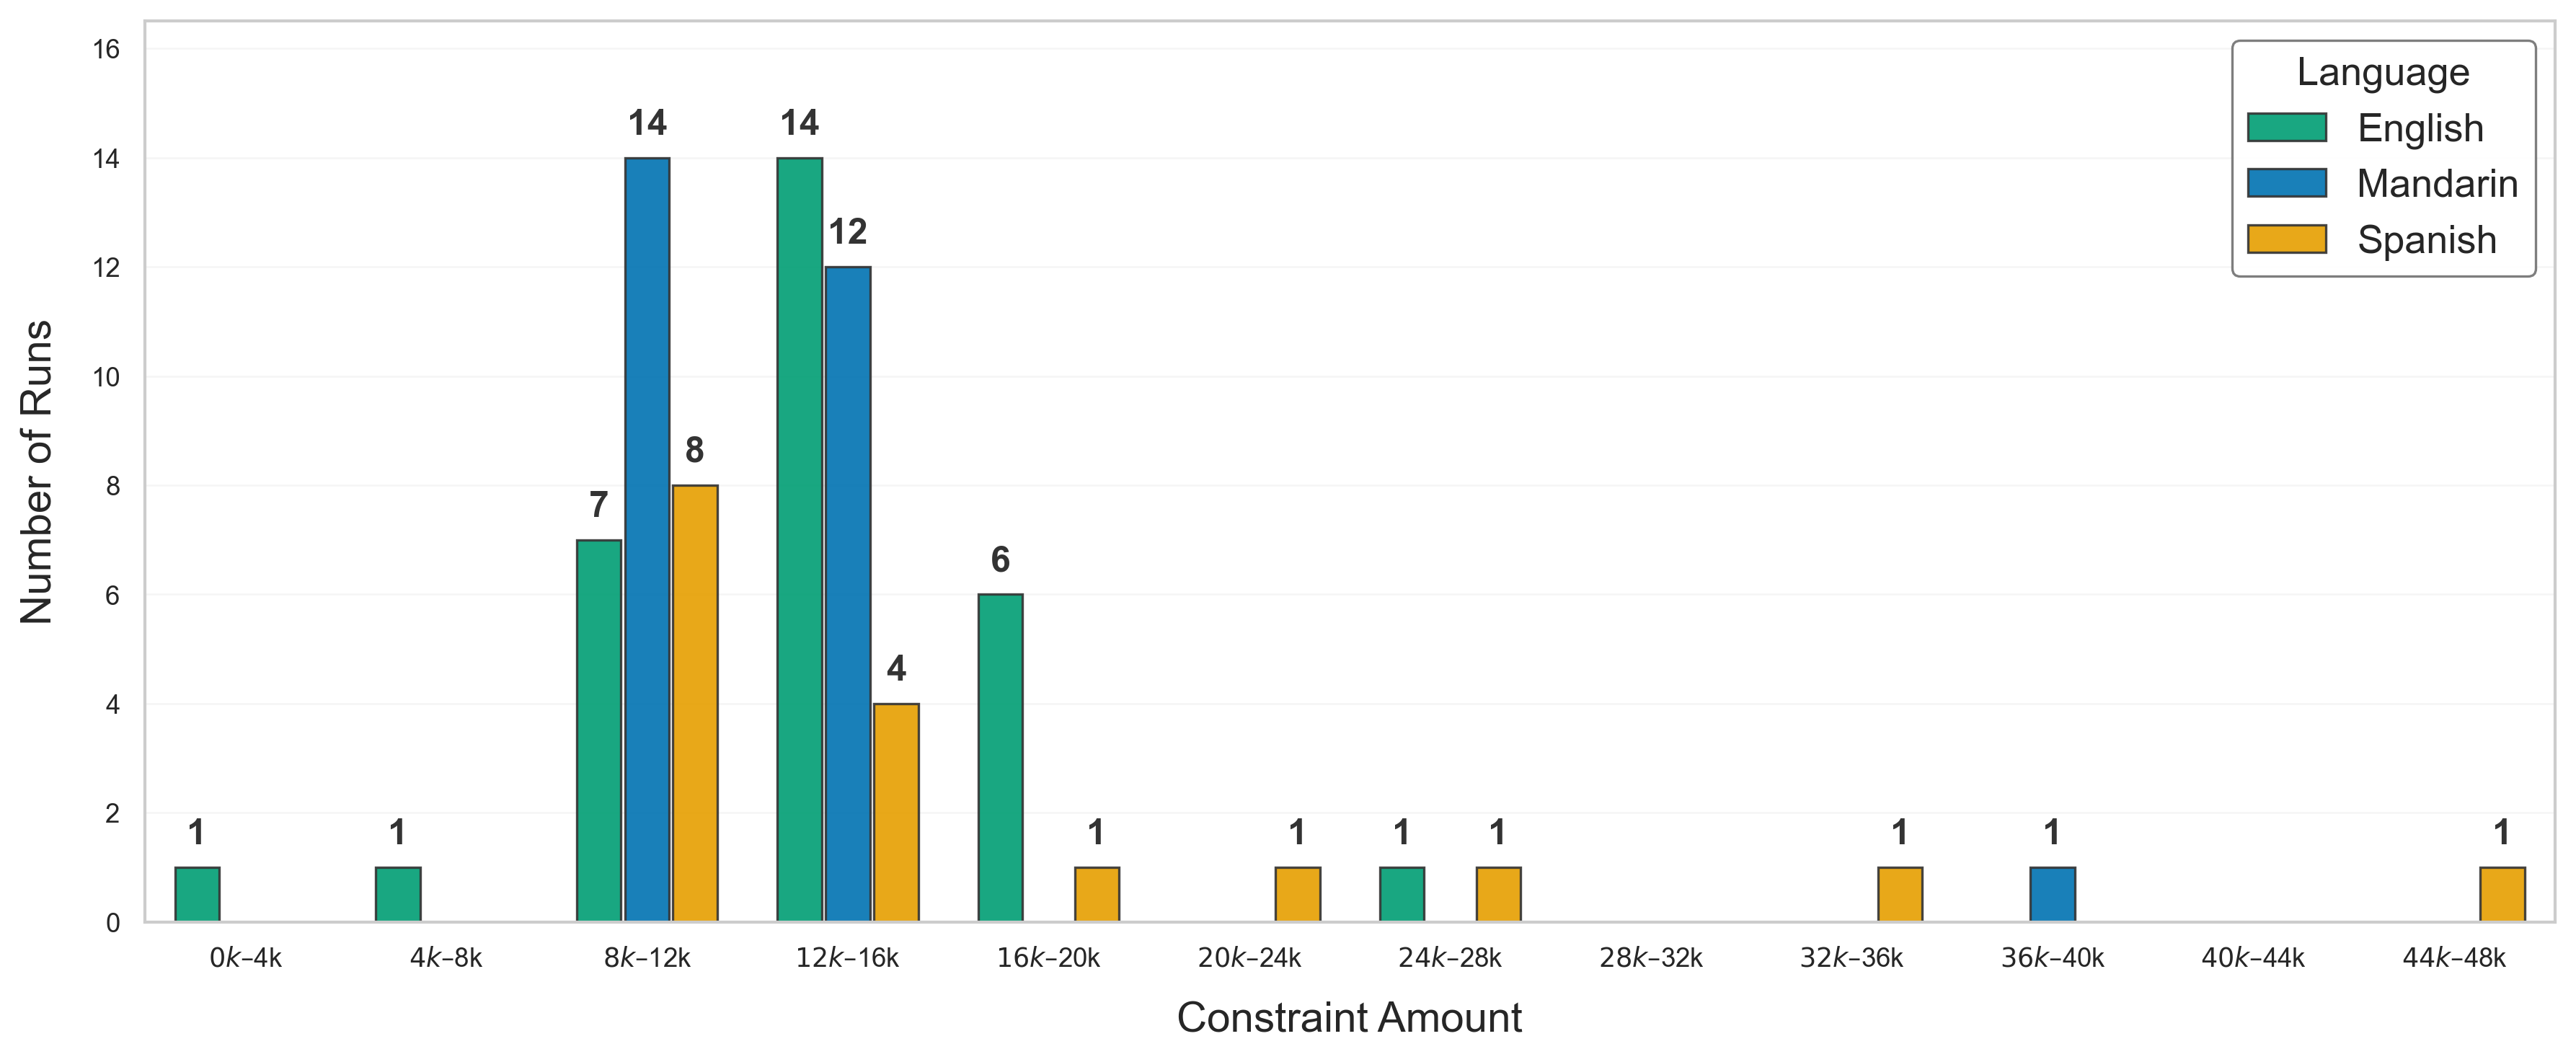

In [28]:
grouped_constraint_data = [
    (label, group_datasets[label].vote_rounds if label in group_datasets else None)
    for label in ordered_languages
]

plot_floor_constraint_distribution_grouped(
    grouped_constraint_data,
    language_order=ordered_languages,
    target_principle_label="Max Avg + Floor",
    font_scale=1.3,
    bin_width=4000,
    show_title=False,
)